# LiDAR 直方图仿真 v32 —— 二值采样 + 来源归因(公平) + 背景护带 + 不同反射率对比

> **本版由 v30 派生（仅在 v30 上做增改，物理场景参数一律不变）。** v30 的二值采样机制
> （8ns 过阈窗 + 1ns 时钟 0/1、宏像元 27×N_shots 饱和上限、`delta_dly` 亚 ns 测距）全部保留。
>
> **HDC（Hardware Data Channel，硬件数据通道）**：执行"1ns 时钟采样 → 比 60% 阈值 → 出 0/1"
> 的硬件采样单元。下文"1ns 采样"即 HDC 采样。
>
> | | v30（旧） | **v31（本版）** |
> |---|---|---|
> | 二值引擎 | 合并生成光子、出单一 0/1 | 加 `return_attrib`：可**分离**信号/环境光子、归因每个"1"的来源 |
> | 背景前沿 | tf 从 t_lo 起 → 前 ~8ns bin 缺上游雪崩（"最开始没噪声"假象） | **左扩护带** guard band ≥8ns 生成光子再裁掉 → 背景均匀 |
> | 模块 12图B/13 | 单色（信号+背景混一起） | **双色归因**：信号触发 vs 环境触发 分开画 |
> | 新增 模块 9c | — | 单 SPAD 二值时域**折线波形**：Vov(t)→1ns HDC 采样→比 60% 阈值→输出 0/1 方波 |
> | 新增 模块 11b | — | **每个 shot** 的直方图（折线），看 shot 间涨落与 N_shots 累加 |
>
> **v32 相对 v31 的两处改动（只改这两点，物理参数一律不变）：**
> 1. **归因改为按比例公平**：`spad_binary_trace` 的信号/环境归因不再“信号优先”，
>    改为“先数该时刻有多少信号光子、多少环境光子，再按比例 n_sig:n_amb 等概率抽签”
>    决定每次雪崩/每个 bin 归信号还是环境。总计数分布不变、SNR/检测结论不变，只是绿(信号)/
>    橙(环境)分配更公平；因抽签会重排随机序列，某一次实现的具体数值与 v31 会有同分布的差异。
> 2. **新增模块 17**：画 ρ∈{0.01,0.1,0.3,0.5,0.75,1.0} 的信号波形对比；其余模块仍按 ρ=0.1。
>
> ---
>
> ### 先回答上一轮的两个"为什么"（v31 的两个改进正是针对它们）
>
> **① 模块 12 图 B：信号看着很强，为什么不饱和？**
> ```
>   峰 bin 高度 73/108  ← 这是 27 SPAD × 4 shot = 108 个「SPAD×shot 实例」里 73 个记了 1
>   ┌───────────────────────────────────────────────┐
>   │ 饱和 ≠ 峰高。饱和只由【单 SPAD 单 shot 触发概率】决定：           │
>   │   P(该 SPAD 该 shot 记 1) = 1 − e^(−λ),  λ=单 SPAD 单 shot 期望雪崩数 │
>   │   λ≈1 → P≈0.63（未贴顶）;  要饱和需 λ≫1 → P→1                    │
>   └───────────────────────────────────────────────┘
>   长条像斑 σ_y≈200µm≈20 像元 → 信号被摊薄到每个 SPAD f≈0.002，单 SPAD λ 很小 → 不饱和。
>   加 N_shots 也没用：分子分母(macro_cap=27·N_shots)同步放大，占比不变。
> ```
> **② 模块 13：信噪比图里为什么环境噪声不均匀、"最开始没噪声"？**
> ```
>   根因是【边界假象】，不是物理：
>     生成窗 tf 只覆盖 [t_lo, t_hi]，而每次雪崩要向右铺 8ns 过阈窗。
>     分析窗前沿 bin 本应收到来自窗左侧(<t_lo)上游雪崩的"尾巴"，但那些光子根本没生成
>     ⇒ 前 ~8ns bin 系统性偏低 → 看起来"最开始没噪声"。
>   v31 修复：把【生成光子】的网格向左扩 guard_band(≥8ns)，采样点(centers)不动 →
>            前沿 bin 补齐上游贡献 → 背景恢复均匀。
> ```
> 环境噪声确实是"逐光子进入 SPAD 二值"的（每个环境光子和信号光子一样按 PDE·g(Vov) 判触发、
> 铺 8ns 窗）；v31 的来源归因就是把"这个 1 是信号光子还是环境光子点亮的"逐 bin 标出来。
>
> ---
> ⚠️ **物理场景参数（目标 30m/反射率 0.10、脉冲、bin 宽 1ns、N_shots=4、τ_RC、Vth_frac=0.60 等）
> 与 v30/v21 完全一致，v31 只增功能、不改任何既有参数值。**

---

# （以下为 v30 原标题，原样保留）

# LiDAR 直方图仿真 v30 —— 二值采样模型（8ns 过阈窗 + 1ns 时钟 0/1）

> **本版由 v21 派生。** 与 v21 最大的差异在"SPAD 统计方式"：
>
> | | v21（旧） | **v30（本版）** |
> |---|---|---|
> | 记录量 | 每个光子的 **timestamp** | **不记 timestamp**；1ns 时钟采 **0/1** |
> | 单光子响应 | 一个事件（δ） | **8ns 宽、高度=1** 的过阈值窗 |
> | 直方图 | timestamp 落 bin 计数 | 采样点是否过阈（每 SPAD 每 bin 每 shot ∈ {0,1}） |
> | 峰 bin 上限 | 无硬上限 | **27 × N_shots**（饱和） |
> | 展宽/饱和 | — | 由 8ns 窗（展宽）与二值封顶+窗堆积（饱和）统一解释 |
> | 亚 ns 测距 | — | `delta_dly` 游标（1/12 ns）扫描（模块 12b） |
>
> **保留复用 v21：** 模块 0–9 的物理链路（激光脉冲、发射/接收光学、信道、朗伯目标、
> 椭圆高斯像斑、光链路、环境光、RC 恢复机制）原样不变；其中模块 8b 的 Vov(t) RC
> 恢复曲线正是 **8ns 过阈窗宽 `T_OVER = −τ_RC·ln(1−Vth_frac) ≈ 8ns`** 的物理来源。
>
> **v30 核心新增/改写：** 模块 9b（二值引擎 + 波形演示）、模块 11/12/13/15（改用二值
> 采样产 `macro_hist`/`bg_hist_peak`，图12 删去 timestamp eventplot、加饱和上限线）、
> 模块 12b（`delta_dly` 亚 ns 测距）。下游模块 14/16 依赖契约变量无缝复用。
>
> ⚠️ 物理场景参数（目标距离/反射率/脉冲/bin 宽/N_shots 等）与 v21 **完全一致**，
> 仅新增 `PARAMS["timing"]` 三参数（默认全 0，即 `t_laser=0`，回波峰位与 v21 一致）。

# 激光雷达直方图仿真 v21 (LiDAR Histogram Simulation) — 检测阈值/前沿定时 + SNR 分布 + 100ppm 噪点率

链路(激光→TX→信道→目标→RX)与 **v4 完全一致**; 逐光子蒙特卡洛(Monte Carlo, 蒙卡)、
宏像元(Macro Pixel)统计沿用 **v10/v11/v12**(模块 0–7 原样复用, 含 v12 的硬死时间引擎作对照)。

**v13 相对 v12 的变化 —— 用 RC 恢复模型取代硬死时间**
- v12 用**硬死时间(hard dead time)**: 雪崩后固定 14ns 内完全不响应, 之后瞬间满灵敏。
  这抹掉了 SPAD 恢复期的**部分灵敏**——真实器件恢复期仍能以较低概率触发较弱雪崩。
- v13 新增 **RC 恢复模型**(模块 7b, 更接近物理): 雪崩后过电压
  **Vov(OverVoltage, 过电压 = V_bias − V_br)** 通过淬灭电阻 R 与结电容 C_J 按 **RC 指数**恢复:
  $$V_{ov}(\Delta t)=V_{ov,max}\,(1-e^{-\Delta t/\tau}),\qquad \tau=R\,C_J$$
  - 恢复期来光子的触发概率 **PDE(Δt)=PDE_max · Vov(Δt)/Vov_max**(线性 PDE∝Vov);
  - 触发后**只有脉冲幅度(∝当前 Vov)≥ 阈值 Vth 才被读出电路计一次数**;
  - **仅计数事件复位**: 只有够阈值的计数事件才重置 Vov、重新开始 RC 恢复(亚阈弱雪崩不复位)。
- **参数**(本版设定): τ_RC = **6 ns**, Vth = **10% · Vov_max**, Vov_max = 3.3 V, reset = **仅计数事件**。
- 模块 8/9/11/12 全部改用 RC 引擎, 并**与 v12 硬死时间(14ns)对比**, 展示两模型差异。

**为什么 RC 更可靠(尤其本场景)**
- 本场景中心 SPAD 单 shot 入射约 64 光子、脉宽约 6ns(远短于恢复时间), 光子极密集。
- 硬死时间把恢复期一刀切死 ⇒ 严重低估计数(峰值区仅剩~6%); RC 允许恢复途中被较弱触发 ⇒ 更真实(~18%)。

> ⚠️ 运行方式: **Kernel → Restart & Run All**(从上到下顺序执行)。
> 宏像元方向锁定: **3 沿长边 y, 9 沿短边 x**(9×3, 沿长边 40 个, 每个 27 SPAD)。

**v14 相对 v13 的变化**
- 新增**模块 6b**: SPAD 阵列俯视图(网格 + 光斑 1/e²/1σ 椭圆轮廓 + 每个 SPAD 按 f_pix 涂色)。
- 新增**模块 8b**: RC 模型下单个 SPAD 某次蒙卡采样的**过电压 Vov(t) 曲线**, 标出计数阈值 Vth。
- **参数化**: 硬死时间、τ_RC、Vov_max、Vth、reset 全部移入 `PARAMS["spad"]`, 模块 7b/8 从字典读取。

**v20 相对 v15 的变化**
- **任务1(阈值/死区)**: 计数阈值 `Vth_frac` 0.10 → **0.60**; τ_RC 由 6ns 调到 **8.73ns**,
  使"可再次探测的最小间隔"(计数死区 = −τ·ln(1−Vth_frac)) = **8ns**。
- **任务2(响应函数)**: SPAD 单光子触发概率由 `PDE_max·vov_frac` 改为 **`PDE_max·g(vov_frac)`**;
  `g` 可选 **linear**(=旧版) 或 **exp**(凹形快起饱和), 满足 g(0)=0(Vov=0 完全不响应)、g(1)=1(满 Vov→PDE_max)。
  新增**模块 7c** 画 g(Vov) 响应曲线; 本版全局用 `shape='exp'`(k=3)。
- **任务3(信噪比)**: 新增**模块 13** 计算 **SNR = S/√B**(信号峰 bin; S=扣背景信号计数, B=纯环境光蒙卡背景计数)。
- 其余 30m 场景/脉冲/反射率/bin 宽等物理参数**一律未改**。

**v21 相对 v20 的变化(均基于 N_shots=4 累加直方图, 峰值宏像元)**
- **模块 14(检测阈值 + 前沿法定时)**: `det_th = k_th·nc_base`(nc_base=纯背景全 bin 均值);
  前沿法判决电平 `V_dec=(det_th+峰值)/2`, 在峰前沿相邻两 bin **线性插值**得 **front_time**, 换算距离与真值比较。
- **模块 15(SNR 分布)**: 重复 N_TRIALS 次峰值宏像元 RC 蒙卡, 每次算 SNR=S/√B̄
  (**分母 B̄=纯背景全 bin 均值**, 避免峰 bin 单背景因 RC 死区大量为 0), 直方图 + **正态拟合**;
  理论(B̄ 近似常数, S~Poisson): μ=S̄/√B̄, σ=√S̄/√B̄, 与拟合高度吻合。
- **模块 16(100ppm 噪点率)**: 按"整个时间窗/每次测量"定义窗口级虚警率=100ppm=1e-4;
  由 Poisson(nc_base) **精确反解整数阈值 T**(附高斯近似对比); 再用**海量向量化 Poisson 蒙卡**(默认 2e7, 可到 1e8)
  统计实测噪点率, 与理论一致性验证。
- 其余 30m 场景/脉冲/反射率/阈值/死区/响应函数等物理参数**一律未改**。

## 模块 0 — 参数与常数

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

for _f in ["Microsoft YaHei", "SimHei", "Noto Sans CJK SC", "Source Han Sans SC"]:
    try:
        matplotlib.rcParams["font.sans-serif"] = [_f]; break
    except Exception:
        continue
matplotlib.rcParams["axes.unicode_minus"] = False

C_LIGHT = 2.99792458e8      # 光速 [m/s]
H_PLANCK = 6.62607015e-34   # 普朗克常数 [J·s]
D_PLOT_MAX = 300.0          # D 相关 plot 的统一距离范围 [m]

PARAMS = {
    # ---------- 激光源 ----------
    "laser": {
        "wavelength": 905e-9,   # 波长 [m]
        "amp_mode": "peak",     # "peak"=用 P_peak 定幅 / "energy"=用 E_pulse 定幅
        "P_peak": 235.0,        # 峰值光功率 [W]
        "E_pulse": 800e-9,      # 目标单脉冲能量 [J] (amp_mode="energy" 时生效)
        "tau_r": 0.7e-9,        # 双指数上升时间常数 [s]
        "tau_f": 1.9e-9,        # 双指数下降时间常数 [s]
        "x_L": 60e-6,           # 发光面 X 尺寸(慢轴, 1/e^2 全宽) [m]
        "y_L": 1150e-6,         # 发光面 Y 尺寸(快轴, 1/e^2 全宽) [m]
    },

    # ---------- TX 发射光学 ----------
    "tx": {
        "f_TX": 36e-3,          # 发射物镜焦距 [m]
        "D_TX": 12.7e-3,        # 发射通光口径 [m] -> w0 = D_TX/2
        "eta_coupling": 0.87,   # 发射角度耦合效率
        "T_TX": 0.92,           # 发射透过率
    },

    # ---------- 信道 / 大气 ----------
    "channel": {
        "alpha": 0.1e-3,        # 消光系数 @905nm [1/m]  (0.1/km≈晴朗)
        # 0.3e-3 小雨 / 0.6e-3 大雨 / 20e-3 大雾 / 60e-3 浓雾
    },

    # ---------- 目标 (多回波) ----------
    "target": {
        "echoes": [
            {"D": 30.0,  "rho": 0.10, "frac": 1.00, "tilt_deg": 0.0,  "name": "近处物体(边缘拦截)"},
            {"D": 120.0, "rho": 0.10, "frac": 0.00, "tilt_deg": 30.0, "name": "主目标(倾斜墙面)"},
            {"D": 200.0, "rho": 0.10, "frac": 0.00, "tilt_deg": 0.0,  "name": "远处背景"},
        ],
    },

    # ---------- RX 接收光学 ----------
    "rx": {
        "f_RX": 25e-3,          # 接收物镜焦距 [m]
        "D_RX": 13e-3,          # 接收口径 [m]
        "eta_RX": 0.82,         # 接收耦合效率
        "T_RX": 0.90,           # 接收透过率
        "T_filter": 0.90,       # 窄带滤光片透过率
        "filter_bw": 12e-9,     # 滤光片带宽 [m] (12 nm bandpass)
    },

    # ---------- SPAD 器件 ----------
    "spad": {
        "PDE": 0.30,            # 光子探测效率(=PDE_max, 满过电压时的峰值 PDE)
        "DCR": 0.0e3,           # 单像元暗计数率 [cps]
        "jitter_sigma": 100e-12,# IRF 高斯 sigma [s]
        # --- 死时间 / 恢复模型参数(v14: 从此处统一配置) ---
        "t_dead": 14e-9,        # 硬死时间 [s] (hard dead time 对照模型, non-paralyzable)
        # v20: Vth_frac 0.10->0.60, 并令 τ_RC 使"可再次探测的最小间隔"(死区)=8ns。
        #   死区 t_deadzone = -τ_RC·ln(1-Vth_frac); 令=8ns 且 Vth_frac=0.60 ->
        #   τ_RC = 8e-9 / (-ln(1-0.60)) = 8e-9 / 0.916291 = 8.7315 ns。
        "tau_rc": 8.7315e-9,    # RC 恢复时间常数 τ=R·C_J [s] (v20: 使死区=8ns, 见上)
        "Vov_max": 3.3,         # 满过电压 Vov_max [V] (=V_bias − V_br)
        "Vth_frac": 0.60,       # 计数所需最小过电压占比 (v20: 0.10->0.60; Vth=Vth_frac·Vov_max)
        "reset_mode": "count",  # RC 复位方式: "count"=仅计数事件复位 / "all"=任何雪崩都复位
        # --- v20 新增: SPAD 对光子的响应函数 g(vov_frac), 触发概率=PDE_max·g(vov_frac) ---
        #   约束: g(0)=0 (Vov=0 完全不响应), g(1)=1 (满 Vov 触发概率=PDE_max)。
        "resp_shape": "exp",    # "linear": g(x)=x (与 v15 一致) / "exp": 凹形快起饱和
        "resp_k": 3.0,          # exp 曲率(仅 resp_shape="exp" 生效): g(x)=(1-e^(-k·x))/(1-e^(-k)), k>0 凹
    },

    # ---------- 方形 SPAD 阵列 ----------
    "spad_array": {
        "pitch": 10e-6,         # 方形像元间距 [m]
        "Nx": 9, "Ny": 120,  # 阵列规模
        "fill_factor": 1.00,    # 填充因子(=1 表示不计死区/假设微透镜完全补偿)
        "sum_pixels": "illuminated",  # "illuminated"仅被照像元 / "all"整阵列
    },

    # ---------- Macro Pixel 宏像元 Binning (v3 新增) ----------
    # 把 Bx×By 个物理像元合并成一个宏像元, 对应视场 iFOV_macro = B·pitch/f_RX.
    # 只有落在宏像元窗口内的回波像斑光被接收(超出部分丢失).
    # 坐标约定(全局一致): x=短边(发光区60µm→像斑~7µm), y=长边(发光区1150µm→像斑~122µm).
    # 本例: 6/9/12 沿 x(短边), 3 沿 y(长边).
    #   → x窗口60/90/120µm 远超像斑7µm ⇒ x方向都≈全收; y窗口固定30µm 罩不住122µm长条.
    #   ⇒ 三种收集比例几乎相同(~0.48), 差异只在背景像元数(18/27/36). 这是真实配置的物理结果.
    "macro": {
        "sizes_xy": [(6, 3), (9, 3), (12, 3)],   # (Bx 沿短边x, By 沿长边y) 的宏像元尺寸列表
    },

    # ---------- 环境光 (直接给辐照值, 不做 lux 光谱假设) ----------
    "ambient": {
        "enable": True,         # 是否计入环境光
        # 905nm 处光谱辐照度 [W/m²/nm]. 100klux 白天太阳 AM1.5 附近典型 ~0.5-0.7; 按你的实测改.
        "E_lambda": 0.68,
        "surface_rho": 0.10,    # 被观测目标面反射率(用于环境光漫反射, 可与 echo 不同)
    },

    # ---------- 直方图 / TCSPC ----------
    "hist": {
        "t_max": 2048e-9,       # 时间窗 [s] (~307 m)
        "bin_width": 1e-9,      # bin 宽 [s]
        "dt_fine": 10e-12,      # 卷积精细网格 [s]
        "N_shots": 4,          # 累加脉冲数
        "seed": 0,
    },
}

E_PHOTON = H_PLANCK * C_LIGHT / PARAMS["laser"]["wavelength"]
print(f"单光子能量 E_photon = {E_PHOTON:.3e} J  ({E_PHOTON/1.602e-19:.3f} eV)")
print(f"1 ns bin -> 距离分辨 {C_LIGHT*1e-9/2*100:.1f} cm;  时间窗 {PARAMS['hist']['t_max']*1e9:.0f} ns -> "
      f"最远 {PARAMS['hist']['t_max']*C_LIGHT/2:.0f} m")

单光子能量 E_photon = 2.195e-19 J  (1.370 eV)
1 ns bin -> 距离分辨 15.0 cm;  时间窗 2048 ns -> 最远 307 m


## 模块 1 — 激光源

空间：椭圆高斯 `S(x,y)=exp(-2x²/w_x²-2y²/w_y²)`。此激光条 Y 为快轴(1150µm)更长。
时间：双指数 `p(t)=exp(-t/τ_f)-exp(-t/τ_r)`。

**脉宽定义**：主指标为 **上升沿10% → 下降沿10% 的全宽**（记作 W_10-10）。
幅度基准 `amp_mode`：`"peak"` 锁 P_peak，能量由 `E=∫P dt` 算出。

[amp_mode = peak]
峰值功率 P_peak          = 235.0 W
单脉冲能量 E             = 799.4 nJ
脉宽 W(10%-10% 全宽)     = 6.31 ns   ← v2 主指标
  (参考 FWHM 半高全宽     = 2.94 ns)
上升(10-90%)=0.62 ns   下降(90-10%)=4.61 ns   τ_eff=E/P=3.40 ns


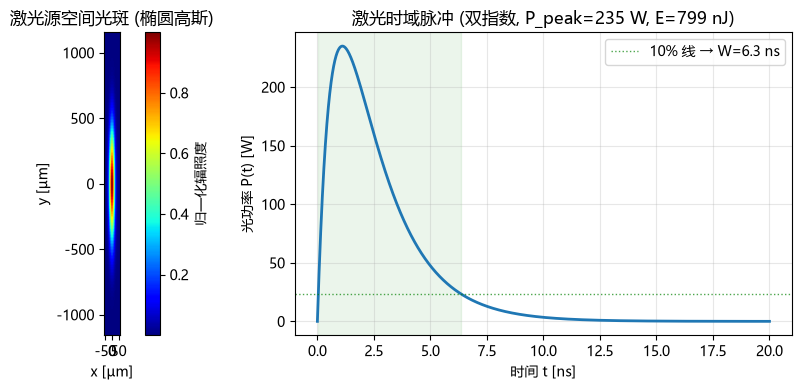

In [2]:
def spot_spatial(x, y, p=PARAMS):
    wx, wy = p["laser"]["x_L"] / 2.0, p["laser"]["y_L"] / 2.0
    return np.exp(-2.0 * (x**2) / wx**2 - 2.0 * (y**2) / wy**2)

def _pulse_norm(p=PARAMS):
    tr, tf = p["laser"]["tau_r"], p["laser"]["tau_f"]
    t_peak = np.log(tf / tr) / (1.0 / tr - 1.0 / tf)
    s_peak = np.exp(-t_peak / tf) - np.exp(-t_peak / tr)
    area_shape = tf - tr
    A = p["laser"]["E_pulse"] * s_peak / area_shape if p["laser"]["amp_mode"] == "energy" else p["laser"]["P_peak"]
    return A, s_peak, t_peak, area_shape

def pulse_temporal(t, p=PARAMS):
    tr, tf = p["laser"]["tau_r"], p["laser"]["tau_f"]
    A, s_peak, _, _ = _pulse_norm(p)
    tpos = np.clip(t, 0.0, None)
    shape = np.where(t >= 0, np.exp(-tpos / tf) - np.exp(-tpos / tr), 0.0)
    return A * np.clip(shape, 0.0, None) / s_peak

def pulse_metrics(p=PARAMS):
    """脉冲特征. 主指标 W_10_10 = 上升10%到下降10%的全宽."""
    t = np.linspace(0, 60e-9, 600001)
    P = pulse_temporal(t, p); pk = P.max(); i_pk = np.argmax(P)
    # 上升沿 10% 时刻 / 下降沿 10% 时刻
    t_rise10 = np.interp(0.1 * pk, P[:i_pk + 1], t[:i_pk + 1])
    td, Pd = t[i_pk:], P[i_pk:]
    t_fall10 = np.interp(0.1 * pk, Pd[::-1], td[::-1])
    W_10_10 = t_fall10 - t_rise10
    fwhm = (lambda a: a[-1] - a[0])(t[P >= 0.5 * pk])
    rise = np.interp(0.9 * pk, P[:i_pk + 1], t[:i_pk + 1]) - t_rise10
    fall = t_fall10 - np.interp(0.9 * pk, Pd[::-1], td[::-1])
    energy = np.trapezoid(P, t)
    return {"W_10_10": W_10_10, "FWHM": fwhm, "rise_10_90": rise, "fall_90_10": fall,
            "energy": energy, "peak": pk, "tau_eff": energy / pk,
            "t_rise10": t_rise10, "t_fall10": t_fall10}

_m = pulse_metrics()
print(f"[amp_mode = {PARAMS['laser']['amp_mode']}]")
print(f"峰值功率 P_peak          = {_m['peak']:.1f} W")
print(f"单脉冲能量 E             = {_m['energy']*1e9:.1f} nJ")
print(f"脉宽 W(10%-10% 全宽)     = {_m['W_10_10']*1e9:.2f} ns   ← v2 主指标")
print(f"  (参考 FWHM 半高全宽     = {_m['FWHM']*1e9:.2f} ns)")
print(f"上升(10-90%)={_m['rise_10_90']*1e9:.2f} ns   下降(90-10%)={_m['fall_90_10']*1e9:.2f} ns   τ_eff=E/P={_m['tau_eff']*1e9:.2f} ns")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
gx = np.linspace(-PARAMS["laser"]["x_L"], PARAMS["laser"]["x_L"], 200)
gy = np.linspace(-PARAMS["laser"]["y_L"], PARAMS["laser"]["y_L"], 200)
GX, GY = np.meshgrid(gx, gy)
im = ax[0].pcolormesh(GX * 1e6, GY * 1e6, spot_spatial(GX, GY), shading="auto", cmap="jet")
ax[0].set_title("激光源空间光斑 (椭圆高斯)")
ax[0].set_xlabel("x [µm]"); ax[0].set_ylabel("y [µm]"); ax[0].set_aspect("equal")
plt.colorbar(im, ax=ax[0], label="归一化辐照度")
tt = np.linspace(0, 20e-9, 3000)
ax[1].plot(tt * 1e9, pulse_temporal(tt), lw=2)
ax[1].axhline(_m["peak"]*0.1, color="g", ls=":", lw=1, alpha=0.7, label=f"10% 线 → W={_m['W_10_10']*1e9:.1f} ns")
ax[1].axvspan(_m["t_rise10"]*1e9, _m["t_fall10"]*1e9, color="g", alpha=0.08)
ax[1].set_title(f"激光时域脉冲 (双指数, P_peak={_m['peak']:.0f} W, E={_m['energy']*1e9:.0f} nJ)")
ax[1].set_xlabel("时间 t [ns]"); ax[1].set_ylabel("光功率 P(t) [W]")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 模块 2 — TX 发射光学

半发散角 = 几何项 ⊕ 衍射项：`θ_geom=尺寸/(2 f_TX)`，`θ_diff≈λ/(π w0)`，`w0=D_TX/2`。
瑞利距离 `z_R≈w0/θ`。

In [3]:
def tx_derived(p=PARAMS):
    x_L, y_L = p["laser"]["x_L"], p["laser"]["y_L"]
    f_TX = p["tx"]["f_TX"]; lam = p["laser"]["wavelength"]; w0 = p["tx"]["D_TX"] / 2.0
    tgx, tgy = x_L / (2 * f_TX), y_L / (2 * f_TX)
    tdf = lam / (np.pi * w0)
    tx_, ty_ = np.hypot(tgx, tdf), np.hypot(tgy, tdf)
    return {"theta_x": tx_, "theta_y": ty_, "theta_geom_x": tgx, "theta_geom_y": tgy,
            "theta_diff": tdf, "zR_x": w0 / tx_, "zR_y": w0 / ty_, "w0": w0,
            "eta_TX": p["tx"]["eta_coupling"] * p["tx"]["T_TX"]}

_tx = tx_derived()
print(f"半发散角  θ_x = {_tx['theta_x']*1e3:.4f} mrad,  θ_y = {_tx['theta_y']*1e3:.4f} mrad")
print(f"  (几何 {_tx['theta_geom_x']*1e3:.4f}/{_tx['theta_geom_y']*1e3:.4f} mrad, 衍射下限 {_tx['theta_diff']*1e3:.4f} mrad)")
print(f"瑞利距离  z_R,x = {_tx['zR_x']:.2f} m,  z_R,y = {_tx['zR_y']:.2f} m")
print(f"出光效率  η_TX = {_tx['eta_TX']:.3f}")

半发散角  θ_x = 0.8346 mrad,  θ_y = 15.9723 mrad
  (几何 0.8333/15.9722 mrad, 衍射下限 0.0454 mrad)
瑞利距离  z_R,x = 7.61 m,  z_R,y = 0.40 m
出光效率  η_TX = 0.800


## 模块 3 — 信道（大气 + 光斑扩展 + 飞行时间）

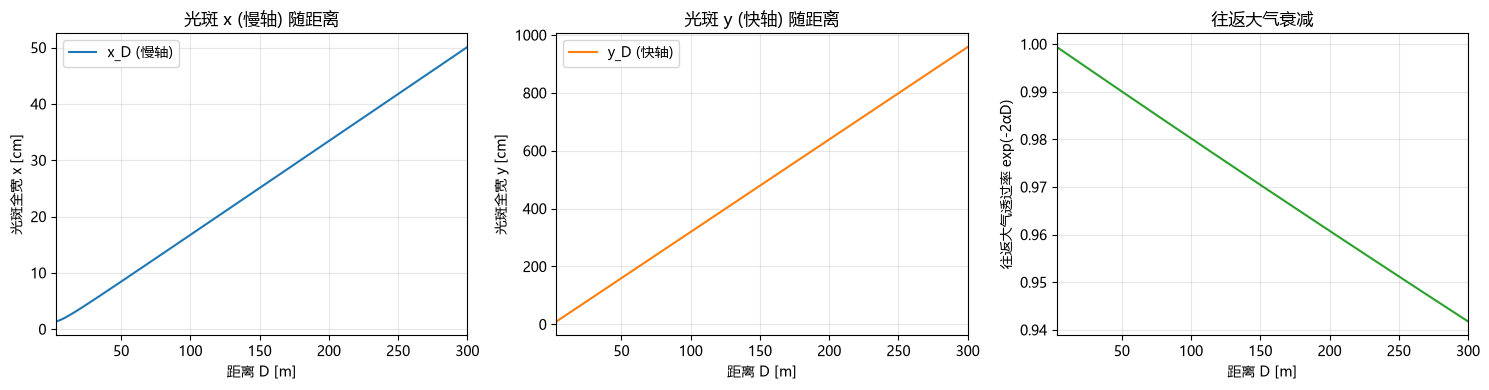

D=   30 m:  光斑   5.17 ×  95.84 cm,  t_ToF=  200.1 ns
D=  120 m:  光斑  20.07 × 383.34 cm,  t_ToF=  800.6 ns
D=  200 m:  光斑  33.41 × 638.89 cm,  t_ToF= 1334.3 ns


In [4]:
def atm_transmission(D, p=PARAMS):
    return np.exp(-p["channel"]["alpha"] * D)

def beam_spot_size(D, p=PARAMS):
    tx = tx_derived(p); w0 = tx["w0"]
    return (2 * w0 * np.sqrt(1 + (D / tx["zR_x"])**2),
            2 * w0 * np.sqrt(1 + (D / tx["zR_y"])**2))

def beam_area(D, p=PARAMS):
    x_D, y_D = beam_spot_size(D, p)
    return np.pi / 4.0 * x_D * y_D

def time_of_flight(D):
    return 2.0 * D / C_LIGHT

Ds = np.linspace(0.1, D_PLOT_MAX, 600)
xD = np.array([beam_spot_size(d)[0] for d in Ds])
yD = np.array([beam_spot_size(d)[1] for d in Ds])
_mvis3 = Ds >= 3.0    # 只画 D>=3m, 使自动 y 轴聚焦可见区间
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
# 光斑 x (慢轴)
ax[0].plot(Ds[_mvis3], xD[_mvis3]*100, color="tab:blue", label="x_D (慢轴)")
ax[0].set_xlabel("距离 D [m]"); ax[0].set_ylabel("光斑全宽 x [cm]")
ax[0].set_title("光斑 x (慢轴) 随距离"); ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].set_xlim(3, D_PLOT_MAX)
# 光斑 y (快轴)
ax[1].plot(Ds[_mvis3], yD[_mvis3]*100, color="tab:orange", label="y_D (快轴)")
ax[1].set_xlabel("距离 D [m]"); ax[1].set_ylabel("光斑全宽 y [cm]")
ax[1].set_title("光斑 y (快轴) 随距离"); ax[1].legend(); ax[1].grid(alpha=0.3); ax[1].set_xlim(3, D_PLOT_MAX)
# 往返大气衰减
ax[2].plot(Ds[_mvis3], atm_transmission(Ds[_mvis3])**2, color="tab:green")
ax[2].set_xlabel("距离 D [m]"); ax[2].set_ylabel("往返大气透过率 exp(-2αD)")
ax[2].set_title("往返大气衰减"); ax[2].grid(alpha=0.3); ax[2].set_xlim(3, D_PLOT_MAX)
plt.tight_layout(); plt.show()
for e in PARAMS["target"]["echoes"]:
    d = e["D"]; xd, yd = beam_spot_size(d)
    print(f"D={d:>5.0f} m:  光斑 {xd*100:6.2f} × {yd*100:6.2f} cm,  t_ToF={time_of_flight(d)*1e9:7.1f} ns")

## 模块 4 — 目标（反射率 + 朗伯漫反射 + 多回波）

朗伯 BRDF（Bidirectional Reflectance Distribution Function，双向反射分布函数）= ρ/π。
倾角展宽：`Δt=2 w tanφ/c`。

In [5]:
def lambertian_brdf(rho):
    return rho / np.pi

def echo_range_broadening_sigma(D, tilt_deg, p=PARAMS):
    x_D, y_D = beam_spot_size(D, p)
    w = 0.5 * np.hypot(x_D, y_D) / np.sqrt(2)
    dz = w * np.tan(np.deg2rad(tilt_deg))
    return (2.0 * dz / C_LIGHT) / 2.0

def check_frac_sum(p=PARAMS):
    s = sum(e["frac"] for e in p["target"]["echoes"])
    print(f"各回波拦截比例之和 = {s:.2f}  [{'OK' if s<=1+1e-9 else '⚠ >1 不物理'}];  余下 {max(0,1-s):.2f} 穿过")
    return s

check_frac_sum()
for e in PARAMS["target"]["echoes"]:
    sig = echo_range_broadening_sigma(e["D"], e["tilt_deg"])
    print(f"  {e['name']:<16} D={e['D']:>5.0f} m, ρ={e['rho']}, frac={e['frac']}, 倾角={e['tilt_deg']}° → 展宽σ={sig*1e12:.0f} ps")

各回波拦截比例之和 = 1.00  [OK];  余下 0.00 穿过
  近处物体(边缘拦截)       D=   30 m, ρ=0.1, frac=1.0, 倾角=0.0° → 展宽σ=0 ps
  主目标(倾斜墙面)        D=  120 m, ρ=0.1, frac=0.0, 倾角=30.0° → 展宽σ=2614 ps
  远处背景             D=  200 m, ρ=0.1, frac=0.0, 倾角=0.0° → 展宽σ=0 ps


## 模块 5 — RX 接收光学（像面光斑：几何 ⊕ 衍射）

### LiDAR 方程（扩展目标，1/D²）
$$P_{RX,k}(t)=P\!\left(t-\tfrac{2D_k}{c}\right)\cdot \eta_{TX}\cdot frac_k\cdot \frac{\rho_k}{\pi}\cdot \frac{A_{RX}}{D_k^2}\cdot e^{-2\alpha D_k}\cdot \eta_{RX}\cdot T_{RX}\cdot T_{filter}$$

### 像面光斑尺寸（几何 ⊕ 衍射）
RX 对**扩展目标面**成像。对 D≫f_RX 的目标，成像是"**角度→像面位置**"：像面尺寸 = 目标张角 × f_RX。
目标张角 = 光束在该处的角宽 `x_D(D)/D`（近场用完整高斯束，远场趋于恒定发散角 `x_L/f_TX`）。
几何像斑 `s_geom = (x_D/D)·f_RX`，再与**衍射艾里斑**（Airy disk）平方和合成：
`s = √(s_geom² + s_Airy²)`，`s_Airy = 2.44 λ (f_RX/D_RX)`。

**像斑为何与距离几乎无关、缩小倍率是多少？** 因为 `x_D ∝ D`（发散）而放大率 `m=f_RX/D ∝ 1/D`，
两者相乘 **D 抵消**，故远场像斑 ≈ `发光区 × f_RX/f_TX`。本例 `f_TX=36mm、f_RX=25mm`，
缩小倍率 `f_TX/f_RX ≈ 1.44×`：60µm→~42µm(短边 x)、1150µm→~800µm(长边 y)，再与艾里斑平方和。
（注：若 f_TX 远大于 f_RX，缩小倍率会大得多；缩小倍率完全由两焦距之比决定。）

> **旧版错误**：直接用"激光光斑物理尺寸 × 放大率 f_RX/D"当像斑，数值偏大且没有衍射下限。

接收孔径 A_RX = 1.327 cm²,  f/# = 1.92,  艾里斑直径 = 4.25 µm
  D=  30m: 像面光斑  43.26 ×  798.70 µm  → 被照像元 5×80=400
  D= 120m: 像面光斑  42.03 ×  798.63 µm  → 被照像元 5×80=400
  D= 200m: 像面光斑  41.97 ×  798.63 µm  → 被照像元 5×80=400
单像元 iFOV = 0.4000 mrad,  阵列 FOV = 3.6×48.0 mrad
探测效率 η=PDE×填充 = 0.300   累加像元数 n_sum=400 (模式='illuminated')


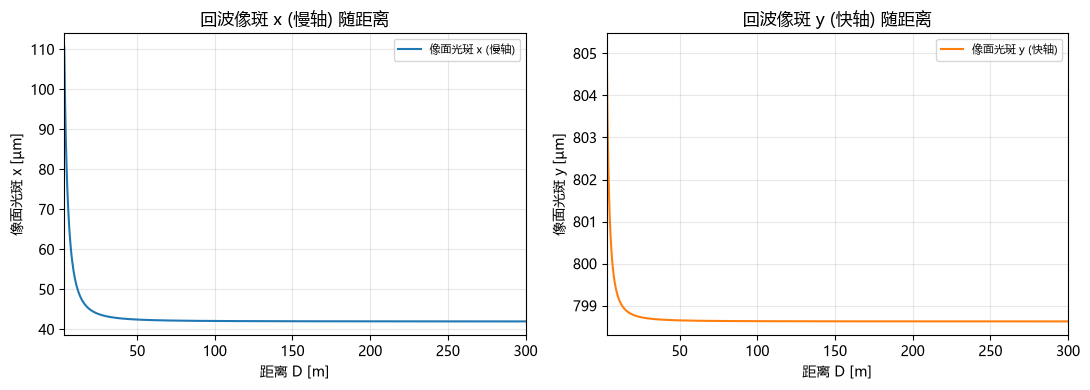

  近处物体(边缘拦截)       link=2.481e-09,  P_RX_peak=582.9781 nW
  主目标(倾斜墙面)        link=0.000e+00,  P_RX_peak=0.0000 nW
  远处背景             link=0.000e+00,  P_RX_peak=0.0000 nW


In [6]:
def rx_area(p=PARAMS):
    return np.pi * (p["rx"]["D_RX"] / 2.0)**2

def airy_diameter(p=PARAMS):
    """衍射极限像点(艾里斑)直径 [m] = 2.44 λ (f/#)."""
    fnum = p["rx"]["f_RX"] / p["rx"]["D_RX"]
    return 2.44 * p["laser"]["wavelength"] * fnum

def rx_image_spot_size(D, p=PARAMS):
    """RX 像面光斑 [m] = 几何成像(角度×f_RX) ⊕ 衍射艾里斑, 平方和."""
    x_D, y_D = beam_spot_size(D, p)
    s_geom_x = (x_D / D) * p["rx"]["f_RX"]
    s_geom_y = (y_D / D) * p["rx"]["f_RX"]
    s_airy = airy_diameter(p)
    return np.hypot(s_geom_x, s_airy), np.hypot(s_geom_y, s_airy)

def array_geometry(D, p=PARAMS):
    sx, sy = rx_image_spot_size(D, p)
    a = p["spad_array"]
    ncx = int(min(a["Nx"], max(1, np.ceil(sx / a["pitch"]))))
    ncy = int(min(a["Ny"], max(1, np.ceil(sy / a["pitch"]))))
    iFOV = a["pitch"] / p["rx"]["f_RX"]
    return {"spot_x": sx, "spot_y": sy, "ncx": ncx, "ncy": ncy, "n_cov": ncx * ncy,
            "iFOV": iFOV, "fov_x": a["Nx"] * iFOV, "fov_y": a["Ny"] * iFOV}

def eta_detection(p=PARAMS):
    return p["spad"]["PDE"] * p["spad_array"]["fill_factor"]

def n_sum_pixels(p=PARAMS):
    a = p["spad_array"]
    if a["sum_pixels"] == "all":
        return a["Nx"] * a["Ny"]
    primary = max(p["target"]["echoes"], key=lambda e: e["frac"])
    return array_geometry(primary["D"], p)["n_cov"]

def link_factor(echo, p=PARAMS):
    tx = tx_derived(p); D = echo["D"]
    Omega = rx_area(p) / D**2
    eta_rx_total = p["rx"]["eta_RX"] * p["rx"]["T_RX"] * p["rx"]["T_filter"]
    return tx["eta_TX"] * echo["frac"] * lambertian_brdf(echo["rho"]) * Omega * atm_transmission(D, p)**2 * eta_rx_total

print(f"接收孔径 A_RX = {rx_area()*1e4:.3f} cm²,  f/# = {PARAMS['rx']['f_RX']/PARAMS['rx']['D_RX']:.2f},  艾里斑直径 = {airy_diameter()*1e6:.2f} µm")
for D in [30, 120, 200]:
    g = array_geometry(D)
    print(f"  D={D:>4}m: 像面光斑 {g['spot_x']*1e6:6.2f} × {g['spot_y']*1e6:7.2f} µm  → 被照像元 {g['ncx']}×{g['ncy']}={g['n_cov']}")
_g120 = array_geometry(120)
print(f"单像元 iFOV = {_g120['iFOV']*1e3:.4f} mrad,  阵列 FOV = {_g120['fov_x']*1e3:.1f}×{_g120['fov_y']*1e3:.1f} mrad")
print(f"探测效率 η=PDE×填充 = {eta_detection():.3f}   累加像元数 n_sum={n_sum_pixels()} (模式='{PARAMS['spad_array']['sum_pixels']}')")

sx_arr = np.array([rx_image_spot_size(d)[0] for d in Ds]) * 1e6
sy_arr = np.array([rx_image_spot_size(d)[1] for d in Ds]) * 1e6
_mvis = Ds >= 3.0    # 只画 D>=3m, 使自动 y 轴聚焦可见区间(近场 D->0 像斑发散会污染范围)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
# 左: x (慢轴) 线性
ax[0].plot(Ds[_mvis], sx_arr[_mvis], color="tab:blue", label="像面光斑 x (慢轴)")
ax[0].set_xlabel("距离 D [m]"); ax[0].set_ylabel("像面光斑 x [µm]")
ax[0].set_title("回波像斑 x (慢轴) 随距离"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3); ax[0].set_xlim(3, D_PLOT_MAX)
# 右: y (快轴) 线性
ax[1].plot(Ds[_mvis], sy_arr[_mvis], color="tab:orange", label="像面光斑 y (快轴)")
ax[1].set_xlabel("距离 D [m]"); ax[1].set_ylabel("像面光斑 y [µm]")
ax[1].set_title("回波像斑 y (快轴) 随距离"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3); ax[1].set_xlim(3, D_PLOT_MAX)
plt.tight_layout(); plt.show()
for e in PARAMS["target"]["echoes"]:
    lf = link_factor(e)
    print(f"  {e['name']:<16} link={lf:.3e},  P_RX_peak={PARAMS['laser']['P_peak']*lf*1e9:.4f} nW")

## 模块 6（v10 新增）— 单 SPAD 光子到达率（不含 PDE）

把到达像面的回波**总功率**按**椭圆高斯像斑**分配到每个物理像元(用误差函数 erf 对像元窗口积分),
得到**每个 SPAD 各自的**信号光子到达率 r_ph(t)(单位 photons/s, **不含 PDE**)。
环境光按单像元均匀铺底, 也给出不含 PDE 的光子率。

- 像斑 1/e² 全宽 s(来自模块 5) → 高斯 σ = s/4; 像元窗口 [c−pitch/2, c+pitch/2] 内高斯积分 = erf 差分。
- 像斑中心默认对准阵列中心; 每个像元收集比例不同(中心高、边缘低) ⇒ 每个 SPAD 的率不同。
- 倾角展宽(几何真实, 非 IRF)并入信号率(对 30m、tilt=0 无影响, 代码通用保留)。

> 关键: 这里用**未乘 PDE** 的光子率; PDE 留到模块 7 蒙卡里逐光子判定。

In [7]:
from scipy.special import erf

def gaussian_kernel(sigma, dt, n_sigma=5):
    """归一化高斯卷积核(∫k·dt=1); 供 IRF/倾角展宽卷积用(与 v4 定义一致)。"""
    if sigma <= 0:
        return np.array([1.0 / dt])
    half = max(1, int(np.ceil(n_sigma * sigma / dt)))
    tk = np.arange(-half, half + 1) * dt
    k = np.exp(-0.5 * (tk / sigma)**2)
    return k / (k.sum() * dt)

def ambient_photon_rate_per_pixel(p=PARAMS):
    """单像元环境光【光子到达率】[photons/s], 不含 PDE
    (与 v4 的 ambient_count_rate_per_pixel 相差一个 PDE 因子)。"""
    if not p["ambient"]["enable"]:
        return 0.0
    E = p["ambient"]["E_lambda"] * (p["rx"]["filter_bw"] * 1e9)   # 带内辐照 [W/m²]
    L = p["ambient"]["surface_rho"] * E / np.pi                   # 辐亮度 [W/m²/sr]
    iFOV = p["spad_array"]["pitch"] / p["rx"]["f_RX"]
    P_amb = L * iFOV**2 * rx_area(p)                              # 单像元带内功率 [W]
    return P_amb / E_PHOTON * p["rx"]["T_RX"] * p["rx"]["T_filter"]   # 不含 PDE

def pixel_grid(p=PARAMS):
    """阵列各像元中心坐标 [m](以阵列中心为原点); 像斑中心默认对准阵列中心。"""
    a = p["spad_array"]; pitch = a["pitch"]
    xi = (np.arange(a["Nx"]) - (a["Nx"] - 1) / 2.0) * pitch   # x=短边
    yj = (np.arange(a["Ny"]) - (a["Ny"] - 1) / 2.0) * pitch   # y=长边
    return xi, yj

def pixel_collection_matrix(D, p=PARAMS):
    """每个像元在椭圆高斯像斑上的空间收集比例 f_pix[i,j] (∑≤1, 其余漏到阵列外)。
    返回 (f_pix[Nx,Ny], fx[Nx], fy[Ny])。"""
    sx, sy = rx_image_spot_size(D, p)          # 1/e² 全宽 (x=短边, y=长边)
    sig_x, sig_y = sx / 4.0, sy / 4.0          # 高斯 σ
    xi, yj = pixel_grid(p); pitch = p["spad_array"]["pitch"]
    def _frac(centers, sig):                   # 各像元窗口内一维高斯积分(erf 差分)
        lo = (centers - pitch / 2.0) / (np.sqrt(2) * sig)
        hi = (centers + pitch / 2.0) / (np.sqrt(2) * sig)
        return 0.5 * (erf(hi) - erf(lo))
    fx = _frac(xi, sig_x); fy = _frac(yj, sig_y)
    return np.outer(fx, fy), fx, fy

def _single_echo_rate(echo, f_pix_ij, tf, p, link_scale=1.0):
    """单个(子)回波的光子率: 双指数脉冲 × 链路 × 收集比例, 已含倾角几何展宽(高斯)。"""
    t0 = time_of_flight(echo["D"])
    r = pulse_temporal(tf - t0, p) * link_factor(echo, p) * link_scale / E_PHOTON * f_pix_ij
    sig_b = echo_range_broadening_sigma(echo["D"], echo.get("tilt_deg", 0.0), p)  # 倾角几何展宽
    if sig_b > 0:
        dt_fine = tf[1] - tf[0]
        r = np.convolve(r, gaussian_kernel(sig_b, dt_fine), mode="same") * dt_fine
    return r

def signal_photon_rate_fine(echo, f_pix_ij, tf, p=PARAMS):
    """单 SPAD 信号【光子到达率】(不含 PDE)在精细网格 tf 上, 含倾角几何展宽。"""
    return _single_echo_rate(echo, f_pix_ij, tf, p)

# --- 自检: 主目标(frac 最大, 本例 30m) 的像元收集分布 ---
echo0 = max(PARAMS["target"]["echoes"], key=lambda e: e["frac"])
D0 = echo0["D"]
fpix0, fx0, fy0 = pixel_collection_matrix(D0)
i0, j0 = int(np.argmax(fx0)), int(np.argmax(fy0))     # 收集最强的像元(≈阵列中心)
sx0, sy0 = rx_image_spot_size(D0)
r_amb_ph = ambient_photon_rate_per_pixel()
print(f"主目标 D={D0:.0f} m  (frac={echo0['frac']}, ρ={echo0['rho']}, tilt={echo0['tilt_deg']}°)")
print(f"像斑 1/e² 全宽: x(短边)={sx0*1e6:.1f} µm, y(长边)={sy0*1e6:.1f} µm  → σ_x={sx0/4*1e6:.1f}, σ_y={sy0/4*1e6:.1f} µm")
print(f"阵列 {PARAMS['spad_array']['Nx']}×{PARAMS['spad_array']['Ny']}, pitch={PARAMS['spad_array']['pitch']*1e6:.0f} µm; "
      f"像斑总落片比例 ∑f_pix={fpix0.sum():.3f}")
print(f"最强像元 (i0,j0)=({i0},{j0}): f_pix={fpix0[i0,j0]:.3e}  (fx={fx0[i0]:.3f}, fy={fy0[j0]:.3f})")
print(f"单像元环境光光子率(不含 PDE) r_amb = {r_amb_ph:.3e} ph/s "
      f"(×PDE={PARAMS['spad']['PDE']} → 计数率 {r_amb_ph*PARAMS['spad']['PDE']:.3e} cps, 应与 v4 一致)")

主目标 D=30 m  (frac=1.0, ρ=0.1, tilt=0.0°)
像斑 1/e² 全宽: x(短边)=43.3 µm, y(长边)=798.7 µm  → σ_x=10.8, σ_y=199.7 µm
阵列 9×120, pitch=10 µm; 像斑总落片比例 ∑f_pix=0.997
最强像元 (i0,j0)=(4,59): f_pix=7.113e-03  (fx=0.356, fy=0.020)
单像元环境光光子率(不含 PDE) r_amb = 2.036e+07 ph/s (×PDE=0.3 → 计数率 6.107e+06 cps, 应与 v4 一致)


## 模块 6b（v14 新增）— SPAD 阵列俯视图：网格 + 光斑轮廓 + 按收集比例涂色

在像面(SPAD 阵列平面)上直观展示回波像斑落在阵列上的样子:
- **方格**: 9×120 物理 SPAD 阵列(pitch=10µm), 每格一个 SPAD;
- **光斑轮廓**: 30m 目标回波的椭圆高斯像斑, 画出 1/e²(全宽 s)与 1σ(=s/4)两条椭圆;
- **涂色**: 每个 SPAD 按其空间收集比例 `f_pix` 着色(颜色越亮=接收信号越多)。

> x=短边(9 个 SPAD), y=长边(120 个 SPAD); 像斑长边 σ_y≈200µm≈20 像元, 短边 σ_x≈11µm≈1 像元。

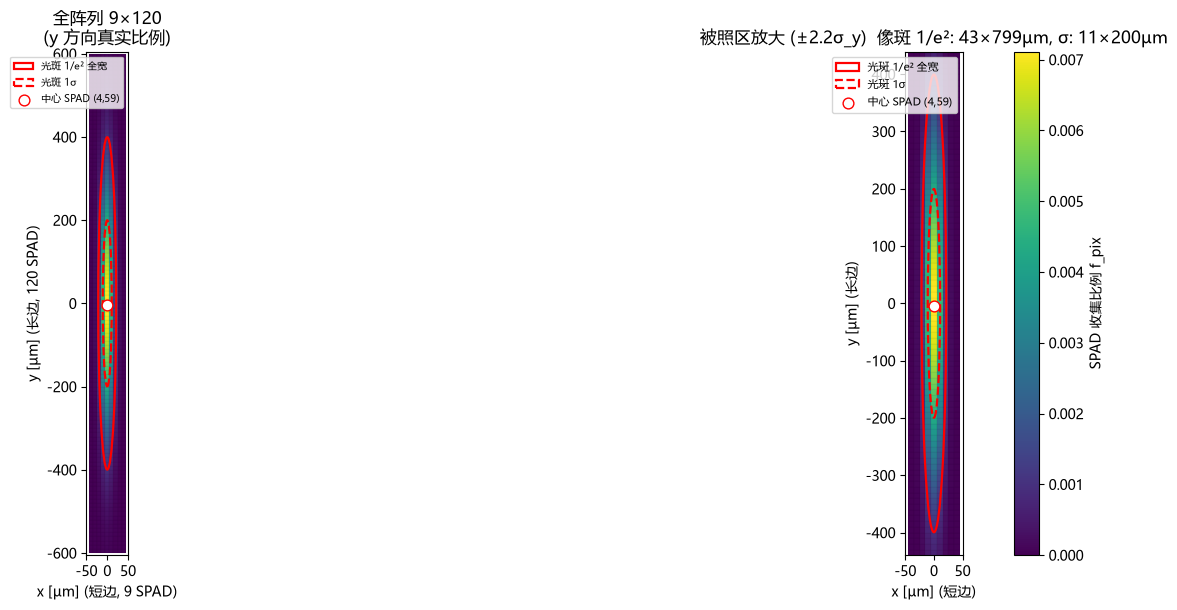

光斑覆盖: 被照 SPAD(f_pix>1%峰值) 约 660 个 / 共 1080 个
像斑长边 σ_y=200µm ≈ 20 像元; 短边 σ_x=11µm ≈ 1 像元
中心 SPAD (4,59) f_pix=7.113e-03; 涂色越亮=收集越多。


In [8]:
from matplotlib.patches import Ellipse, Rectangle
from matplotlib.collections import PatchCollection

# 阵列几何(以阵列中心为原点, 单位 µm)
a = PARAMS["spad_array"]; pitch_um = a["pitch"]*1e6
Nx, Ny = a["Nx"], a["Ny"]
xi_um = (np.arange(Nx) - (Nx-1)/2.0) * pitch_um     # 各 SPAD 中心 x
yj_um = (np.arange(Ny) - (Ny-1)/2.0) * pitch_um     # 各 SPAD 中心 y

# 像斑参数(30m 主目标)
sx_um, sy_um = sx0*1e6, sy0*1e6                       # 1/e² 全宽 [µm]
sig_x_um, sig_y_um = sx_um/4.0, sy_um/4.0            # 1σ [µm]

# 涂色: 归一化 f_pix
fnorm = fpix0 / fpix0.max()
cmap = plt.cm.viridis

fig, axes = plt.subplots(1, 2, figsize=(13, 6.2),
                         gridspec_kw={"width_ratios":[1, 2.6]})

# ---- 左: 全阵列(y 方向很长) ----
def draw_array(ax, show_all_grid):
    rects = []; colors = []
    for ii in range(Nx):
        for jj in range(Ny):
            x = xi_um[ii]-pitch_um/2; y = yj_um[jj]-pitch_um/2
            rects.append(Rectangle((x, y), pitch_um, pitch_um))
            colors.append(cmap(fnorm[ii, jj]))
    pc = PatchCollection(rects, facecolor=colors, edgecolor=(0,0,0,0.15), linewidth=0.2)
    ax.add_collection(pc)
    # 光斑椭圆(中心在原点)
    for k, ls, lab in [(1.0,"-","光斑 1/e² 全宽"), (0.5,"--","光斑 1σ")]:
        # 1/e² 全宽 = 2*(s/2)=s => 半轴 = s/2; 1σ 半轴 = sig
        wx = (sx_um if k==1.0 else 2*sig_x_um); wy = (sy_um if k==1.0 else 2*sig_y_um)
        ax.add_patch(Ellipse((0,0), wx, wy, fill=False, edgecolor="red",
                             ls=ls, lw=1.6, label=lab))
    ax.scatter([xi_um[i0]], [yj_um[j0]], c="white", edgecolor="red", marker="o", s=60,
               zorder=5, label=f"中心 SPAD ({i0},{j0})")

draw_array(axes[0], True)
axes[0].set_xlim(xi_um[0]-pitch_um, xi_um[-1]+pitch_um)
axes[0].set_ylim(yj_um[0]-pitch_um, yj_um[-1]+pitch_um)
axes[0].set_aspect("equal")
axes[0].set_xlabel("x [µm] (短边, 9 SPAD)"); axes[0].set_ylabel("y [µm] (长边, 120 SPAD)")
axes[0].set_title("全阵列 9×120\n(y 方向真实比例)")
axes[0].legend(fontsize=7, loc="upper right")

# ---- 右: 放大被照区(y 方向裁剪到光斑附近) ----
draw_array(axes[1], False)
y_half = 2.2*sig_y_um
axes[1].set_xlim(xi_um[0]-pitch_um, xi_um[-1]+pitch_um)
axes[1].set_ylim(-y_half, y_half)
axes[1].set_aspect("equal")
axes[1].set_xlabel("x [µm] (短边)"); axes[1].set_ylabel("y [µm] (长边)")
axes[1].set_title(f"被照区放大 (±2.2σ_y)  像斑 1/e²: {sx_um:.0f}×{sy_um:.0f}µm, σ: {sig_x_um:.0f}×{sig_y_um:.0f}µm")
axes[1].legend(fontsize=8, loc="upper right")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, fpix0.max()))
plt.colorbar(sm, ax=axes[1], label="SPAD 收集比例 f_pix", fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

n_lit = int((fpix0 > fpix0.max()*0.01).sum())
print(f"光斑覆盖: 被照 SPAD(f_pix>1%峰值) 约 {n_lit} 个 / 共 {Nx*Ny} 个")
print(f"像斑长边 σ_y={sig_y_um:.0f}µm ≈ {sig_y_um/pitch_um:.0f} 像元; 短边 σ_x={sig_x_um:.0f}µm ≈ {sig_x_um/pitch_um:.0f} 像元")
print(f"中心 SPAD ({i0},{j0}) f_pix={fpix0[i0,j0]:.3e}; 涂色越亮=收集越多。")

## 模块 7（v10 新增）— 单 SPAD 蒙特卡洛探测引擎（逐光子，预留 dead time）

一次 shot 的处理:
1. 每精细 bin 入射光子数 ~ **Poisson(r_ph·dt)**, 展开成逐光子到达时刻(=精细 bin 中心)。
2. **有限 PDE**: 每个入射光子独立以概率 PDE 触发雪崩; **n 个光子全未触发 ⇒ 无计数**(蒙卡本质)。
3. **IRF** 高斯抖动只加在被记录事件的时间戳上(雪崩时刻本身留给 dead time 判定)。
4. **dead time 已预留**(当前 t_dead=0 不生效): 探测一次后 t_dead 内不再响应。

返回该 SPAD 本次 shot 的事件时间戳数组 → 可 rebin 成 1ns 直方图。

In [9]:
def simulate_spad_shot(r_sig_fine, r_amb_ph, tf, PDE, t_dead, jitter_sigma, rng):
    """单 SPAD 单次 shot 蒙卡, 返回被记录事件时间戳数组 [s]。
    r_sig_fine: 信号光子率(不含 PDE)在精细网格 tf 上; r_amb_ph: 环境光光子率(标量, 不含 PDE)。
    dead time=0 时每光子独立(向量化); t_dead>0 走逐事件扫描(将来用)。"""
    dt = tf[1] - tf[0]
    mu = (r_sig_fine + r_amb_ph) * dt                 # 每精细 bin 期望入射光子数
    n_ph = rng.poisson(mu)                            # 每 bin 实际入射光子数
    if n_ph.sum() == 0:
        return np.empty(0)
    t_arr = np.repeat(tf, n_ph)                       # 逐光子到达时刻(bin 中心), 已升序
    fired = rng.random(t_arr.size) < PDE              # 每个入射光子是否触发雪崩(PDE)

    if t_dead <= 0:                                   # —— dead time=0: 每光子独立, 向量化 ——
        t_fire = t_arr[fired]
        if jitter_sigma > 0 and t_fire.size:
            t_fire = t_fire + rng.normal(0.0, jitter_sigma, t_fire.size)   # IRF 抖动(只影响记录时间戳)
        return t_fire

    # —— dead time>0: 逐事件扫描(接口预留, 现在不会走到) ——
    det = []; last = -np.inf
    for t, f in zip(t_arr, fired):
        if not f:
            continue
        if (t - last) < t_dead:                       # 死时间内: 吞掉, 不响应
            continue
        last = t                                      # 记录雪崩时刻(未加 IRF)
        det.append(t + (rng.normal(0.0, jitter_sigma) if jitter_sigma > 0 else 0.0))
    return np.asarray(det)

def events_to_hist(events, t_lo, t_hi, bin_width):
    """事件时间戳 → 直方图。返回 (bin 中心, 计数, bin 边界)。"""
    nb = int(round((t_hi - t_lo) / bin_width))
    edges = t_lo + np.arange(nb + 1) * bin_width
    counts, _ = np.histogram(events, bins=edges)
    centers = 0.5 * (edges[:-1] + edges[1:])
    return centers, counts, edges

print("蒙卡引擎就绪: simulate_spad_shot() 逐光子(PDE 判定 + IRF 抖动 + dead time 预留); events_to_hist() 直方图化。")

蒙卡引擎就绪: simulate_spad_shot() 逐光子(PDE 判定 + IRF 抖动 + dead time 预留); events_to_hist() 直方图化。


## 模块 7b（v13 新增）— RC 恢复 SPAD 蒙特卡洛引擎

雪崩后过电压 Vov 不是"突变恢复", 而是按 RC 指数充回(见 SPAD 等效电路: 淬灭电阻 R + 结电容 C_J):
$$V_{ov}(\Delta t)=V_{ov,max}\,(1-e^{-\Delta t/\tau}),\qquad \tau=R\,C_J$$
其中 Δt = 距上次**计数事件**经过的时间(仅计数事件复位)。

单次 shot 逐光子处理:
1. 每精细 bin 入射光子 ~Poisson(r·dt), 展开为逐光子到达时刻。
2. 光子到达时, 当前 `vov_frac = 1 - exp(-Δt/τ)`; 触发概率 `PDE_max · vov_frac`(线性 PDE∝Vov)。
3. 触发后: 若 `vov_frac ≥ Vth_frac` ⇒ **计一次数**, 记录时间戳(加 IRF 抖动), 并复位(Δt 归零);
   否则(亚阈)⇒ 不计数; `reset='all'` 时也复位, `reset='count'` 时不复位。

> 与硬死时间的关键区别: RC 恢复期是**渐变灵敏**(概率随 Vov 连续上升), 而非"非 0 即 1"的硬开关。

> v14: 参数(PDE、硬死时间、τ_RC、Vov_max、Vth、reset)统一从 `PARAMS["spad"]` 读取;
> 另附 `simulate_spad_shot_rc_trace()` 记录 Vov(t) 轨迹, 供模块 8b 画过电压曲线。

> **v20 变化**: (1) 触发概率由 `PDE_max·vov_frac` 改为 **`PDE_max·g(vov_frac)`**, 响应函数
> `g` 可选 `linear`(=旧版) 或 `exp`(凹形快起饱和), 满足 g(0)=0、g(1)=1(见 `spad_response_g`);
> (2) 阈值 `Vth_frac` 提到 **0.60**, τ_RC 调到 **8.73ns** 使计数死区(可再次探测最小间隔)=**8ns**。

In [10]:
def spad_response_g(vov_frac, shape="linear", k=3.0):
    """SPAD 对光子的响应函数 g(vov_frac) ∈ [0,1]: 触发概率 = PDE_max · g(vov_frac)。
    约束: g(0)=0 (Vov=0 完全不响应, 对光子完全不触发), g(1)=1 (满 Vov 触发概率=PDE_max)。
      shape="linear": g(x)=x            (线性, PDE∝Vov; 与 v15 完全一致)
      shape="exp"   : g(x)=(1-e^(-k·x))/(1-e^(-k))  (k>0 凹形: 低 Vov 即有明显响应, 随后饱和)
    vov_frac 可为标量或数组。"""
    x = np.clip(vov_frac, 0.0, 1.0)
    if shape == "exp":
        return (1.0 - np.exp(-k * x)) / (1.0 - np.exp(-k))
    return x   # linear (默认)

def simulate_spad_shot_rc(r_sig_fine, r_amb_ph, tf, PDE_max, tau_rc, Vth_frac,
                          jitter_sigma, rng, reset_mode="count", Vov_max=3.3,
                          resp_shape="linear", resp_k=3.0):
    """RC 恢复 SPAD 单次 shot 蒙卡, 返回被计数事件的记录时间戳数组 [s]。
    r_sig_fine: 信号光子率(不含 PDE)在精细网格 tf 上; r_amb_ph: 环境光光子率(标量, 不含 PDE)。
    tau_rc: RC 恢复时间常数 = R·C_J; Vth_frac: 计数所需最小 Vov 占 Vov_max 比例;
    reset_mode: 'count'=仅计数事件复位 Vov; 'all'=任何雪崩(含亚阈)都复位。"""
    dt = tf[1] - tf[0]
    mu = (r_sig_fine + r_amb_ph) * dt
    n_ph = rng.poisson(mu)
    if n_ph.sum() == 0:
        return np.empty(0)
    t_arr = np.repeat(tf, n_ph)            # 逐光子到达时刻(升序)
    u = rng.random(t_arr.size)             # 每光子随机数(判触发)
    det = []
    last = -1e30                            # 上次复位时刻
    inv_tau = 1.0 / tau_rc
    for k in range(t_arr.size):
        t = t_arr[k]
        d = (t - last) * inv_tau
        vov_frac = 1.0 - np.exp(-d) if d < 700 else 1.0   # 当前 Vov/Vov_max
        p_fire = PDE_max * spad_response_g(vov_frac, resp_shape, resp_k)  # 触发概率=PDE_max·g(Vov)
        if u[k] < p_fire:                                 # 雪崩触发(概率∝g(Vov))
            if vov_frac >= Vth_frac:                      # 幅度够阈 -> 计数
                det.append(t)
                last = t                                  # 计数事件复位 Vov
            elif reset_mode == "all":
                last = t                                  # 亚阈雪崩也复位(仅 all 模式)
    det = np.asarray(det)
    if jitter_sigma > 0 and det.size:
        det = det + rng.normal(0.0, jitter_sigma, det.size)   # IRF 抖动只加在记录时间戳
    return det

def simulate_spad_shot_rc_trace(r_sig_fine, r_amb_ph, tf, PDE_max, tau_rc, Vth_frac,
                                jitter_sigma, rng, reset_mode="count", Vov_max=3.3,
                                resp_shape="linear", resp_k=3.0):
    """与 simulate_spad_shot_rc 同逻辑, 但额外记录 Vov(t) 轨迹供可视化(模块 8b 用)。
    返回 dict: t_photon(所有入射光子时刻), fired(是否触发雪崩), counted(是否计数),
    vov_at_photon(光子到达瞬间的 Vov 比例), t_count(计数事件时刻), t_grid/vov_grid(连续 Vov 曲线)。"""
    dt = tf[1] - tf[0]
    mu = (r_sig_fine + r_amb_ph) * dt
    n_ph = rng.poisson(mu)
    t_arr = np.repeat(tf, n_ph) if n_ph.sum() else np.empty(0)
    u = rng.random(t_arr.size)
    fired = np.zeros(t_arr.size, dtype=bool)
    counted = np.zeros(t_arr.size, dtype=bool)
    vov_at = np.zeros(t_arr.size)
    resets = []                                  # 复位时刻(用于重建连续曲线)
    last = -1e30; inv_tau = 1.0 / tau_rc
    for k in range(t_arr.size):
        t = t_arr[k]; d = (t - last) * inv_tau
        vf = 1.0 - np.exp(-d) if d < 700 else 1.0
        vov_at[k] = vf
        if u[k] < PDE_max * spad_response_g(vf, resp_shape, resp_k):
            fired[k] = True
            if vf >= Vth_frac:
                counted[k] = True; last = t; resets.append(t)
            elif reset_mode == "all":
                last = t; resets.append(t)
    # 连续 Vov(t) 曲线: 在精细网格上按"距上次复位"重建
    tg = tf.copy()
    last = -1e30; vg = np.ones(tg.size)
    ri = 0; resets = np.asarray(resets)
    for idx in range(tg.size):
        t = tg[idx]
        while ri < resets.size and resets[ri] <= t:
            last = resets[ri]; ri += 1
        d = (t - last) * inv_tau
        vg[idx] = 1.0 - np.exp(-d) if d < 700 else 1.0
    t_count = t_arr[counted]
    return {"t_photon": t_arr, "fired": fired, "counted": counted, "vov_at_photon": vov_at,
            "t_count": t_count, "t_grid": tg, "vov_grid": vg}

# ---- RC / 死时间参数: 统一从 PARAMS["spad"] 读取(v14) ----
_sp = PARAMS["spad"]
PDE      = _sp["PDE"]            # = PDE_max
JIT      = _sp["jitter_sigma"]
T_DEAD   = _sp["t_dead"]         # 硬死时间(对照)
TAU_RC   = _sp["tau_rc"]         # RC 恢复时间常数
VOV_MAX  = _sp["Vov_max"]
VTH_FRAC = _sp["Vth_frac"]
RESET    = _sp["reset_mode"]
RESP_SHAPE = _sp.get("resp_shape", "linear")   # v20: 响应函数形状
RESP_K     = _sp.get("resp_k", 3.0)            # v20: exp 曲率
jit = JIT; t_dead = T_DEAD       # 小写别名(下游模块 8/9/11/12 沿用旧命名)

# 计数死区: Vov 需恢复到 Vth 才能再次计数 -> 最小间隔 t_deadzone = -τ·ln(1-Vth_frac)
t_deadzone = -np.log(1 - VTH_FRAC) * TAU_RC
print(f"参数来自 PARAMS['spad']: PDE_max={PDE}, 硬死时间={T_DEAD*1e9:.1f}ns, tau_RC={TAU_RC*1e9:.3f}ns, "
      f"Vov_max={VOV_MAX}V, Vth={VTH_FRAC*100:.0f}%, reset='{RESET}'")
print(f"  响应函数 g(Vov): shape='{RESP_SHAPE}'" + (f", k={RESP_K}" if RESP_SHAPE=="exp" else "")
      + f"  (触发概率=PDE_max*g(vov_frac); g(0)=0, g(1)=1)")
print(f"  Vov 恢复曲线: 1tau->{100*(1-np.exp(-1)):.0f}%, 2.3tau->{100*(1-np.exp(-2.3)):.0f}%, 5tau->{100*(1-np.exp(-5)):.1f}%")
print(f"  [v20] 计数死区(可再次探测最小间隔) = -tau*ln(1-Vth) = {t_deadzone*1e9:.2f} ns  (目标 8ns)")

参数来自 PARAMS['spad']: PDE_max=0.3, 硬死时间=14.0ns, tau_RC=8.731ns, Vov_max=3.3V, Vth=60%, reset='count'
  响应函数 g(Vov): shape='exp', k=3.0  (触发概率=PDE_max*g(vov_frac); g(0)=0, g(1)=1)
  Vov 恢复曲线: 1tau->63%, 2.3tau->90%, 5tau->99.3%
  [v20] 计数死区(可再次探测最小间隔) = -tau*ln(1-Vth) = 8.00 ns  (目标 8ns)


## 模块 7c（v20 新增）— SPAD 对光子的响应函数 g(Vov)

单个入射光子的**触发概率 = PDE_max · g(vov_frac)**, 其中 `vov_frac = Vov/Vov_max ∈ [0,1]`。
响应函数 `g` 描述"过电压越高、越容易触发雪崩", 满足两个物理边界:
- **g(0)=0**: 过电压为 0 时对光子**完全不响应**(刚雪崩淬灭、尚未恢复);
- **g(1)=1**: 过电压满值时触发概率 = **PDE_max**(=0.30, 峰值 PDE)。

两种可选形状(`PARAMS["spad"]["resp_shape"]`):
- **linear**: g(x)=x —— PDE 正比于 Vov(与 v13–v15 一致);
- **exp(凹形)**: g(x)=(1−e^(−k·x))/(1−e^(−k)), k>0 —— 低 Vov 即有明显响应、随后饱和, 更贴近真实 SPAD 的 PDE–Vov 曲线。

> 注意: 响应函数 g 决定"**能否触发雪崩**"; 计数阈值 `Vth_frac` 决定"**触发后幅度够不够被计数**"。二者独立。
> 本版全局采用 `shape='exp'`。

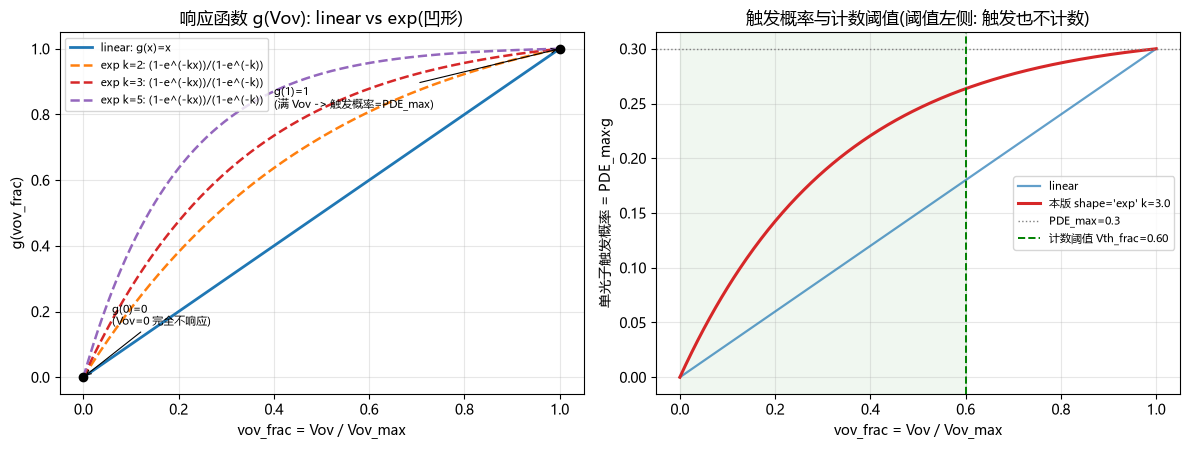

全局响应函数: shape='exp', k=3.0
  g(0)=0.000, g(0.5)=0.818, g(1)=1.000  (触发概率 = 0.3*g)
  满 Vov 触发概率 = PDE_max*g(1) = 0.300 (=PDE_max)
  exp 凹形: 在 vov_frac=Vth=0.60 处 g=0.878 (线性同点 g=0.60); 低 Vov 响应被抬高。


In [11]:
# 画响应函数 g(vov_frac): linear vs exp(几种 k), 并标注全局所用形状
xx = np.linspace(0, 1, 400)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))

# 左: g(x) 本身
ax[0].plot(xx, spad_response_g(xx, "linear"), lw=2.0, color="tab:blue", label="linear: g(x)=x")
for kk, c in zip([2, 3, 5], ["tab:orange", "tab:red", "tab:purple"]):
    ax[0].plot(xx, spad_response_g(xx, "exp", kk), lw=1.8, ls="--", color=c,
               label=f"exp k={kk}: (1-e^(-kx))/(1-e^(-k))")
ax[0].scatter([0, 1], [0, 1], c="k", zorder=5)
ax[0].annotate("g(0)=0\n(Vov=0 完全不响应)", (0, 0), xytext=(0.06, 0.16), fontsize=8,
               arrowprops=dict(arrowstyle="->", lw=0.8))
ax[0].annotate("g(1)=1\n(满 Vov -> 触发概率=PDE_max)", (1, 1), xytext=(0.40, 0.82), fontsize=8,
               arrowprops=dict(arrowstyle="->", lw=0.8))
ax[0].set_xlabel("vov_frac = Vov / Vov_max"); ax[0].set_ylabel("g(vov_frac)")
ax[0].set_title("响应函数 g(Vov): linear vs exp(凹形)")
ax[0].legend(fontsize=8, loc="upper left"); ax[0].grid(alpha=0.3)

# 右: 实际触发概率 = PDE_max·g, 叠加阈值线(Vth 左侧即便触发也不计数)
ax[1].plot(xx, PDE * spad_response_g(xx, "linear"), lw=1.6, color="tab:blue", alpha=0.7, label="linear")
ax[1].plot(xx, PDE * spad_response_g(xx, RESP_SHAPE, RESP_K), lw=2.2, color="tab:red",
           label=f"本版 shape='{RESP_SHAPE}'" + (f" k={RESP_K}" if RESP_SHAPE=="exp" else ""))
ax[1].axhline(PDE, color="gray", ls=":", lw=1.0, label=f"PDE_max={PDE}")
ax[1].axvline(VTH_FRAC, color="green", ls="--", lw=1.4, label=f"计数阈值 Vth_frac={VTH_FRAC:.2f}")
ax[1].axvspan(0, VTH_FRAC, color="green", alpha=0.06)
ax[1].set_xlabel("vov_frac = Vov / Vov_max"); ax[1].set_ylabel("单光子触发概率 = PDE_max·g")
ax[1].set_title("触发概率与计数阈值(阈值左侧: 触发也不计数)")
ax[1].legend(fontsize=8, loc="center right"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"全局响应函数: shape='{RESP_SHAPE}'" + (f", k={RESP_K}" if RESP_SHAPE=="exp" else ""))
print(f"  g(0)={spad_response_g(0.0, RESP_SHAPE, RESP_K):.3f}, g(0.5)={spad_response_g(0.5, RESP_SHAPE, RESP_K):.3f}, "
      f"g(1)={spad_response_g(1.0, RESP_SHAPE, RESP_K):.3f}  (触发概率 = {PDE}*g)")
print(f"  满 Vov 触发概率 = PDE_max*g(1) = {PDE*spad_response_g(1.0, RESP_SHAPE, RESP_K):.3f} (=PDE_max)")
if RESP_SHAPE == "exp":
    print(f"  exp 凹形: 在 vov_frac=Vth={VTH_FRAC:.2f} 处 g={spad_response_g(VTH_FRAC, RESP_SHAPE, RESP_K):.3f} "
          f"(线性同点 g={VTH_FRAC:.2f}); 低 Vov 响应被抬高。")

## 模块 8（v13 更新）— 单 SPAD: RC 恢复模型 vs 硬死时间（timestamp + 1ns 直方图）

取像斑中心 SPAD, 只在 30m 目标 ToF 附近仿真。**同一批入射光子**下对比两种模型:
- **图 1（timestamp）**: 单次 shot, RC 模型 vs 硬死时间(14ns) 各自探测到的光子时间戳(raster)。
- **图 2（1ns 直方图 + 均值）**: 多 shot 蒙卡均值, RC vs 硬死时间 vs 解析上限(无死时间)。

> RC 恢复期渐变灵敏 ⇒ 峰值区计数应**高于**硬死时间、**低于**无死时间上限。

In [12]:
# ============================================================================
# 模块 0b（v41 新增）— 全局时间窗与绘图窗设置
#   原 v32 把时间窗定义混在"模块8(RC vs 硬死时间演示)"里；v41 把模块8 演示废弃，
#   故将【全局时间窗定义】独立到此处，供下游所有二值 MC 模块(11/11b/12/13/14/18/12b
#   及模块19/20)统一使用。所有窗口/步长参数集中在这里，方便调节。
# ============================================================================

# ---- 仿真时间窗（可调）：前段更长→环境底噪估计更稳；后段更长→脉冲拖尾看得更全 ----
SIM_PRE_NS  = 50.0      # 仿真窗：ToF 之前 [ns]（可调）
SIM_POST_NS = 100.0     # 仿真窗：ToF 之后 [ns]（可调）

# ---- 绘图时间窗（可调）：画图只聚焦回波附近，不必画满整个仿真窗 ----
PLOT_PRE_NS  = 20.0     # 绘图窗：ToF 之前 [ns]（可调）
PLOT_POST_NS = 50.0     # 绘图窗：ToF 之后 [ns]（可调）

# ---- 精细步长（可调）：RC 恢复 τ_RC=8ns，200ps 已足够；原 10ps 过细、拖慢逐光子引擎 ----
dt_fine = 200e-12       # 全局精细网格步长 [s]（原 PARAMS 里是 10ps，此处放粗到 200ps）

# ---- 由上述参数推导时间窗（下游契约变量，全部在此定义）----
bin_width = PARAMS["hist"]["bin_width"]
pre, post = SIM_PRE_NS * 1e-9, SIM_POST_NS * 1e-9
t0   = time_of_flight(D0)
t_lo, t_hi = t0 - pre, t0 + post
tf   = np.arange(t_lo, t_hi, dt_fine)                 # 精细网格（分析窗，不含护带）
edges = np.arange(t_lo, t_hi + bin_width / 2, bin_width)   # 1ns bin 边界
centers = 0.5 * (edges[:-1] + edges[1:])              # bin 中心
nbins = len(centers)                                  # 直方图长度（契约变量）
tc_ns = centers * 1e9
t0_ns = t0 * 1e9

# ---- 绘图窗边界（各时域图统一用；比仿真窗窄）----
plot_lo_ns = t0_ns - PLOT_PRE_NS
plot_hi_ns = t0_ns + PLOT_POST_NS

# ---- 中心 SPAD 的单管信号率（原在模块8 定义，下游模块8b/9c 依赖，一并上移到此）----
#   f_ij = 最强收集像元的收集比例；r_sig = 该单 SPAD 的信号光子到达率（精细网格 tf 上）。
f_ij = fpix0[i0, j0]
r_sig = signal_photon_rate_fine(echo0, f_ij, tf)

print("="*76)
print(f"[模块 0b] 全局时间窗设置：")
print(f"  仿真窗：ToF-{SIM_PRE_NS:.0f}ns ~ ToF+{SIM_POST_NS:.0f}ns  (D0={D0}m, ToF={t0_ns:.1f}ns)")
print(f"          t_lo={t_lo*1e9:.1f}ns, t_hi={t_hi*1e9:.1f}ns, 步长 dt_fine={dt_fine*1e12:.0f}ps")
print(f"          精细网格点数={len(tf)}, 1ns bin 数 nbins={nbins}")
print(f"  绘图窗：ToF-{PLOT_PRE_NS:.0f}ns ~ ToF+{PLOT_POST_NS:.0f}ns  ({plot_lo_ns:.1f}~{plot_hi_ns:.1f}ns)")
print(f"  中心 SPAD: f_ij={f_ij:.3e}, 供模块8b/9c 用的 r_sig 已就绪。")
print(f"  注：dt_fine 由 10ps 放粗到 200ps（RC τ=8ns 下精度足够），窗更宽但格点数反而更少。")


[模块 0b] 全局时间窗设置：
  仿真窗：ToF-50ns ~ ToF+100ns  (D0=30.0m, ToF=200.1ns)
          t_lo=150.1ns, t_hi=300.1ns, 步长 dt_fine=200ps
          精细网格点数=751, 1ns bin 数 nbins=150
  绘图窗：ToF-20ns ~ ToF+50ns  (180.1~250.1ns)
  中心 SPAD: f_ij=7.113e-03, 供模块8b/9c 用的 r_sig 已就绪。
  注：dt_fine 由 10ps 放粗到 200ps（RC τ=8ns 下精度足够），窗更宽但格点数反而更少。


> 🚫 **【v42 停用】** 模块 8：单 SPAD『RC 恢复 vs 硬死时间』对照演示（含 Nrep=3000 均值与两张图）—— 该模型已废弃；其原本兼定义的全局时间窗已上移到『模块 0b』。停用演示。
>
> 下面是模块8 演示部分的原始代码（**已注释停用，不执行**），完整保留以备查阅：

```python

print("="*76)
print(f"单 SPAD (i0,j0)=({i0},{j0}), f_pix={f_ij:.3e}; 30m ToF={t0_ns:.1f} ns")
print(f"单次 shot: RC 模型探测 {ev1_rc.size} 个, 硬死时间(14ns)探测 {ev1_hd.size} 个")
print(f"  RC timestamp[ns]: " + (", ".join(f"{t:.2f}" for t in ev1_rc_ns) if ev1_rc.size else "(无)"))
print(f"  硬死 timestamp[ns]: " + (", ".join(f"{t:.2f}" for t in ev1_hd_ns) if ev1_hd.size else "(无)"))

# ---- (2) 多 shot 均值: RC / 硬死 / 无死上限 ----
Nrep = 3000
rng_a = np.random.default_rng(PARAMS["hist"]["seed"]+1)
rng_b = np.random.default_rng(PARAMS["hist"]["seed"]+1)
acc_rc = np.zeros(len(centers)); acc_hd = np.zeros(len(centers))
for _ in range(Nrep):
    e = simulate_spad_shot_rc(r_sig, r_amb_ph, tf, PDE, TAU_RC, VTH_FRAC, jit, rng_a, RESET, RESP_SHAPE, RESP_K)
    acc_rc += np.histogram(e, bins=edges)[0]
for _ in range(Nrep):
    e = simulate_spad_shot(r_sig, r_amb_ph, tf, PDE, t_dead, jit, rng_b)
    acc_hd += np.histogram(e, bins=edges)[0]
mc_rc = acc_rc/Nrep; mc_hd = acc_hd/Nrep

# 解析无死时间上限
r_det = (r_sig + r_amb_ph) * PDE
r_det = np.convolve(r_det, gaussian_kernel(jit, dt_fine), mode="same") * dt_fine
bin_idx = np.clip(((tf - t_lo)/bin_width).astype(int), 0, len(centers)-1)
lam = np.bincount(bin_idx, weights=r_det*dt_fine, minlength=len(centers))

print(f"窗口每 shot 总计数: 无死上限={lam.sum():.3f}, RC={mc_rc.sum():.3f}, 硬死14ns={mc_hd.sum():.3f}")
print(f"  -> RC 保留 {100*mc_rc.sum()/lam.sum():.1f}%, 硬死时间保留 {100*mc_hd.sum()/lam.sum():.1f}% (RC 更接近真实)")
pk = int(lam.argmax())
print(f"峰值 bin @ {tc_ns[pk]:.0f} ns: 无死={lam[pk]:.3f}, RC={mc_rc[pk]:.3f}, 硬死={mc_hd[pk]:.3f}")

# ---- 绘图 1: timestamp raster ----
fig, ax = plt.subplots(figsize=(11, 3.0))
ax.eventplot([ev1_rc_ns, ev1_hd_ns], lineoffsets=[2,1], linelengths=0.8,
             colors=["tab:green","tab:red"])
ax.axvline(t0_ns, color="k", ls=":", label=f"真实 ToF {t0_ns:.1f} ns")
ax.set_yticks([1,2]); ax.set_yticklabels(["硬死 14ns","RC 恢复"])
ax.set_xlim(t_lo*1e9, t_hi*1e9); ax.set_xlabel("时间 t [ns]")
ax.set_title(f"单个 SPAD · 单次 shot 探测 timestamp: RC 恢复(τ={TAU_RC*1e9:.0f}ns) vs 硬死时间(14ns)")
ax.legend(fontsize=9, loc="upper right"); ax.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

# ---- 绘图 2: 直方图 + 均值对比 ----
fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
ax[0].bar(tc_ns, c1_rc, width=bin_width*1e9, align="center", color="tab:green", alpha=0.8)
ax[0].axvline(t0_ns, color="r", ls=":", label=f"真实 ToF {t0_ns:.1f} ns")
ax[0].set_ylabel("计数 / 1ns bin")
ax[0].set_title(f"单 SPAD · 单次 shot 直方图 (RC 模型, τ={TAU_RC*1e9:.0f}ns, Vth={VTH_FRAC*100:.0f}%)")
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

ax[1].plot(tc_ns, lam, "k--", lw=1.5, label="解析上限(无死时间)")
ax[1].plot(tc_ns, mc_rc, color="tab:green", lw=1.8, marker="o", ms=3, label=f"RC 恢复 τ={TAU_RC*1e9:.0f}ns")
ax[1].plot(tc_ns, mc_hd, color="tab:red", lw=1.8, marker="s", ms=3, label="硬死时间 14ns")
ax[1].axvline(t0_ns, color="k", ls=":", alpha=0.6)
ax[1].set_xlabel("时间 t [ns]"); ax[1].set_ylabel(f"每 shot 平均计数 / bin ({Nrep} shots)")
ax[1].set_title("多 shot 均值: RC 介于无死上限与硬死时间之间 -> RC 更真实")
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
```


## 模块 8b（v14 新增）— RC 模型：单个 SPAD 某次蒙卡的过电压 Vov(t) 曲线

画出**中心 SPAD** 在**某一次蒙卡采样**里, 过电压 `Vov(t)` 随时间的演化(这正是 RC 恢复模型的核心内部状态):
- **蓝线**: Vov(t)/Vov_max —— 每次计数事件后跌到 0, 再按 `1−e^(−Δt/τ)` 指数充回;
- **红色虚线**: 计数阈值 `Vth = Vth_frac·Vov_max`(只有 Vov 恢复到此线以上, 光子触发才被计数);
- **绿色 ↑**: 被**计数**的光子(触发且 Vov≥Vth); **灰色 ×**: 触发但**亚阈**(不计数); **淡点**: 未触发的入射光子。

> 展示"恢复期渐变灵敏": 阈值线以下也可能触发(灰×), 但幅度不够不计数; 阈值线以上才计数(绿↑)。

> 🚫 **【v42 停用】** 模块 8b：RC 模型单 SPAD 的过电压 Vov(t) 曲线演示 —— 实际模型是 9b 二值引擎，8b 为旧演示，停用。
>
> 下面是原始代码（**已注释停用，不执行**），完整保留以备查阅：

```python
# 选一次"事件较丰富"的蒙卡采样(多试几个 seed, 取计数事件多的, 便于观察)
best = None
for s in range(20):
    rng_t = np.random.default_rng(1000 + s)
    tr = simulate_spad_shot_rc_trace(r_sig, r_amb_ph, tf, PDE, TAU_RC, VTH_FRAC,
                                     0.0, rng_t, RESET, VOV_MAX, RESP_SHAPE, RESP_K)   # jitter=0: Vov 曲线用雪崩时刻
    nc = int(tr["counted"].sum())
    if best is None or nc > best[0]:
        best = (nc, s, tr)
n_cnt, seed_used, tr = best

tph_ns = tr["t_photon"]*1e9
fired = tr["fired"]; counted = tr["counted"]; vov_ph = tr["vov_at_photon"]
tg_ns = tr["t_grid"]*1e9; vg = tr["vov_grid"]
Vth = VTH_FRAC

fig, ax = plt.subplots(figsize=(11.5, 5.2))
# Vov(t) 连续曲线
ax.plot(tg_ns, vg, color="tab:blue", lw=1.4, label="Vov(t)/Vov_max (RC 恢复)")
# 阈值线
ax.axhline(Vth, color="red", ls="--", lw=1.4, label=f"计数阈值 Vth = {VTH_FRAC:.0%}·Vov_max = {VTH_FRAC*VOV_MAX:.2f} V")
# ToF
ax.axvline(t0_ns, color="k", ls=":", alpha=0.6, label=f"真实 ToF {t0_ns:.1f} ns")

# 光子标记: 分三类
m_cnt = counted
m_sub = fired & (~counted)             # 触发但亚阈
m_no  = (~fired)                       # 未触发
ax.scatter(tph_ns[m_no],  vov_ph[m_no],  s=14, c="0.6", alpha=0.35, marker=".", label="入射光子(未触发)")
ax.scatter(tph_ns[m_sub], vov_ph[m_sub], s=55, c="0.35",
           marker="x", linewidth=1.4, label="触发但亚阈(不计数)")
ax.scatter(tph_ns[m_cnt], vov_ph[m_cnt], s=90, c="tab:green", marker="^",
           edgecolor="k", linewidth=0.5, zorder=6, label="计数事件(触发且 Vov≥Vth)")

ax.set_ylim(-0.03, 1.05)
ax.set_xlim(t_lo*1e9, t_hi*1e9)
ax.set_xlabel("时间 t [ns]"); ax.set_ylabel("Vov / Vov_max")
ax.set_title(f"单个 SPAD 某次蒙卡采样的过电压 Vov(t)  (中心 SPAD, τ_RC={TAU_RC*1e9:.0f}ns, "
             f"Vth={VTH_FRAC:.0%}, 本次计数 {n_cnt} 个)")
ax.legend(fontsize=8, loc="center right", ncol=1)
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ==== 三级计数漏斗: 入射 -> (PDE*g 响应) -> 触发 -> (Vth 阈值) -> 计数 ====
# 显式说明: 入射多少光子 -> 因 Vov 大小(响应曲线 g)触发多少 -> 过 Vth 阈值最终计数多少。
n_ph_tot = tr["t_photon"].size; n_fire = int(fired.sum())
vf_at = tr["vov_at_photon"]
g_at = spad_response_g(vf_at, RESP_SHAPE, RESP_K) if n_ph_tot else np.array([])
p_fire_mean = float((PDE * g_at).mean()) if n_ph_tot else 0.0
print("="*76)
print(f"本次蒙卡采样(seed={1000+seed_used}) 的三级计数漏斗 (单个中心 SPAD, 单次 shot):")
print(f"  [1] 入射光子 N_incident = {n_ph_tot} 个")
print(f"      (信号+环境光, 按 Poisson(r*dt) 到达阵列该 SPAD; 尚未经过 PDE/Vov 判定)")
print(f"  [2] 触发雪崩 N_avalanche = {n_fire} 个  (占入射 {100*n_fire/max(n_ph_tot,1):.1f}%)")
print(f"      闸门: 每光子按 触发概率 = PDE_max*g(vov_frac) 判定 (PDE_max={PDE}, 响应函数 g shape='{RESP_SHAPE}')")
print(f"      -> 因各光子到达时 Vov 大小不同, g(Vov) 不同; 本次入射光子处平均触发概率 mean(PDE_max*g) = {p_fire_mean:.3f}")
print(f"      被挡掉 {n_ph_tot-n_fire} 个: Vov 低导致 g 小、或概率未命中 -> 未触发雪崩")
print(f"  [3] 计入直方图 N_counted = {n_cnt} 个  (占触发 {100*n_cnt/max(n_fire,1):.1f}%, 占入射 {100*n_cnt/max(n_ph_tot,1):.1f}%)")
print(f"      闸门: 触发后还需 幅度 Vov >= Vth (={VTH_FRAC:.0%}*Vov_max={VTH_FRAC*VOV_MAX:.2f} V) 才被读出电路计一次数")
print(f"      被挡掉 {n_fire-n_cnt} 个: '触发但亚阈'(Vov 未恢复到 {VTH_FRAC:.0%}, 雪崩幅度不够, 不计数)")
print(f"  ---- 漏斗总览: 入射 {n_ph_tot} --(PDE_max*g 响应)--> 触发 {n_fire} --(Vth 阈值)--> 计数 {n_cnt} ----")
print(f"  注1: 每次计数后 Vov 跌到 0, 按 tau={TAU_RC*1e9:.0f}ns 指数充回; 亚阈弱雪崩不复位(reset='{RESET}')。")
print(f"  注2: 此图 Vov 曲线用雪崩时刻(未加 IRF 抖动), 抖动只影响记录的 timestamp。")
```


## 模块 9（v13 更新）— 阵列内不同 SPAD 的响应差异（RC 恢复模型）

像斑椭圆高斯 ⇒ 每个 SPAD 收集比例不同。用 RC 模型比较沿长边 y 不同偏移的 SPAD。
- **左**: 像元收集比例 f_pix 热图(聚焦被照区)。
- **右**: 沿长边 y 取中心/中段/边缘代表 SPAD, RC 模型下各自多 shot 平均计数-时间。

> 🚫 **【v42 停用】** 模块 9：阵列内不同 SPAD 的响应差异 —— v42 不需要，停用。
>
> 下面是原始代码（**已注释停用，不执行**），完整保留以备查阅：

```python
thr = fpix0.max() * 0.01
xs = np.where(fx0 > fx0.max()*0.01)[0]; ys = np.where(fy0 > fy0.max()*0.01)[0]
ix = slice(max(0, xs.min()-1), min(fpix0.shape[0], xs.max()+2))
iy = slice(max(0, ys.min()-1), min(fpix0.shape[1], ys.max()+2))
sub = fpix0[ix, iy]

offs = [0, 10, 25, 45]
offs = [d for d in offs if 0 <= j0 + d < fpix0.shape[1]]
reps = 800
rng9 = np.random.default_rng(PARAMS["hist"]["seed"] + 7)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
im = ax[0].imshow(sub.T, origin="lower", aspect="auto", cmap="viridis",
                  extent=[ix.start, ix.stop-1, iy.start, iy.stop-1])
ax[0].scatter([i0], [j0], c="r", marker="x", s=80, label="中心 SPAD")
ax[0].set_xlabel("像元 x 序号 (短边)"); ax[0].set_ylabel("像元 y 序号 (长边)")
ax[0].set_title("像元空间收集比例 f_pix (聚焦被照区)")
ax[0].legend(fontsize=8); plt.colorbar(im, ax=ax[0], label="f_pix")

for d in offs:
    j = j0 + d
    f_ij_d = fpix0[i0, j]
    r_sig_d = signal_photon_rate_fine(echo0, f_ij_d, tf)
    acc = np.zeros(len(centers))
    for _ in range(reps):
        ev = simulate_spad_shot_rc(r_sig_d, r_amb_ph, tf, PDE, TAU_RC, VTH_FRAC, jit, rng9, RESET, RESP_SHAPE, RESP_K)
        acc += np.histogram(ev, bins=edges)[0]
    ax[1].plot(tc_ns, acc/reps, lw=1.6, marker="o", ms=3,
               label=f"Δy={d} 像元 (f={f_ij_d:.2e})")
ax[1].axvline(t0_ns, color="k", ls=":", alpha=0.6, label=f"ToF {t0_ns:.1f} ns")
ax[1].set_xlabel("时间 t [ns]"); ax[1].set_ylabel(f"每 shot 平均计数 / bin ({reps} shots)")
ax[1].set_title("不同 SPAD(沿长边 y 偏移)的计数-时间 (RC 模型): 越偏离中心收集越少")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("说明: RC 模型下, 中心 SPAD 因光子密集、恢复期部分灵敏, 计数比硬死时间高; 边缘 SPAD 光子稀疏, 两模型接近。")
```


## 模块 9b（v30 核心）— 二值采样引擎：8ns 过阈值窗 + 1ns 时钟 0/1 采样

**这是 v30 与 v21 的分水岭。** v21 记录每个光子的 timestamp 再做直方图；v30 **不记录 timestamp**，而是：

1. 激光发射后，系统以 **1ns 时钟**在每个整 ns 采样一次；
2. 每个采样点只判断该 SPAD 输出电压**是否越过 60% 阈值**（`Vth_frac`）——过则记 **1**，否则记 **0**；
3. 一次雪崩（单光子被探测）把输出拉高成一个 **8ns 宽、高度=1** 的"过阈值窗"。窗宽由 RC 恢复推出：

$$t_\mathrm{over} = -\,\tau_\mathrm{RC}\cdot\ln\!\left(1-V_\mathrm{th,frac}\right)
= -\,8.7315\,\mathrm{ns}\times\ln(1-0.60)\approx 8.0\,\mathrm{ns}$$

> 即：雪崩后 Vov 跌到 0，按 τ_RC 指数充回；充回到 60% 阈值前，读出端一直判"过阈=1"，历时恰好 ≈8ns。**不新增独立参数**，直接由 τ_RC 与 Vth_frac 导出。

**两大现象，同一机制：**

```
弱信号(几个分立雪崩)          强信号(雪崩密集 → 8ns 窗顺延堆积)
 阈值─ ┌──8ns──┐   ┌──8ns──┐    阈值─ ┌────────连成一片──────────┐
   1 ─┤        ├───┤       ├      1 ─┤   (每个新雪崩把窗口再顺延)  ├
   0 ─┘        └───┘       └      0 ─┘                            └
     └ 单雪崩被摊成 8ns 宽 →展宽      └ 单 SPAD 每 bin 每 shot 至多 1 →饱和
```

**宏像元合并 & 饱和上限：** 每个 SPAD 对每个 1ns bin 独立给 0/1；宏像元 27 个 SPAD 相加（0–27），再累加 N_shots ⇒ **峰 bin 硬上限 = 27 × N_shots**。

**延迟游标（亚 ns 测距）：** 1ns 采样格固定钉在 start 起的整 ns；激光实际发光相对 start 向后延迟

$$t_\mathrm{laser} = (\texttt{tx\_trig\_dly}+\texttt{tx\_trig\_tcode})\cdot 1\,\mathrm{ns} + \texttt{delta\_dly}\cdot\tfrac{1}{12}\,\mathrm{ns}$$

改变 `t_laser` 让回波相对采样格平移；扫描 `delta_dly = 0..11` 即得 **1/12 ns ≈ 83.3 ps** 的测距分辨（见模块 12b）。默认三参数=0（`t_laser=0`），此时回波峰位与 v21 一致，仅统计方式变为二值。

过阈值窗宽 T_OVER = -τ_RC·ln(1-Vth_frac) = 8.001 ns  (τ_RC=8.7315ns, Vth_frac=60%)
激光延迟 t_laser = (tx_trig_dly+tx_trig_tcode)·1ns + delta_dly·(1/12)ns = 0.0000 ns (默认三参数={'tx_trig_dly': 0, 'tx_trig_tcode': 0, 'delta_dly': 0})


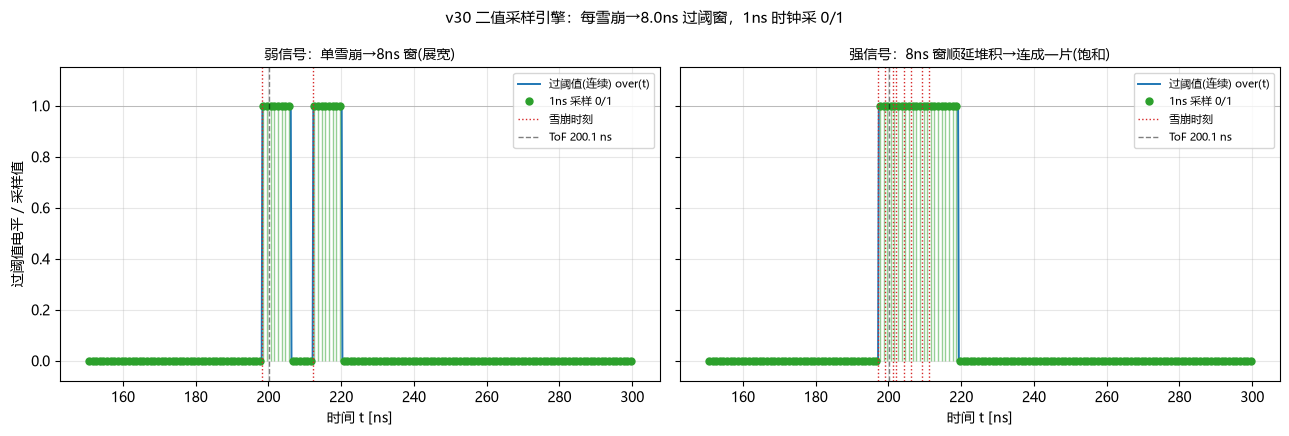

v30 二值采样引擎已就绪：
  · 过阈窗宽 T_OVER = 8.00 ns（由 τ_RC 与 Vth 导出，非独立参数）
  · 弱信号：2 次分立雪崩 → 采到 16 个 '1' bin（每雪崩摊成~8ns 宽）
  · 强信号：8 次密集雪崩 → 采到 22 个 '1' bin（窗堆积、趋于连续=饱和前兆）
  · 单 SPAD 每 bin 每 shot 至多 1 ⇒ 宏像元(27 SPAD)×N_shots 后峰 bin 硬上限 = 108
  · [v31] spad_binary_trace(..., return_attrib=True) 可返回 (out, out_sig, out_amb) 归因每个 1 的来源
  · [v32] 归因改为'先数信号/环境光子数, 再按比例等概率抽签'——信号不再优先, 信号/环境对称公平


In [13]:
# ---- v30 二值采样引擎：定义 + 过阈窗宽 + timing 三参数 + 单 SPAD 波形演示 ----
# ---- v31 增补：spad_binary_trace 加 return_attrib，可把每个"1"归因到 信号/环境 触发 ----
# ---- v32 修改：归因由"信号优先"改为【按比例等概率抽签】(见 return_attrib 路径注释) ----

# (1) 过阈值窗宽 T_OVER：由 RC 恢复与阈值推出，≈8ns（不新增独立参数）
#     雪崩后 Vov 从 0 按 τ_RC 指数充回，充到 Vth_frac 之前一直判"过阈=1"。
T_OVER = -TAU_RC * np.log(1.0 - VTH_FRAC)     # = -8.7315e-9 * ln(0.4) ≈ 8.0e-9 s
print(f"过阈值窗宽 T_OVER = -τ_RC·ln(1-Vth_frac) = {T_OVER*1e9:.3f} ns  "
      f"(τ_RC={TAU_RC*1e9:.4f}ns, Vth_frac={VTH_FRAC:.0%})")

# (2) timing 三参数：统一把"激光实际发光时刻"相对 start 向后延迟。
#     采样格(1ns 时钟)固定不动，靠 t_laser 让回波相对采样格平移 → 亚 ns 测距。
#     默认全 0 => t_laser=0 => 回波峰位与 v21 一致（仅统计方式变二值）。
#     注：此处仅【新增】timing 键，不改动 PARAMS 中任何既有物理参数值。
PARAMS.setdefault("timing", {
    "tx_trig_dly":   0,      # 单位 1ns（整数 ns 粗延迟之一）
    "tx_trig_tcode": 0,      # 单位 1ns（整数 ns 粗延迟之二）
    "delta_dly":     0,      # 单位 1/12 ns（≈83.3ps 精延迟游标；扫 0..11 测距）
})

def laser_delay(timing):
    """由 timing 三参数算激光相对 start 的向后延迟 t_laser [s]。"""
    return ((timing["tx_trig_dly"] + timing["tx_trig_tcode"]) * 1e-9
            + timing["delta_dly"] * (1e-9 / 12.0))

T_LASER = laser_delay(PARAMS["timing"])
print(f"激光延迟 t_laser = (tx_trig_dly+tx_trig_tcode)·1ns + delta_dly·(1/12)ns = {T_LASER*1e9:.4f} ns "
      f"(默认三参数={PARAMS['timing']})")


def spad_binary_trace(r_sig_fine, r_amb_ph, tf, centers, PDE_max, tau_rc, Vth_frac,
                      jitter_sigma, rng, t_over, t_laser=0.0,
                      resp_shape="linear", resp_k=3.0, return_attrib=False):
    """v30 单 SPAD、单次 shot 的【二值采样】。

    返回长度 = len(centers) 的 int8 数组：每个 1ns 采样点的 0/1（是否过阈值）。

    机制（与 v21 RC 引擎共用"雪崩触发"物理，但输出方式不同）：
      1) 光子按 Poisson(r·dt) 到达细网格 tf（信号 r_sig_fine + 背景 r_amb_ph）；
      2) 每个光子按 触发概率 = PDE_max·g(vov_frac) 判定是否引发雪崩；
         vov_frac 按 RC 恢复 1-exp(-(t-last)/τ) 计算（同 v21，恢复期灵敏度渐增）；
      3) 每次雪崩把输出在 [t_av, t_av + t_over] 内拉高为 1（可顺延/堆积）；
      4) 采样点 = centers + t_laser（激光延迟把回波相对采样格整体后移）；
         采样点落入任一拉高区间 → 该 bin 记 1。（v21 是把 timestamp 塞进 histogram）

    【护带用法】：把 tf 向左扩 ≥t_over（并给对应的 r_sig_fine，环境率标量不变），采样点
      centers 仍留在分析窗内，即可消除"前沿 bin 缺上游雪崩"的边界效应（见模块 11/13）。

    【v31 归因 return_attrib】：
      · False（默认）：返回单个 out（与 v30 逐行一致，下游 12b/15/16 不受影响）；
      · True：分别按 Poisson 生成 signal / ambient 光子（Poisson 可加性 ⇒ 与合并生成
        统计等价），记录每次雪崩由哪种光子触发，返回 (out, out_sig, out_amb)：
          out     = 该 bin 是否过阈(0/1)               = out_sig | out_amb
          out_sig = 该 bin 归"信号触发"点亮
          out_amb = 该 bin 归"环境触发"点亮 (out_sig 与 out_amb 逐 bin 互斥, 和=out)

    【v32 公平归因（本版修改，不再"信号优先"）】：
      · 触发级：每次雪崩不再让信号光子优先占用。做法是记录该雪崩所在细网格块里
        当时有多少信号光子 n_sig、多少环境光子 n_amb，然后【按比例 n_sig/(n_sig+n_amb)
        等概率抽签】决定这次雪崩算"信号触发"还是"环境触发"（rng 抽一个均匀数比较）。
      · bin 级：一个 bin 若被多次雪崩窗覆盖（信号窗 c_sig 个、环境窗 c_amb 个），
        也【按覆盖数比例 c_sig/(c_sig+c_amb) 等概率抽签】决定这个"1"归信号还是环境，
        不再强制归信号。两级都用"先数数量、再按比例抽签"，对信号/环境完全对称公平。
      · 总计数 out（=是否过阈）与归因抽签无关，逐 bin 定义与 v31 一致；仅"绿/橙"分配变公平。
    """
    dt = tf[1] - tf[0]
    nbn = len(centers)
    out = np.zeros(nbn, dtype=np.int8)
    inv_tau = 1.0 / tau_rc

    if not return_attrib:
        # ===== 默认路径：与 v30 完全一致（合并生成，单一随机序列）=====
        mu = (r_sig_fine + r_amb_ph) * dt
        n_ph = rng.poisson(mu)                      # 各细网格点到达光子数 ~ Poisson
        if n_ph.sum() == 0:
            return out
        t_arr = np.repeat(tf, n_ph)                 # 展开成逐光子到达时刻
        u = rng.random(t_arr.size)
        # --- 逐光子判定雪崩（Vov 按 RC 恢复；触发即把 Vov 拉回 0 重新恢复）---
        last = -1e30
        av = []                                     # 记录雪崩发生时刻
        for k in range(t_arr.size):
            t = t_arr[k]
            d = (t - last) * inv_tau
            vov_frac = 1.0 - np.exp(-d) if d < 700 else 1.0
            p_fire = PDE_max * spad_response_g(vov_frac, resp_shape, resp_k)
            if u[k] < p_fire:
                av.append(t)
                last = t
        if not av:
            return out
        av = np.asarray(av)
        if jitter_sigma > 0:                        # IRF 抖动作用在雪崩(→过阈窗)时刻
            av = av + rng.normal(0.0, jitter_sigma, av.size)
        # --- 二值采样：采样点固定钉在 start 起整 ns(centers 不动)；
        #     激光延迟 t_laser 把回波(雪崩→8ns 过阈窗)【整体向后移】：
        #     窗口 = [t_av + t_laser, t_av + t_laser + t_over]，采样点落入即置 1。
        for tt in av:
            lo = tt + t_laser
            out[(centers >= lo) & (centers < lo + t_over)] = 1
        return out

    # ===== v31/v32 归因路径：分离生成 signal / ambient 光子，公平归因每次雪崩来源 =====
    out_sig = np.zeros(nbn, dtype=np.int8)
    out_amb = np.zeros(nbn, dtype=np.int8)
    n_sig = rng.poisson(r_sig_fine * dt)                       # 信号光子数(逐网格点)
    n_amb = rng.poisson(np.full(len(tf), r_amb_ph) * dt)      # 环境光子数(逐网格点, 率为标量)
    n_ph = n_sig + n_amb
    if n_ph.sum() == 0:
        return out, out_sig, out_amb
    t_arr = np.repeat(tf, n_ph)                                # 逐光子到达时刻(升序)
    block_id = np.repeat(np.arange(len(tf)), n_ph)            # 每个光子所属的细网格块下标
    u = rng.random(t_arr.size)
    # --- 逐光子判雪崩：这里【不区分来源】, 只找出"雪崩发生在哪个时刻/哪个网格块" ---
    #     (来源在雪崩定下来之后再按比例抽签, 保证 av 与 v31 同一物理, 且信号/环境对称)
    last = -1e30
    av = []                                                    # 雪崩时刻
    av_blk = []                                                # 每次雪崩所在网格块下标
    for k in range(t_arr.size):
        t = t_arr[k]
        d = (t - last) * inv_tau
        vov_frac = 1.0 - np.exp(-d) if d < 700 else 1.0
        p_fire = PDE_max * spad_response_g(vov_frac, resp_shape, resp_k)
        if u[k] < p_fire:
            av.append(t)
            av_blk.append(block_id[k])
            last = t
    if not av:
        return out, out_sig, out_amb
    av = np.asarray(av)
    av_blk = np.asarray(av_blk)
    if jitter_sigma > 0:
        av = av + rng.normal(0.0, jitter_sigma, av.size)
    # --- 【v32 触发级公平抽签】每次雪崩按其网格块 n_sig:n_amb 比例, 等概率定来源 ---
    #     p = n_sig/(n_sig+n_amb) 是该时刻"到达的光子里信号占比"; 抽 u<p 则记信号触发。
    p_sig_av = n_sig[av_blk] / n_ph[av_blk]                    # 逐雪崩的信号占比(0~1)
    av_is_sig = rng.random(av.size) < p_sig_av                 # True=信号触发, False=环境触发
    # --- 分别统计每个 bin 被"信号雪崩窗 / 环境雪崩窗"覆盖了几次 ---
    cov_sig = np.zeros(nbn, dtype=np.int32)
    cov_amb = np.zeros(nbn, dtype=np.int32)
    for tt, is_sig in zip(av, av_is_sig):
        lo = tt + t_laser
        mask = (centers >= lo) & (centers < lo + t_over)
        if is_sig:
            cov_sig[mask] += 1
        else:
            cov_amb[mask] += 1
    cov_tot = cov_sig + cov_amb
    lit = cov_tot > 0
    out[lit] = 1                                               # 总过阈(与 v31 逐 bin 定义一致)
    # --- 【v32 bin 级公平抽签】被多个窗覆盖的 bin, 按 c_sig:c_amb 比例等概率归因 ---
    p_bin = np.divide(cov_sig, cov_tot, out=np.zeros(nbn), where=lit)  # 该 bin 归信号的概率
    coin = rng.random(nbn)
    sig_bin = lit & (coin < p_bin)                             # 抽中信号
    amb_bin = lit & ~sig_bin                                   # 其余归环境(互斥)
    out_sig[sig_bin] = 1
    out_amb[amb_bin] = 1
    return out, out_sig, out_amb


def over_waveform(av_times, t_grid, t_over):
    """辅助(仅演示用)：在细网格 t_grid 上，把每次雪崩的 [t_av, t_av+t_over] 置 1，
    得到连续的"过阈值方波"，用于画 8ns 窗的堆积效果。"""
    w = np.zeros_like(t_grid)
    for tt in np.atleast_1d(av_times):
        w[(t_grid >= tt) & (t_grid < tt + t_over)] = 1.0
    return w


# ---- 单 SPAD 二值波形演示：弱信号(展宽) vs 强信号(饱和) ----
# 说明：这里为可视化对比，人为设置"弱/强"两档信号率(强档= r_sig 放大若干倍)，
#       仅用于演示二值机制，不改动 PARAMS 中的物理场景参数。
rng_demo = np.random.default_rng(PARAMS["hist"]["seed"] + 96)
tgrid = np.arange(t_lo, t_hi, dt_fine)                 # 细网格(画连续方波用)
tgrid_ns = tgrid * 1e9

# 直接指定几处"雪崩时刻"以清晰展示 8ns 窗（弱：分立；强：密集堆积）
av_weak   = np.array([t0_ns - 2.0, t0_ns + 12.0]) * 1e-9          # 两次分立雪崩
av_strong = (t0_ns + np.array([-3, -1, 1, 2, 4, 6, 9, 11.0])) * 1e-9  # 密集雪崩

w_weak   = over_waveform(av_weak,   tgrid, T_OVER)
w_strong = over_waveform(av_strong, tgrid, T_OVER)

# 1ns 采样点上的 0/1（用 centers 作采样时刻）
def sample_binary(av_times, centers, t_over, t_laser=0.0):
    # 采样点固定(centers)，激光延迟把回波窗 [av+t_laser, av+t_laser+t_over] 右移
    b = np.zeros(len(centers), dtype=int)
    for tt in np.atleast_1d(av_times):
        lo = tt + t_laser
        b[(centers >= lo) & (centers < lo + t_over)] = 1
    return b

b_weak   = sample_binary(av_weak,   centers, T_OVER)
b_strong = sample_binary(av_strong, centers, T_OVER)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4), sharey=True)
for a, (w, b, av, ttl) in zip(
        ax,
        [(w_weak,   b_weak,   av_weak,   "弱信号：单雪崩→8ns 窗(展宽)"),
         (w_strong, b_strong, av_strong, "强信号：8ns 窗顺延堆积→连成一片(饱和)")]):
    a.plot(tgrid_ns, w, color="tab:blue", lw=1.4, label="过阈值(连续) over(t)")
    a.axhline(1.0, color="0.7", ls="-", lw=0.6)
    # 1ns 采样点 0/1
    a.plot(tc_ns, b, "o", color="tab:green", ms=5, label="1ns 采样 0/1")
    a.vlines(tc_ns, 0, b, color="tab:green", lw=1.0, alpha=0.5)
    # 雪崩时刻标记
    for j, tt in enumerate(av * 1e9):
        a.axvline(tt, color="tab:red", ls=":", lw=1.0,
                  label="雪崩时刻" if j == 0 else None)
    a.axvline(t0_ns, color="k", ls="--", alpha=0.5, lw=1.0, label=f"ToF {t0_ns:.1f} ns")
    a.set_xlabel("时间 t [ns]"); a.set_title(ttl, fontsize=10)
    a.set_ylim(-0.08, 1.15); a.grid(alpha=0.3); a.legend(fontsize=8, loc="upper right")
ax[0].set_ylabel("过阈值电平 / 采样值")
plt.suptitle(f"v30 二值采样引擎：每雪崩→{T_OVER*1e9:.1f}ns 过阈窗，1ns 时钟采 0/1", fontsize=11)
plt.tight_layout(); plt.show()

print("="*76)
print("v30 二值采样引擎已就绪：")
print(f"  · 过阈窗宽 T_OVER = {T_OVER*1e9:.2f} ns（由 τ_RC 与 Vth 导出，非独立参数）")
print(f"  · 弱信号：{av_weak.size} 次分立雪崩 → 采到 {int(b_weak.sum())} 个 '1' bin（每雪崩摊成~8ns 宽）")
print(f"  · 强信号：{av_strong.size} 次密集雪崩 → 采到 {int(b_strong.sum())} 个 '1' bin（窗堆积、趋于连续=饱和前兆）")
print(f"  · 单 SPAD 每 bin 每 shot 至多 1 ⇒ 宏像元(27 SPAD)×N_shots 后峰 bin 硬上限 = {27*PARAMS['hist']['N_shots']}")
print(f"  · [v31] spad_binary_trace(..., return_attrib=True) 可返回 (out, out_sig, out_amb) 归因每个 1 的来源")
print(f"  · [v32] 归因改为'先数信号/环境光子数, 再按比例等概率抽签'——信号不再优先, 信号/环境对称公平")

## 模块 9c（v31 核心新增）— 单个 SPAD 的二值时域波形：Vov(t) → 1ns HDC 采样 → 比 60% 阈值 → 0/1

模块 8b 画的是**计数模型**下的 Vov(t)（计数才复位）。本模块画**二值模型**下、**同一个 SPAD 经历一整串光子事件**时的完整时域链路，用**折线图**（不是直方图）逐层展示：

```
  ①  Vov(t)/Vov_max     雪崩即跌到 0，按 τ_RC 指数充回 1−e^(−Δt/τ)   ——蓝折线
       │  每个入射光子按 P=PDE·g(Vov) 判触发；触发→雪崩(红↑)、Vov 归 0
  ②  ─ ─ 60% 阈值线 ─ ─  Vov 高于此线即"过阈"                        ——红虚线
  ③  过阈方波 over(t)    每次雪崩把 [t_av, t_av+8ns] 拉成高电平 1     ——橙阶梯
       │  多次雪崩间隔 <8ns 时，窗顺延堆积、连成一片
  ④  ●  1ns HDC 采样     每整 ns 采一点：落在过阈方波内→1，否则→0    ——绿点/茎
```

**关键点（回答"二值到底在采什么"）：**
- HDC（Hardware Data Channel，硬件数据通道）**只在每个整 ns 看一眼**输出电平是否过阈，得到一串 0/1，**不记录光子的精确到达时刻**（这正是二值 vs v21 timestamp 的区别）；
- 一次雪崩 → 一个 **8ns 宽**的过阈方波 → 覆盖约 **8 个连续的 1ns 采样点**（都记 1）——这就是"展宽"；
- 若光子密集、雪崩间隔 < 8ns，方波顺延堆积、连成更长的高电平 → 采样点连片记 1 → 趋于"饱和"；
- 本图 Vov(t) 用**雪崩时刻**重建（未加 IRF 抖动，便于对齐观察）；抖动只在把过阈窗右移时体现。

> 本模块只为可视化单 SPAD 的二值机制，用**较强的信号率**让一次 shot 里发生多次雪崩（便于观察堆积）；不改动 PARAMS 任何物理参数。

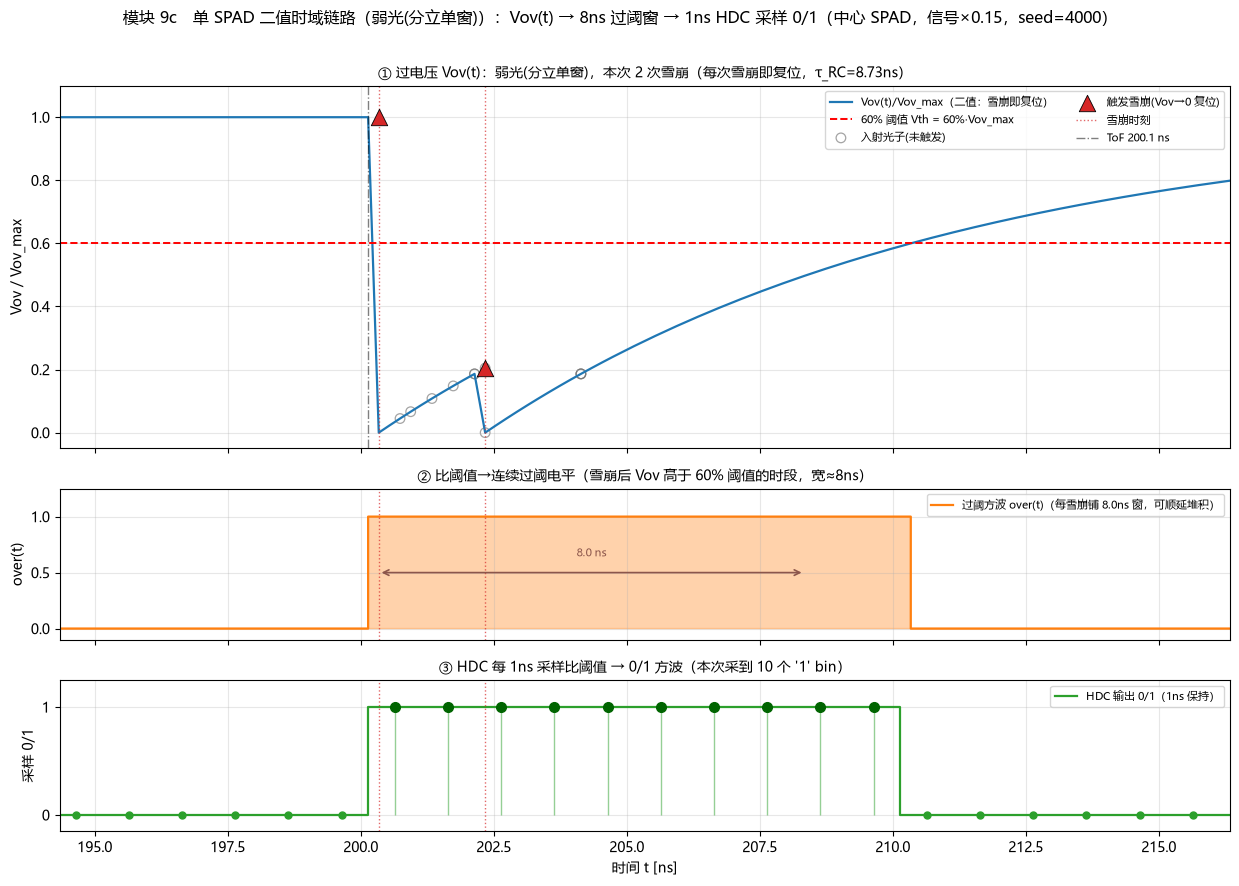

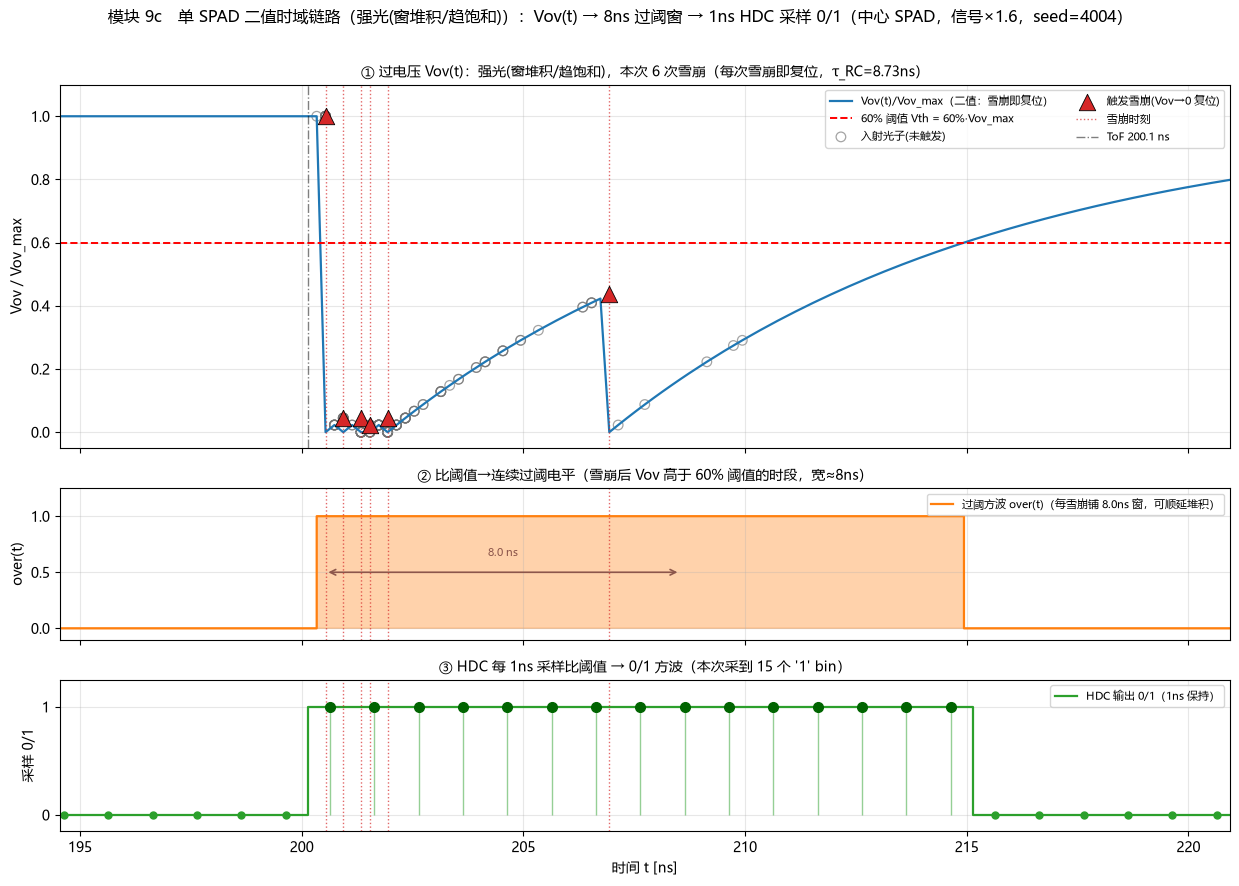

模块 9c 单 SPAD 二值时域波形（折线图，弱光 + 强光两组）：
  弱光: 信号×0.15, 2 次雪崩 @ [200.34, 202.34] ns, 采到 10 个 '1'
  强光: 信号×1.6, 6 次雪崩 @ [200.54, 200.94, 201.34, 201.54, 201.94, 206.94] ns, 采到 15 个 '1'
  每次雪崩 → Vov 归 0 按 τ_RC=8.73ns 充回；铺 8.00ns 过阈窗；间隔<8ns 时窗堆积
  弱光=分立单窗(采样点稀疏记 1)；强光=窗顺延堆积(采样点连片记 1、趋饱和)
  关键区别：本模块是【二值模型】(雪崩即复位)；模块 8b 是【计数模型】(仅过阈计数事件才复位)


In [14]:
# ============================================================================
# 模块 9c（v31 新增）：单个 SPAD 的【二值】时域波形折线图（弱光 + 强光 两组）
#   展示同一个 SPAD 经历一串光子事件时：
#     ① Vov(t) 怎么变化（雪崩即复位，按 τ_RC 充回）——蓝折线
#     ② 比 60% 阈值 → 连续过阈方波（8ns 窗，可堆积）——橙阶梯
#     ③ HDC 每 1ns 采样 → 输出 0/1 方波——绿阶梯/绿点
#   本模块画【弱光】(分立单窗) 与【强光】(窗堆积/趋饱和) 两组对照。
#   注意：这是【二值模型】(每次雪崩都复位 Vov 并铺 8ns 过阈窗)，
#         与模块 8b 的【计数模型】(只有过阈计数事件才复位)不同——见函数注释。
#   全部用折线/阶梯/散点，不画直方图。不改动 PARAMS 任何物理参数。
# ============================================================================

def binary_trace_with_curve(r_sig_fine, r_amb_ph, tf, centers, PDE_max, tau_rc,
                            Vth_frac, rng, t_over, resp_shape="linear", resp_k=3.0):
    """就地重演【二值引擎 spad_binary_trace 的核心物理】，但额外记录可视化轨迹。
    与 spad_binary_trace 的判雪崩/复位逻辑逐行一致：
      · 每个光子按 触发概率 = PDE_max·g(vov_frac) 判是否雪崩；
      · vov_frac = 1 - exp(-(t - last)/τ)，last=上次【雪崩】时刻（二值：雪崩即复位，
        无论是否过阈，都把 Vov 拉回 0 重新 RC 充电——这正是与 8b 计数模型的区别）；
      · 每次雪崩把输出在 [t_av, t_av+t_over] 拉高为 1。
    返回 dict：t_photon/fired/vov_at_photon（光子级）、av（雪崩时刻）、
               tg/vov_grid（连续 Vov 曲线，二值复位重建）、
               over_grid（细网格过阈方波 0/1）、samp01（centers 上的 1ns 采样 0/1）。
    此处不加 IRF 抖动，令 Vov 曲线与过阈窗、采样点在时间轴上精确对齐，便于观察。
    """
    dt = tf[1] - tf[0]
    inv_tau = 1.0 / tau_rc
    mu = (r_sig_fine + r_amb_ph) * dt
    n_ph = rng.poisson(mu)
    t_arr = np.repeat(tf, n_ph) if n_ph.sum() else np.empty(0)
    u = rng.random(t_arr.size)
    fired = np.zeros(t_arr.size, dtype=bool)
    vov_at = np.zeros(t_arr.size)
    av = []                                     # 雪崩时刻（二值：每次雪崩都复位）
    last = -1e30
    for k in range(t_arr.size):
        t = t_arr[k]
        d = (t - last) * inv_tau
        vf = 1.0 - np.exp(-d) if d < 700 else 1.0
        vov_at[k] = vf
        if u[k] < PDE_max * spad_response_g(vf, resp_shape, resp_k):
            fired[k] = True
            last = t                            # 二值：雪崩即复位（不判阈值）
            av.append(t)
    av = np.asarray(av)
    # 连续 Vov(t)：在细网格按"距上次雪崩"重建（每次雪崩把 Vov 拉 0 重新充）
    tg = tf.copy()
    vg = np.ones(tg.size)
    last = -1e30; ai = 0
    for idx in range(tg.size):
        t = tg[idx]
        while ai < av.size and av[ai] <= t:
            last = av[ai]; ai += 1
        d = (t - last) * inv_tau
        vg[idx] = 1.0 - np.exp(-d) if d < 700 else 1.0
    # 过阈方波：每次雪崩铺 [t_av, t_av+t_over]=1（细网格上，可堆积顺延）
    over_grid = np.zeros(tg.size)
    for tt in av:
        over_grid[(tg >= tt) & (tg < tt + t_over)] = 1.0
    # 1ns HDC 采样：采样点=centers，落入任一过阈窗→1
    samp01 = np.zeros(len(centers), dtype=int)
    for tt in av:
        samp01[(centers >= tt) & (centers < tt + t_over)] = 1
    return {"t_photon": t_arr, "fired": fired, "vov_at_photon": vov_at, "av": av,
            "tg": tg, "vov_grid": vg, "over_grid": over_grid, "samp01": samp01}


def draw_9c(tr, boost, seed_used, light_tag, n_av):
    """画单组（弱光或强光）的 3 行子图：① Vov(t) ② 过阈方波 ③ 1ns 采样 0/1。"""
    tph_ns = tr["t_photon"] * 1e9
    fired9 = tr["fired"]; vov_ph = tr["vov_at_photon"]
    av_ns  = tr["av"] * 1e9
    tg_ns9 = tr["tg"] * 1e9; vg9 = tr["vov_grid"]
    over9  = tr["over_grid"]; samp9 = tr["samp01"]
    # 画图范围：聚焦雪崩活动区
    if n_av > 0:
        x0 = max(t_lo*1e9, av_ns.min() - 6.0)
        x1 = min(t_hi*1e9, av_ns.max() + T_OVER*1e9 + 6.0)
    else:
        x0, x1 = t0_ns - 10.0, t0_ns + 20.0

    fig, ax = plt.subplots(3, 1, figsize=(12.5, 9.0), sharex=True,
                           gridspec_kw={"height_ratios": [2.4, 1.0, 1.0]})
    # ① Vov(t)
    a0 = ax[0]
    a0.plot(tg_ns9, vg9, color="tab:blue", lw=1.6, label="Vov(t)/Vov_max（二值：雪崩即复位）")
    a0.axhline(VTH_FRAC, color="red", ls="--", lw=1.4, label=f"60% 阈值 Vth = {VTH_FRAC:.0%}·Vov_max")
    m_f = fired9; m_n = ~fired9
    # 未触发光子：放大为空心灰圈（原来 s=16 太小，改 s=48 空心）
    a0.scatter(tph_ns[m_n], vov_ph[m_n], s=48, facecolors="none", edgecolors="0.45",
               linewidths=0.9, alpha=0.65, marker="o", label="入射光子(未触发)")
    # 触发雪崩：实心红三角，放大
    a0.scatter(tph_ns[m_f], vov_ph[m_f], s=140, c="tab:red", marker="^",
               edgecolor="k", linewidth=0.6, zorder=6, label="触发雪崩(Vov→0 复位)")
    for j, tt in enumerate(av_ns):
        a0.axvline(tt, color="tab:red", ls=":", lw=1.0, alpha=0.7,
                   label="雪崩时刻" if j == 0 else None)
    a0.axvline(t0_ns, color="k", ls="-.", alpha=0.5, lw=1.0, label=f"ToF {t0_ns:.1f} ns")
    a0.set_ylim(-0.05, 1.10); a0.set_ylabel("Vov / Vov_max")
    a0.set_title(f"① 过电压 Vov(t)：{light_tag}，本次 {n_av} 次雪崩（每次雪崩即复位，τ_RC={TAU_RC*1e9:.2f}ns）",
                 fontsize=10)
    a0.legend(fontsize=8, loc="upper right", ncol=2); a0.grid(alpha=0.3)
    # ② 过阈方波
    a1 = ax[1]
    a1.fill_between(tg_ns9, 0, over9, step="pre", color="tab:orange", alpha=0.35)
    a1.plot(tg_ns9, over9, drawstyle="steps-pre", color="tab:orange", lw=1.6,
            label=f"过阈方波 over(t)（每雪崩铺 {T_OVER*1e9:.1f}ns 窗，可顺延堆积）")
    for tt in av_ns:
        a1.axvline(tt, color="tab:red", ls=":", lw=1.0, alpha=0.7)
    if n_av > 0:
        a1.annotate("", xy=(av_ns[0]+T_OVER*1e9, 0.5), xytext=(av_ns[0], 0.5),
                    arrowprops=dict(arrowstyle="<->", color="tab:brown", lw=1.2))
        a1.text(av_ns[0]+T_OVER*1e9/2, 0.62, f"{T_OVER*1e9:.1f} ns",
                ha="center", va="bottom", fontsize=8, color="tab:brown")
    a1.set_ylim(-0.1, 1.25); a1.set_ylabel("over(t)")
    a1.set_title("② 比阈值→连续过阈电平（雪崩后 Vov 高于 60% 阈值的时段，宽≈8ns）", fontsize=10)
    a1.legend(fontsize=8, loc="upper right"); a1.grid(alpha=0.3)
    # ③ 1ns HDC 采样 0/1
    a2 = ax[2]
    a2.plot(tc_ns, samp9, drawstyle="steps-mid", color="tab:green", lw=1.6,
            label="HDC 输出 0/1（1ns 保持）")
    a2.vlines(tc_ns, 0, samp9, color="tab:green", lw=1.0, alpha=0.5)
    a2.plot(tc_ns, samp9, "o", color="tab:green", ms=5)
    one_idx = samp9 == 1
    a2.plot(tc_ns[one_idx], samp9[one_idx], "o", color="darkgreen", ms=7, zorder=6)
    for tt in av_ns:
        a2.axvline(tt, color="tab:red", ls=":", lw=1.0, alpha=0.7)
    a2.set_ylim(-0.15, 1.25); a2.set_yticks([0, 1])
    a2.set_ylabel("采样 0/1"); a2.set_xlabel("时间 t [ns]")
    a2.set_title(f"③ HDC 每 1ns 采样比阈值 → 0/1 方波（本次采到 {int(samp9.sum())} 个 '1' bin）",
                 fontsize=10)
    a2.legend(fontsize=8, loc="upper right"); a2.grid(alpha=0.3)
    for a in ax:
        a.set_xlim(x0, x1)
    plt.suptitle(f"模块 9c　单 SPAD 二值时域链路（{light_tag}）：Vov(t) → 8ns 过阈窗 → 1ns HDC 采样 0/1"
                 f"（中心 SPAD，信号×{boost:g}，seed={4000+seed_used}）", fontsize=11.5)
    plt.tight_layout(rect=[0, 0, 1, 0.97]); plt.show()


# ---- 选【弱光】：目标雪崩数 1~2，看清分立的单个 8ns 窗（不堆积）----
best_weak = None
for boost in (0.15, 0.25, 0.4, 0.6, 0.8):
    r_sig_demo = r_sig * boost
    for s in range(80):
        rng_9c = np.random.default_rng(4000 + s)
        tr = binary_trace_with_curve(r_sig_demo, r_amb_ph, tf, centers, PDE, TAU_RC,
                                     VTH_FRAC, rng_9c, T_OVER, RESP_SHAPE, RESP_K)
        nav = int(tr["av"].size)
        score = abs(nav - 2) + (0 if 1 <= nav <= 2 else 100)   # 优先恰好 2 次分立雪崩
        if best_weak is None or score < best_weak[0]:
            best_weak = (score, boost, s, nav, tr)

# ---- 选【强光】：目标雪崩数 5~7，看 8ns 窗顺延堆积、趋于饱和 ----
best_strong = None
for boost in (1.6, 2.4, 3.2, 4.0):
    r_sig_demo = r_sig * boost
    for s in range(80):
        rng_9c = np.random.default_rng(4000 + s)
        tr = binary_trace_with_curve(r_sig_demo, r_amb_ph, tf, centers, PDE, TAU_RC,
                                     VTH_FRAC, rng_9c, T_OVER, RESP_SHAPE, RESP_K)
        nav = int(tr["av"].size)
        score = abs(nav - 6) + (0 if 5 <= nav <= 8 else 100)
        if best_strong is None or score < best_strong[0]:
            best_strong = (score, boost, s, nav, tr)

_, bw, sw, nw, trw = best_weak
_, bs, ss, ns_, trs = best_strong

# 先画弱光，再画强光（两张独立图，各 3 行子图）
draw_9c(trw, bw, sw, "弱光(分立单窗)", nw)
draw_9c(trs, bs, ss, "强光(窗堆积/趋饱和)", ns_)

print("="*76)
print("模块 9c 单 SPAD 二值时域波形（折线图，弱光 + 强光两组）：")
print(f"  弱光: 信号×{bw:g}, {nw} 次雪崩 @ {np.round(trw['av']*1e9,2).tolist()} ns, 采到 {int(trw['samp01'].sum())} 个 '1'")
print(f"  强光: 信号×{bs:g}, {ns_} 次雪崩 @ {np.round(trs['av']*1e9,2).tolist()} ns, 采到 {int(trs['samp01'].sum())} 个 '1'")
print(f"  每次雪崩 → Vov 归 0 按 τ_RC={TAU_RC*1e9:.2f}ns 充回；铺 {T_OVER*1e9:.2f}ns 过阈窗；间隔<8ns 时窗堆积")
print(f"  弱光=分立单窗(采样点稀疏记 1)；强光=窗顺延堆积(采样点连片记 1、趋饱和)")
print(f"  关键区别：本模块是【二值模型】(雪崩即复位)；模块 8b 是【计数模型】(仅过阈计数事件才复位)")

## 模块 10（沿用 v12）— Macro Pixel（宏像元）定义 9×3（仅文字说明与数值）

**定义**: 短边 x 的 9 个 SPAD 全取, 长边 y 每 3 个为一组。
阵列 `9×120` ⇒ 沿长边共 `120/3 = 40` 个宏像元, 每个 `9×3 = 27` 个 SPAD。
宏像元 `m` 覆盖全部 x、y 索引 `[3m, 3m+3)`。像斑长边 σ≈200µm ⇒ 中间宏像元信号多、两端仅底噪。

In [15]:
Bx_m, By_m = 9, 3
a = PARAMS["spad_array"]
assert a["Nx"] == Bx_m and a["Ny"] % By_m == 0
n_macro = a["Ny"] // By_m
n_pix_macro = Bx_m * By_m
macro_fsum = np.array([fpix0[:, m*By_m:(m+1)*By_m].sum() for m in range(n_macro)])
m_peak = int(macro_fsum.argmax())
print(f"宏像元 = {Bx_m}×{By_m}; 共 {n_macro} 个, 每个 {n_pix_macro} SPAD; 峰值宏像元 m_peak={m_peak} (Σf={macro_fsum[m_peak]:.3f})")
print(f"全部 Σf_pix={macro_fsum.sum():.3f}; 边缘 m=0 的 Σf={macro_fsum[0]:.3e} (近乎纯底噪)")

宏像元 = 9×3; 共 40 个, 每个 27 SPAD; 峰值宏像元 m_peak=20 (Σf=0.060)
全部 Σf_pix=0.997; 边缘 m=0 的 Σf=8.258e-04 (近乎纯底噪)


## 模块 11（v13 更新）— 逐-SPAD 蒙卡统计每个宏像元直方图（RC 恢复模型）

每个宏像元 27 个 SPAD 各自独立跑 **RC 引擎**(每 SPAD 各自 Vov 恢复), 合并事件后 1ns 直方图, 累加 N_shots。
同时给出 v12 硬死时间(14ns)的全体总计数做对比, 展示 RC 模型对计数损失的修正。

In [16]:
nbins = len(centers)
base_rate = signal_photon_rate_fine(echo0, 1.0, tf)   # 单位收集比例(f=1)的信号率, 后续乘 f_ij
N_shots = PARAMS["hist"]["N_shots"]
macro_fvals = [fpix0[:, m*By_m:(m+1)*By_m].ravel() for m in range(n_macro)]

# 激光延迟(默认 0)：把回波相对 1ns 采样格整体后移 t_laser
T_LASER = laser_delay(PARAMS["timing"])

# ---- v31 背景护带 (guard band)：生成光子的网格向左扩 ≥ T_OVER, 消除前沿边界效应 ----
#   问题(模块13"最开始没噪声"的根因)：二值引擎每次雪崩把 [t_av, t_av+T_OVER] 置 1;
#     分析窗前沿 bin 本应收到来自 t_lo 左侧(<t_lo)的上游雪崩贡献, 但原 tf 从 t_lo 起
#     根本没生成这些上游光子 ⇒ 前 ~8ns bin 系统性偏低(边界假象, 背景尤其明显)。
#   修复：把【生成光子】的网格 tf_gen 向左扩 guard_band(≥T_OVER + 若干 jitter σ),
#         而【采样点】centers 保持不变(直方图长度 nbins 不变) ⇒ 前沿 bin 补齐上游贡献。
guard_band = T_OVER + 5*jit                            # 8ns 过阈窗 + 5σ 抖动余量, 完全覆盖上游
tf_gen = np.arange(t_lo - guard_band, t_hi, dt_fine)   # 左扩护带的生成网格
base_rate_gen = signal_photon_rate_fine(echo0, 1.0, tf_gen)   # 扩展网格上的单位信号率
print(f"[v31 护带] guard_band={guard_band*1e9:.2f} ns, 生成网格 tf_gen 左扩 "
      f"{len(tf_gen)-len(tf)} 个细点(采样点 centers 不变, nbins={nbins})")

# ---- v30 二值模型 + v31 来源归因 & per-shot 保存 ----
#   每个 SPAD 每 bin 每 shot ∈ {0,1}; 宏像元求和后 ∈ [0,27]; 再 ×N_shots 累加。
#   全程 return_attrib=True: 把每个"1"归因到 信号触发 / 环境触发 两分量;
#   逐 SPAD 单 shot 满足 out = out_sig + out_amb(逐 bin 互斥) ⇒ 累加后
#   macro_hist = macro_hist_sig + macro_hist_amb 严格成立(供双色堆叠图)。
rng = np.random.default_rng(PARAMS["hist"]["seed"] + 11)
macro_hist     = np.zeros((n_macro, nbins))            # 总(信号+背景) —— 下游契约变量
macro_hist_sig = np.zeros((n_macro, nbins))            # v31 信号光子触发分量
macro_hist_amb = np.zeros((n_macro, nbins))            # v31 环境光子触发分量
# per-shot 保存(仅峰值宏像元 m_peak, 供模块 11b 画每 shot 直方图; 存全 40×N_shots 太占内存)
per_shot_peak     = np.zeros((N_shots, nbins))         # 峰值宏像元 每 shot 总直方图(27 SPAD 和)
per_shot_peak_sig = np.zeros((N_shots, nbins))         #   ├ 信号分量
per_shot_peak_amb = np.zeros((N_shots, nbins))         #   └ 环境分量

for _shot in range(N_shots):
    for m in range(n_macro):
        acc     = np.zeros(nbins, dtype=np.int32)      # 本 shot 本宏像元 27-SPAD 求和(总)
        acc_sig = np.zeros(nbins, dtype=np.int32)      #   ├ 信号触发
        acc_amb = np.zeros(nbins, dtype=np.int32)      #   └ 环境触发
        for fij in macro_fvals[m]:
            o, o_sig, o_amb = spad_binary_trace(
                base_rate_gen*fij, r_amb_ph, tf_gen, centers, PDE, TAU_RC,
                VTH_FRAC, jit, rng, T_OVER, T_LASER, RESP_SHAPE, RESP_K,
                return_attrib=True)
            acc     += o
            acc_sig += o_sig
            acc_amb += o_amb
        macro_hist[m]     += acc
        macro_hist_sig[m] += acc_sig
        macro_hist_amb[m] += acc_amb
        if m == m_peak:                                # 记录峰值宏像元的 per-shot(供模块11b)
            per_shot_peak[_shot]     = acc
            per_shot_peak_sig[_shot] = acc_sig
            per_shot_peak_amb[_shot] = acc_amb

macro_cap = n_pix_macro * N_shots                       # 二值硬上限(峰 bin 触顶值) = 27×N_shots

# ---- 泊松期望计数(未二值封顶)作参考虚线: 若不受"每bin至多1"限制会有多少 ----
#   与 v21 相同的解析上限, 展示强信号处二值饱和相对泊松期望的"削顶"差异。
#   注: macro_lam 用原 tf(不用护带)——它是探测率卷积后 bincount 的解析期望, 前沿处
#       信号率≈0(信号峰在 t0=t_lo+10ns), IRF σ=100ps 极小, 边界影响可忽略, 故保留原样。
irf_k = gaussian_kernel(jit, dt_fine)
bin_idx = np.clip(((tf - t_lo)/bin_width).astype(int), 0, nbins-1)
macro_lam = np.zeros((n_macro, nbins))
for m in range(n_macro):
    r_det = (base_rate*macro_fsum[m] + n_pix_macro*r_amb_ph) * PDE
    r_det = np.convolve(r_det, irf_k, mode="same") * dt_fine
    macro_lam[m] = N_shots * np.bincount(bin_idx, weights=r_det*dt_fine, minlength=nbins)

tot_bin, tot_la = macro_hist.sum(), macro_lam.sum()
pk_peakbin = macro_hist[m_peak].max()
n_saturated = int((macro_hist[m_peak] >= macro_cap - 1e-9).sum())
# v31 归因统计: 峰值宏像元里 信号触发 / 环境触发 各占多少
pk_bin_tmp = int(macro_hist[m_peak].argmax())
sig_at_pk = macro_hist_sig[m_peak][pk_bin_tmp]
amb_at_pk = macro_hist_amb[m_peak][pk_bin_tmp]
print("="*76)
print(f"v30 二值采样 + v31 归因: {n_macro} 宏 × {n_pix_macro} SPAD × {N_shots} shots "
      f"(过阈窗 T_OVER={T_OVER*1e9:.1f}ns, Vth={VTH_FRAC*100:.0f}%)")
print(f"  峰 bin 二值硬上限 macro_cap = 27×N_shots = {macro_cap}")
print(f"  说明: 二值总计数(bin 级 0/1 之和)与'泊松光子期望'量纲不同, 不宜直接比'保留率';")
print(f"        单光子被摊成 {T_OVER*1e9:.0f}ns 宽的多个 '1' bin, 故二值总和可高于光子期望。")
print(f"  全体二值总计数 = {tot_bin:.0f}  (泊松光子期望参考 {tot_la:.0f}, 仅作虚线对照)")
print(f"峰值宏像元 m={m_peak}: 峰 bin={pk_peakbin:.0f}/{macro_cap} "
      f"({'已触顶饱和' if pk_peakbin>=macro_cap-1e-9 else '未触顶'}), "
      f"触顶 bin 数={n_saturated}, 总计数={macro_hist[m_peak].sum():.0f}; "
      f"边缘 m=0 总计数={macro_hist[0].sum():.0f}")
print(f"[v31 归因] 峰 bin @ {tc_ns[pk_bin_tmp]:.0f}ns: 信号触发={sig_at_pk:.0f}, 环境触发={amb_at_pk:.0f} "
      f"(信号占比 {100*sig_at_pk/max(sig_at_pk+amb_at_pk,1e-9):.1f}%); "
      f"全体: 信号={macro_hist_sig.sum():.0f}, 环境={macro_hist_amb.sum():.0f}")

[v31 护带] guard_band=8.50 ns, 生成网格 tf_gen 左扩 42 个细点(采样点 centers 不变, nbins=150)
v30 二值采样 + v31 归因: 40 宏 × 27 SPAD × 4 shots (过阈窗 T_OVER=8.0ns, Vth=60%)
  峰 bin 二值硬上限 macro_cap = 27×N_shots = 108
  说明: 二值总计数(bin 级 0/1 之和)与'泊松光子期望'量纲不同, 不宜直接比'保留率';
        单光子被摊成 8ns 宽的多个 '1' bin, 故二值总和可高于光子期望。
  全体二值总计数 = 49625  (泊松光子期望参考 14748, 仅作虚线对照)
峰值宏像元 m=20: 峰 bin=72/108 (未触顶), 触顶 bin 数=0, 总计数=1474; 边缘 m=0 总计数=826
[v31 归因] 峰 bin @ 205ns: 信号触发=71, 环境触发=1 (信号占比 98.6%); 全体: 信号=20946, 环境=28679


## 模块 11b（v31 核心新增）— 每个 shot 的直方图（折线）：看 N_shots 是怎么"逐发累加"成峰的

模块 11 最终用的是 **N_shots=4 发累加**后的直方图。本模块把**每一发 shot 单独画出来**（用**折线**，非柱状），回答"每一发到底长什么样、4 发怎么叠成峰"：

```
  单发 shot 直方图  ──┐
  (峰值宏像元 27 SPAD  │  每个 bin ∈ [0,27]   ← 单 shot 硬上限 = 27 SPAD
   在该发的 0/1 求和)  │
                      ├─→  4 发逐点相加  ─→  累加直方图 (bin ∈ [0,108])  ← 模块11/12 用的就是它
  shot#0 ~ shot#3 各  ─┘                        108 = 27×N_shots = macro_cap
```

**要点：**
- 每发之间只是**独立重采样**（同一物理场景、不同随机光子到达/雪崩）⇒ 峰位一致、峰高有涨落；
- 单发峰 bin 值受 **27（单 shot 27 SPAD 上限）** 封顶，4 发累加后受 **108** 封顶；
- 叠加**不会移动峰位**、也不改变饱和判据（见模块 12 图 B2）——只是把信号与噪声一起线性放大 √N 改善不了硬上限，故加 shot 对"是否饱和"无帮助；
- 每发再拆 **信号触发（绿）/ 环境触发（橙）** 两分量，可见信号集中在峰 bin、环境近似均匀铺底。

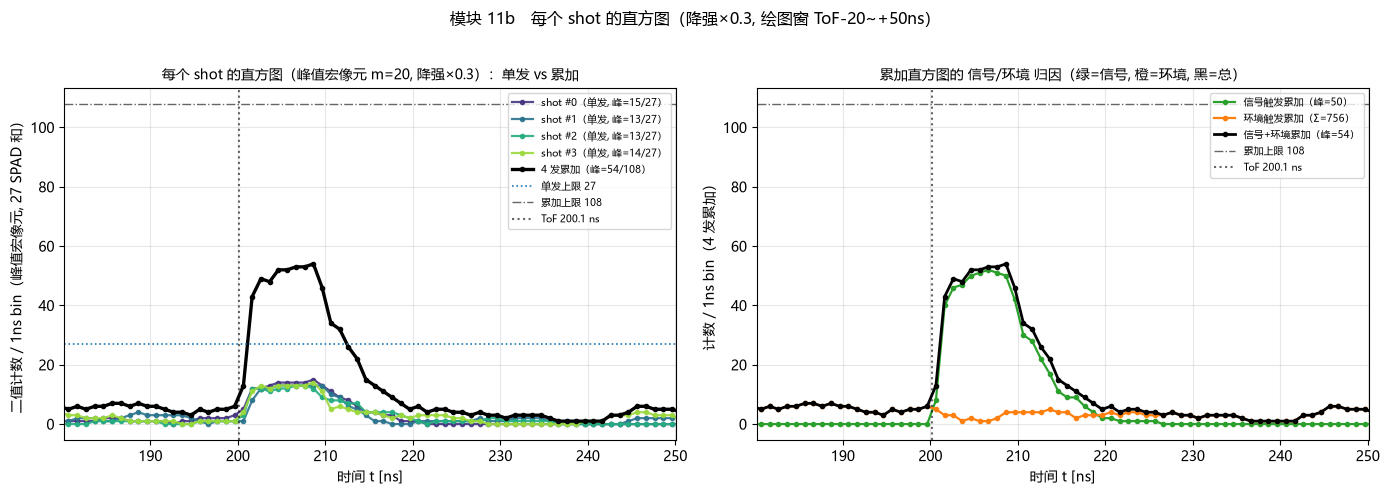

模块 11b（降强×0.3，独立重跑，不影响模块11/13/14）：峰值宏像元 m=20，4 发
  shot #0: 峰 bin=15/27 @ 209 ns, 总计数=330（信号=155, 环境=175）
  shot #1: 峰 bin=13/27 @ 205 ns, 总计数=348（信号=138, 环境=210）
  shot #2: 峰 bin=13/27 @ 207 ns, 总计数=273（信号=142, 环境=131）
  shot #3: 峰 bin=14/27 @ 209 ns, 总计数=387（信号=147, 环境=240）
  ---- 4 发累加：峰 bin=54/108 @ 209 ns, 总计数=1338 ----
  说明：降强系数 DEMO11B_SCALE=0.3 仅作用于本模块展示，不改动物理参数、不影响核心分析。


In [17]:
# ============================================================================
# 模块 11b（v31 折线图；v41 改：降光强 + 独立重跑 + 绘图窗）
#   用户反馈：11b 展示光强偏强(峰早早顶满 27/108)。v41 加【可调降强系数 DEMO11B_SCALE】，
#   把信号率 ×系数后【单独重跑】峰值宏像元 per-shot 数据(不动模块11 的 macro_hist，
#   核心分析 13/14 仍用原值)；绘图窗改用全局 plot_lo_ns/plot_hi_ns(ToF 前20/后50ns)。
# ============================================================================
DEMO11B_SCALE = 0.3        # 模块11b 展示用降强系数（可调；1.0=原强度，<1 变弱）

# ---- 独立重跑：峰值宏像元 27 SPAD × N_shots，信号率 ×DEMO11B_SCALE，带归因 ----
_rng11b = np.random.default_rng(PARAMS["hist"]["seed"] + 41100)
ps_demo = np.zeros((N_shots, nbins))       # 每发总直方图(27 SPAD 二值和)
ps_sig  = np.zeros((N_shots, nbins))       # 信号触发分量
ps_amb  = np.zeros((N_shots, nbins))       # 环境触发分量
for _s in range(N_shots):
    a_tot = np.zeros(nbins, dtype=np.int32)
    a_sig = np.zeros(nbins, dtype=np.int32)
    a_amb = np.zeros(nbins, dtype=np.int32)
    for fij in macro_fvals[m_peak]:
        o, o_s, o_a = spad_binary_trace(
            base_rate_gen * fij * DEMO11B_SCALE, r_amb_ph, tf_gen, centers,
            PDE, TAU_RC, VTH_FRAC, jit, _rng11b, T_OVER, T_LASER, RESP_SHAPE, RESP_K,
            return_attrib=True)
        a_tot += o; a_sig += o_s; a_amb += o_a
    ps_demo[_s] = a_tot; ps_sig[_s] = a_sig; ps_amb[_s] = a_amb

cap_shot = n_pix_macro                       # 单 shot 硬上限 = 27 SPAD
acc4    = ps_demo.sum(axis=0)                 # N_shots 累加
acc_sig = ps_sig.sum(axis=0)
acc_amb = ps_amb.sum(axis=0)
pk_b = int(acc4.argmax())

fig, ax = plt.subplots(1, 2, figsize=(14, 5.0))

# ===== 左图：每发一条折线 + 累加折线 =====
axL = ax[0]
cmap = plt.cm.viridis(np.linspace(0.15, 0.85, N_shots))
for s in range(N_shots):
    axL.plot(tc_ns, ps_demo[s], lw=1.6, marker="o", ms=3, color=cmap[s], alpha=0.9,
             label=f"shot #{s}（单发, 峰={ps_demo[s].max():.0f}/{cap_shot}）")
axL.plot(tc_ns, acc4, lw=2.4, marker="o", ms=3, color="k",
         label=f"{N_shots} 发累加（峰={acc4.max():.0f}/{macro_cap}）")
axL.axhline(cap_shot, color="tab:blue", ls=":", lw=1.2, label=f"单发上限 {cap_shot}")
axL.axhline(macro_cap, color="k", ls="-.", lw=1.0, alpha=0.6, label=f"累加上限 {macro_cap}")
axL.axvline(t0_ns, color="k", ls=":", alpha=0.6, label=f"ToF {t0_ns:.1f} ns")
axL.set_xlim(plot_lo_ns, plot_hi_ns)
axL.set_xlabel("时间 t [ns]"); axL.set_ylabel("二值计数 / 1ns bin（峰值宏像元, 27 SPAD 和）")
axL.set_title(f"每个 shot 的直方图（峰值宏像元 m={m_peak}, 降强×{DEMO11B_SCALE}）：单发 vs 累加", fontsize=10)
axL.legend(fontsize=7.5, loc="upper right", ncol=1); axL.grid(alpha=0.3)

# ===== 右图：信号/环境/总 三条折线归因 =====
axR = ax[1]
axR.plot(tc_ns, acc_sig, lw=1.6, marker="o", ms=3, color="tab:green",
         label=f"信号触发累加（峰={acc_sig[pk_b]:.0f}）")
axR.plot(tc_ns, acc_amb, lw=1.6, marker="o", ms=3, color="tab:orange",
         label=f"环境触发累加（Σ={acc_amb.sum():.0f}）")
axR.plot(tc_ns, acc4, lw=2.0, marker="o", ms=3, color="k",
         label=f"信号+环境累加（峰={acc4.max():.0f}）")
axR.axhline(macro_cap, color="k", ls="-.", lw=1.0, alpha=0.6, label=f"累加上限 {macro_cap}")
axR.axvline(t0_ns, color="k", ls=":", alpha=0.6, label=f"ToF {t0_ns:.1f} ns")
axR.set_xlim(plot_lo_ns, plot_hi_ns)
axR.set_xlabel("时间 t [ns]"); axR.set_ylabel(f"计数 / 1ns bin（{N_shots} 发累加）")
axR.set_title("累加直方图的 信号/环境 归因（绿=信号, 橙=环境, 黑=总）", fontsize=10)
axR.legend(fontsize=7.5, loc="upper right"); axR.grid(alpha=0.3)

plt.suptitle(f"模块 11b　每个 shot 的直方图（降强×{DEMO11B_SCALE}, 绘图窗 ToF-{PLOT_PRE_NS:.0f}~+{PLOT_POST_NS:.0f}ns）",
             fontsize=11.5)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

print("="*76)
print(f"模块 11b（降强×{DEMO11B_SCALE}，独立重跑，不影响模块11/13/14）：峰值宏像元 m={m_peak}，{N_shots} 发")
for s in range(N_shots):
    ps = ps_demo[s]
    print(f"  shot #{s}: 峰 bin={ps.max():.0f}/{cap_shot} @ {tc_ns[int(ps.argmax())]:.0f} ns, "
          f"总计数={ps.sum():.0f}（信号={ps_sig[s].sum():.0f}, 环境={ps_amb[s].sum():.0f}）")
print(f"  ---- {N_shots} 发累加：峰 bin={acc4.max():.0f}/{macro_cap} @ {tc_ns[pk_b]:.0f} ns, 总计数={acc4.sum():.0f} ----")
print(f"  说明：降强系数 DEMO11B_SCALE={DEMO11B_SCALE} 仅作用于本模块展示，不改动物理参数、不影响核心分析。")


## 模块 17（v32 新增）— 不同反射率 ρ 的信号波形对比

对同一目标（距离 30m、其余链路参数不变），只改变**表面反射率 ρ**，看回波信号的变化：

- **ρ ∈ {0.01, 0.1, 0.3, 0.5, 0.75, 1.0}**（其余所有模块仍按默认 **ρ=0.1** 处理，本模块只做展示、不改 `PARAMS`）。
- 信号光子率对 ρ **严格线性**（朗伯 BRDF：`f_r = ρ/π`），所以左图（光子率）是等比例放大的一族曲线。
- 右图是**实际二值直方图**（峰值宏像元、27 SPAD × N_shots 累加）：因每 SPAD 每 bin 每 shot 至多记 1（`macro_cap=27×N_shots` 封顶），强反射时峰区**趋于饱和削顶**，与左图的线性形成对比——这正是二值模型的非线性所在。

> 🚫 **【v42 停用】** 模块 17：不同反射率 ρ 的信号波形对比 —— 被『模块 19 能量扫描』取代，停用。
>
> 下面是原始代码（**已注释停用，不执行**），完整保留以备查阅：

```python
# ============================================================================
# 模块 17（v32 新增）：不同反射率 ρ 的信号波形对比
#   只改反射率 ρ，其余链路/场景参数全部沿用默认（目标 30m、frac、倾角、环境光…）。
#   本模块【不改 PARAMS】——用 echo0 的副本改 rho 重算信号率，绝不污染其它模块。
#   ρ ∈ {0.01, 0.1, 0.3, 0.5, 0.75, 1.0}；其余所有模块仍按默认 ρ=0.1 处理。
#   左图：单 SPAD 信号光子率 r_sig(t)（对 ρ 线性）；
#   右图：峰值宏像元二值累加直方图（27 SPAD × N_shots，受 macro_cap 封顶→强反射削顶）。
# ============================================================================
import copy

rho_list = [0.01, 0.1, 0.3, 0.5, 0.75, 1.0]      # 待对比的反射率（其余模块仍用 0.1）
rho_default = echo0["rho"]                         # 记录默认反射率（应为 0.1），仅供打印核对
cmap17 = plt.cm.viridis(np.linspace(0.12, 0.92, len(rho_list)))

# 峰值宏像元的 27 个 SPAD 收集比例（沿用模块 11 的定义），护带网格沿用 tf_gen
fvals_peak17 = macro_fvals[m_peak]
T_LASER = laser_delay(PARAMS["timing"])

fig, ax = plt.subplots(1, 2, figsize=(14, 5.2))

peak_counts = []                                  # 各 ρ 的二值峰 bin 计数（看饱和趋势）
rate_peaks  = []                                  # 各 ρ 的信号率峰值（应对 ρ 线性）
for c, rho in zip(cmap17, rho_list):
    echo_rho = copy.deepcopy(echo0)               # 复制主回波，只改 rho（不动 PARAMS）
    echo_rho["rho"] = rho
    # ---- 左图：单 SPAD 信号光子率 r_sig(t)（用最强像元收集比例 f_ij，含倾角展宽）----
    r_sig_rho = signal_photon_rate_fine(echo_rho, fpix0[i0, j0], tf)
    ax[0].plot(tf*1e9, r_sig_rho, color=c, lw=1.6,
               label=f"ρ={rho:g}")
    rate_peaks.append(r_sig_rho.max())

    # ---- 右图：峰值宏像元二值累加直方图（27 SPAD × N_shots）----
    #   用护带网格 tf_gen 生成、centers 采样（与模块 11 同一套二值采样口径）。
    base_rate_gen_rho = signal_photon_rate_fine(echo_rho, 1.0, tf_gen)   # 单位收集比例信号率
    rng17 = np.random.default_rng(PARAMS["hist"]["seed"] + 1700)         # 各 ρ 用同一起始种子, 公平对比
    hist_rho = np.zeros(nbins)
    for _shot in range(N_shots):
        acc = np.zeros(nbins, dtype=np.int32)
        for fij in fvals_peak17:
            acc += spad_binary_trace(base_rate_gen_rho*fij, r_amb_ph, tf_gen, centers,
                                     PDE, TAU_RC, VTH_FRAC, jit, rng17, T_OVER, T_LASER,
                                     RESP_SHAPE, RESP_K)
        hist_rho += acc
    ax[1].plot(tc_ns, hist_rho, color=c, lw=1.6, marker="o", ms=3,
               label=f"ρ={rho:g}（峰={hist_rho.max():.0f}/{macro_cap}）")
    peak_counts.append(hist_rho.max())

# 左图修饰
ax[0].axvline(t0_ns, color="k", ls=":", alpha=0.6, label=f"ToF {t0_ns:.1f} ns")
ax[0].set_xlabel("时间 t [ns]"); ax[0].set_ylabel("单 SPAD 信号光子率 r_sig(t) [ph/s]")
ax[0].set_title(f"不同反射率的信号光子率（最强像元 f={fpix0[i0,j0]:.2e}, 对 ρ 线性）", fontsize=10)
ax[0].legend(fontsize=8, title="反射率"); ax[0].grid(alpha=0.3)

# 右图修饰
ax[1].axhline(macro_cap, color="k", ls="-.", lw=1.2, alpha=0.8, label=f"二值硬上限={macro_cap}")
ax[1].axvline(t0_ns, color="k", ls=":", alpha=0.6, label=f"ToF {t0_ns:.1f} ns")
ax[1].set_xlim(t0_ns-8, t0_ns+18)
ax[1].set_xlabel("时间 t [ns]"); ax[1].set_ylabel(f"二值计数 / 1ns bin（峰值宏像元, {N_shots} shots）")
ax[1].set_title(f"不同反射率的二值累加直方图（m={m_peak}；强反射趋饱和削顶）", fontsize=10)
ax[1].legend(fontsize=8, title="反射率"); ax[1].grid(alpha=0.3)

plt.suptitle("模块 17　不同反射率 ρ 的信号波形对比（左=光子率对 ρ 线性；右=二值直方图受上限削顶→非线性）",
             fontsize=11.5)
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

print("="*76)
print(f"模块 17 不同反射率信号对比（默认 ρ={rho_default:g}，本模块仅展示，未改 PARAMS）：")
print(f"  {'ρ':>6} {'信号率峰值[ph/s]':>18} {'二值峰bin':>12} {'占上限%':>9}")
for rho, rp, pc in zip(rho_list, rate_peaks, peak_counts):
    print(f"  {rho:>6.2f} {rp:>18.3e} {pc:>10.0f}/{macro_cap} {100*pc/macro_cap:>8.1f}%")
print(f"  观察：信号光子率对 ρ 严格线性（左图等比例放大）；")
print(f"        但二值直方图峰 bin 受 macro_cap={macro_cap} 封顶，强反射时增速放缓→趋饱和（右图非线性）。")
print(f"  其余所有模块仍按默认 ρ={rho_default:g} 处理（echo0 未被修改）。")
```


## 模块 18（v32 新增）— 信号强度倍数扫描：从单光子到饱和

在默认场景（目标 30m、默认反射率 **ρ=0.1**、其余链路/环境参数全部不变）基础上，给**信号光子率**乘一个**信号强度倍数 `boost`**，对数等分扫 **20 档：`boost ∈ [1e-4, 1e3]`（跨 7 个数量级）**。

- `boost=1` ≡ 默认 ρ=0.1 的信号强度；因信号率对反射率 ρ **严格线性**（朗伯 BRDF：`f_r=ρ/π`），`boost=b` 等效于 `ρ_eff = 0.1×b`。
- 但 `b>10` 时 `ρ_eff>1`，已超出物理反射率上限——所以这里叫**「信号强度倍数」而非反射率**：它泛指一切等效放大回波信号的因素（更高反射率 / 更大激光功率 / 更大接收口径 / 更近的目标…）。
- 本模块**只做展示，不改 `PARAMS`、不改 `echo0`**；其余所有模块仍按默认 **ρ=0.1** 处理。

**看点（波形形状）：**
- **左图**：单 SPAD 信号光子率 `r_sig(t)`，**对数纵轴**（跨 7 个数量级）。因对强度线性，各档只是整体上下平移，**脉冲形状完全相同**。
- **右图**：峰值宏像元二值累加直方图（27 SPAD × N_shots）。**弱端**（`boost≲1e-3`）进入**单光子/稀疏区**——每 bin 计数≈0~几个、抖动大；**强端**（`boost≳1e1`）峰区**削顶饱和**成 ~8ns 宽平台（每 SPAD 每 bin 每 shot 至多记 1，`macro_cap` 封顶）。这条从「单光子」到「饱和」的完整链路，正是二值探测的动态范围与非线性所在。

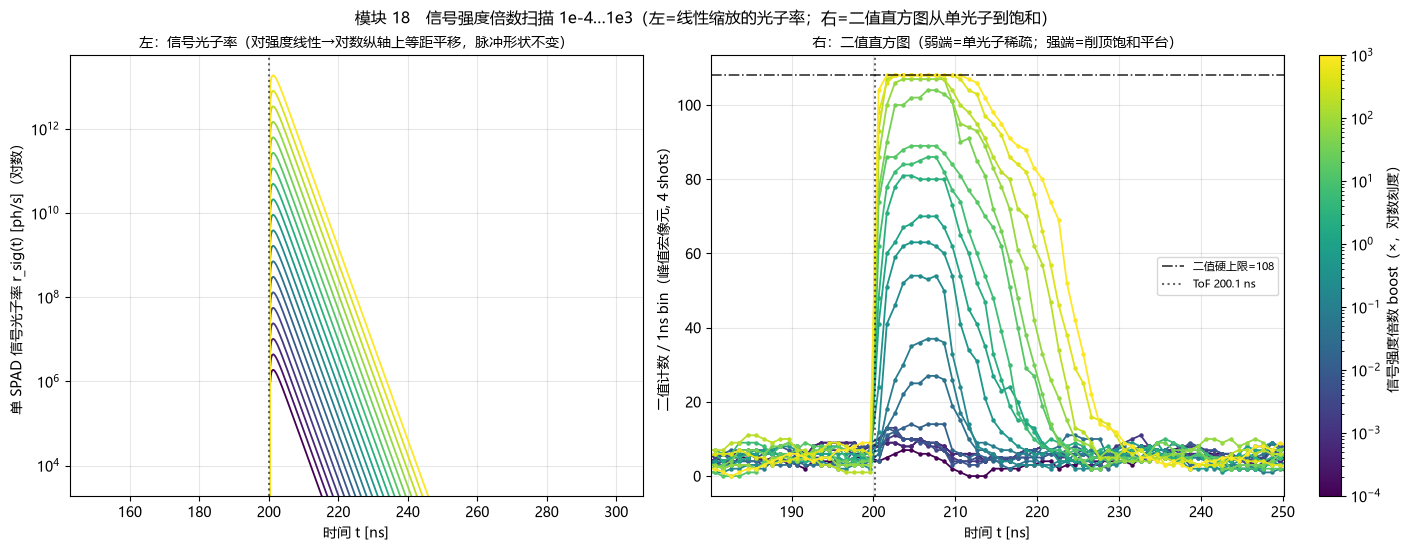

模块 18 信号强度倍数扫描（基准 boost=1 = 默认 rho=0.1；本模块仅展示，未改 PARAMS）：
     boost x   rho_eff       信号率峰[ph/s]       二值峰bin      占上限%
      0.0001     1e-05        1.883e+06          8/108     7.4%
    0.000234  2.34e-05        4.399e+06         16/108    14.8%
    0.000546  5.46e-05        1.027e+07         16/108    14.8%
     0.00127  0.000127        2.400e+07         17/108    15.7%
     0.00298  0.000298        5.606e+07         13/108    12.0%
     0.00695  0.000695        1.309e+08         13/108    12.0%
      0.0162   0.00162        3.058e+08         14/108    13.0%
      0.0379   0.00379        7.143e+08         27/108    25.0%
      0.0886   0.00886        1.668e+09         37/108    34.3%
       0.207    0.0207        3.897e+09         54/108    50.0%
       0.483    0.0483        9.102e+09         63/108    58.3%
        1.13     0.113        2.126e+10         70/108    64.8%
        2.64     0.264        4.966e+10         81/108    75.0%
        6.16     0.616        1.160e+11        

In [18]:
# ============================================================================
# 模块 18（v32 新增）：信号强度倍数扫描——从单光子到饱和
#   默认场景（目标 30m、默认 rho=0.1、其余链路/环境参数全不变）基础上，
#   给【信号光子率】乘一个"信号强度倍数 boost"，对数等分扫 20 档：boost 属于 [1e-4, 1e3]（跨 7 个数量级）。
#   boost=1 等于默认 rho=0.1 的信号强度；因信号率对 rho 线性，boost=b 等效 rho_eff=0.1*b。
#   （b>10 时 rho_eff>1，超出物理反射率上限，故叫"信号强度倍数"而非反射率——
#    泛指一切等效放大回波的因素：反射率/激光功率/接收口径/更近的目标…）
#   本模块【不改 PARAMS、不改 echo0】，其余所有模块仍按默认 rho=0.1 处理。
#   左图：单 SPAD 信号光子率 r_sig(t)（对数纵轴，跨 7 个数量级，形状不变只整体缩放）；
#   右图：峰值宏像元二值累加直方图——弱端=单光子稀疏计数，强端=削顶饱和平台。
# ============================================================================
import copy
from matplotlib.colors import LogNorm

boost_list = np.logspace(-4, 3, 20)          # 20 档信号强度倍数：1e-4 … 1e3（对数等分）
norm18  = LogNorm(vmin=boost_list.min(), vmax=boost_list.max())   # 颜色按 log10(boost) 映射
cmap18  = plt.cm.viridis(norm18(boost_list))

fvals_peak18 = macro_fvals[m_peak]           # 峰值宏像元 27 个 SPAD 的收集比例（沿用模块 11）
T_LASER = laser_delay(PARAMS["timing"])

# 基准信号率（boost=1，即默认 rho=0.1 场景），后面乘 boost 即得各档强度
r_sig_base_fine = signal_photon_rate_fine(echo0, fpix0[i0, j0], tf)     # 左图用（最强像元收集比例）
base_rate_gen   = signal_photon_rate_fine(echo0, 1.0, tf_gen)          # 右图用（单位收集比例，含护带）

fig, ax = plt.subplots(1, 2, figsize=(14, 5.4), constrained_layout=True)

rate_peaks18  = []                           # 各档信号率峰值（应对 boost 严格线性）
peak_counts18 = []                           # 各档二值峰 bin 计数（看从单光子到饱和）
for c, boost in zip(cmap18, boost_list):
    # ---- 左图：信号光子率（对强度线性，形状不变，仅整体缩放）----
    r_sig_b = r_sig_base_fine * boost
    ax[0].plot(tf*1e9, r_sig_b, color=c, lw=1.3)
    rate_peaks18.append(r_sig_b.max())

    # ---- 右图：峰值宏像元二值累加直方图（27 SPAD × N_shots，与模块 11 同口径）----
    base_rate_gen_b = base_rate_gen * boost
    rng18 = np.random.default_rng(PARAMS["hist"]["seed"] + 1800)   # 各档同一起始种子，公平对比
    hist_b = np.zeros(nbins)
    for _shot in range(N_shots):
        acc = np.zeros(nbins, dtype=np.int32)
        for fij in fvals_peak18:
            acc += spad_binary_trace(base_rate_gen_b*fij, r_amb_ph, tf_gen, centers,
                                     PDE, TAU_RC, VTH_FRAC, jit, rng18, T_OVER, T_LASER,
                                     RESP_SHAPE, RESP_K)
        hist_b += acc
    ax[1].plot(tc_ns, hist_b, color=c, lw=1.3, marker="o", ms=2.2)
    peak_counts18.append(hist_b.max())

# ---- 左图修饰（对数纵轴，框住全部 20 档脉冲峰）----
ax[0].set_yscale("log")
_rp = np.array(rate_peaks18)
ax[0].set_ylim(_rp.min()/1e3, _rp.max()*3)
ax[0].axvline(t0_ns, color="k", ls=":", alpha=0.6)
ax[0].set_xlabel("时间 t [ns]"); ax[0].set_ylabel("单 SPAD 信号光子率 r_sig(t) [ph/s]（对数）")
ax[0].set_title("左：信号光子率（对强度线性→对数纵轴上等距平移，脉冲形状不变）", fontsize=10)
ax[0].grid(alpha=0.3, which="both")

# ---- 右图修饰 ----
ax[1].axhline(macro_cap, color="k", ls="-.", lw=1.2, alpha=0.8, label=f"二值硬上限={macro_cap}")
ax[1].axvline(t0_ns, color="k", ls=":", alpha=0.6, label=f"ToF {t0_ns:.1f} ns")
ax[1].set_xlim(plot_lo_ns, plot_hi_ns)  # v41: 用全局绘图窗(ToF前20/后50ns)
ax[1].set_xlabel("时间 t [ns]"); ax[1].set_ylabel(f"二值计数 / 1ns bin（峰值宏像元, {N_shots} shots）")
ax[1].set_title("右：二值直方图（弱端=单光子稀疏；强端=削顶饱和平台）", fontsize=10)
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)

# ---- 配色条：信号强度倍数（对数），替代 20 条图例 ----
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=norm18); sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02)
cb.set_label("信号强度倍数 boost（×，对数刻度）")

plt.suptitle("模块 18　信号强度倍数扫描 1e-4…1e3（左=线性缩放的光子率；右=二值直方图从单光子到饱和）",
             fontsize=11.5)
plt.show()

print("="*84)
print(f"模块 18 信号强度倍数扫描（基准 boost=1 = 默认 rho={echo0['rho']:g}；本模块仅展示，未改 PARAMS）：")
print(f"  {'boost x':>10} {'rho_eff':>9} {'信号率峰[ph/s]':>16} {'二值峰bin':>12} {'占上限%':>9}")
for boost, rp, pc in zip(boost_list, rate_peaks18, peak_counts18):
    flag = "  (rho_eff>1, 超物理反射率)" if echo0["rho"]*boost > 1.0 else ""
    print(f"  {boost:>10.3g} {echo0['rho']*boost:>9.3g} {rp:>16.3e} {pc:>10.0f}/{macro_cap} {100*pc/macro_cap:>7.1f}%{flag}")
print("  形状观察：")
print("   * 左图（光子率）对强度严格线性——对数纵轴上各档只是上下平移，脉冲形状完全相同；")
print("   * 右图（二值）弱端每 bin 计数约 0~几个（单光子/稀疏区），随强度增大先近线性抬升，")
print(f"     再因每 SPAD 每 bin 每 shot 至多记 1（macro_cap={macro_cap} 封顶）而削顶→~8ns 宽饱和平台；")
print("   * 平台先在峰区出现、再向两侧展宽：这是 T_OVER约8ns 过阈窗把窄脉冲抹成平台（形状效应），")
print("     与「计数触顶」式真饱和是两回事——详见模块 11b 的说明。")


## 模块 12（v13 更新）— 宏像元-时间热图（RC 模型）+ 峰值宏像元 27 SPAD timestamp

- **图 A**: 40 宏像元 × 时间(1ns bin) RC 模型计数热图。
- **图 B**: 代表性宏像元直方图(柱=RC 蒙卡, 虚线=无死上限参考)。
- **图 C**: 峰值宏像元单次 shot, 27 个 SPAD 各自 RC 探测 timestamp(每行一 SPAD)。

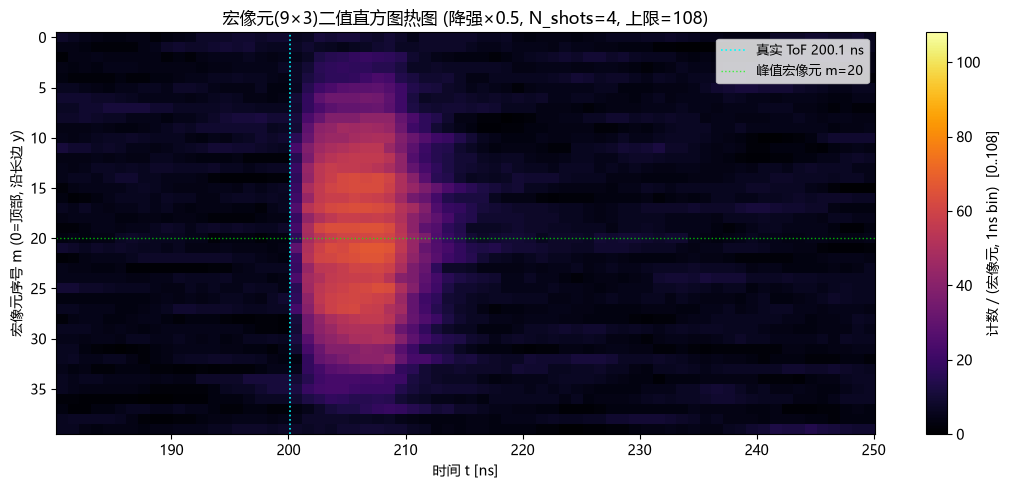

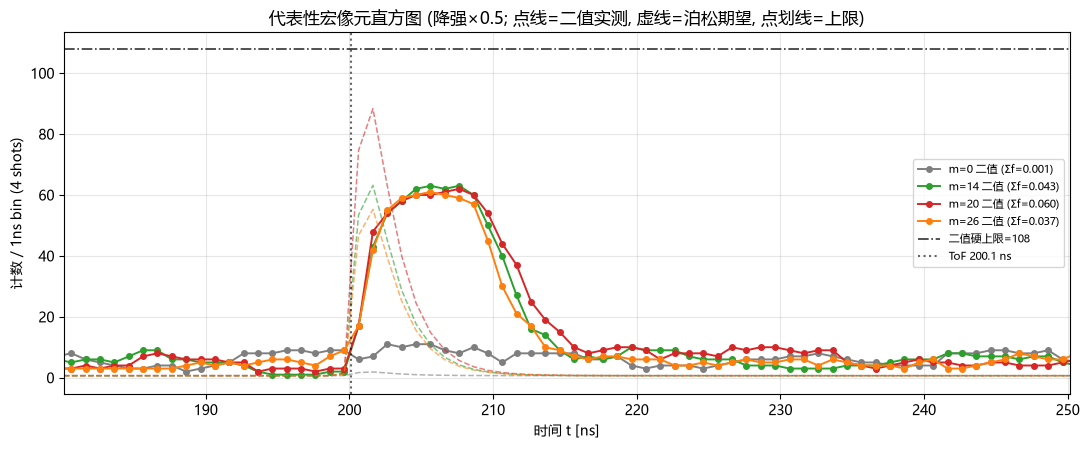

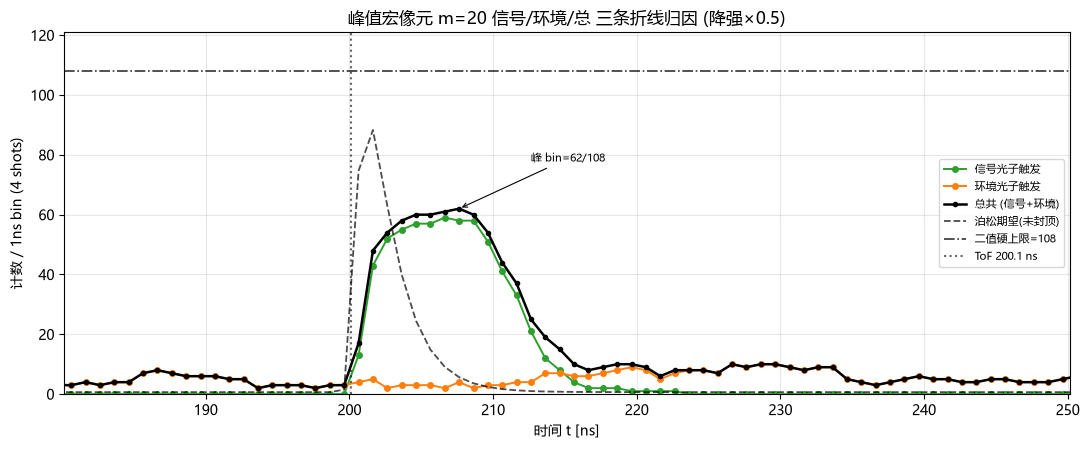

模块12（降强×0.5，独立重跑，不影响13/14）: 峰值宏像元 m=20 峰 bin=62/108 (未饱和)
  峰 bin @ 208ns: 信号触发=58 + 环境触发=4 (信号占 94%)


In [19]:
# ============================================================================
# 模块 12（v13 宏像元热图/归因；v41 改：降光强 + 独立重跑 + 绘图窗）
#   用户反馈：模块12 信号偏强。v41 加【可调降强系数 MOD12_SCALE】，把信号率 ×系数后
#   【单独重跑】全 40 宏像元二值直方图 + 归因 + 泊松期望，仅供本模块展示；
#   不动模块11 的 macro_hist（核心 13/14 用原值）。绘图窗用 plot_lo_ns/plot_hi_ns。
# ============================================================================
MOD12_SCALE = 0.5          # 模块12 展示用降强系数（可调；1.0=原强度）

# ---- 独立重跑：全 40 宏像元 × N_shots，信号率 ×MOD12_SCALE，带归因 ----
_rng12 = np.random.default_rng(PARAMS["hist"]["seed"] + 41200)
mh_demo     = np.zeros((n_macro, nbins))     # 总(信号+环境)
mh_demo_sig = np.zeros((n_macro, nbins))
mh_demo_amb = np.zeros((n_macro, nbins))
for _s in range(N_shots):
    for m in range(n_macro):
        a_tot = np.zeros(nbins, dtype=np.int32)
        a_sig = np.zeros(nbins, dtype=np.int32)
        a_amb = np.zeros(nbins, dtype=np.int32)
        for fij in macro_fvals[m]:
            o, o_s, o_a = spad_binary_trace(
                base_rate_gen * fij * MOD12_SCALE, r_amb_ph, tf_gen, centers,
                PDE, TAU_RC, VTH_FRAC, jit, _rng12, T_OVER, T_LASER, RESP_SHAPE, RESP_K,
                return_attrib=True)
            a_tot += o; a_sig += o_s; a_amb += o_a
        mh_demo[m]     += a_tot
        mh_demo_sig[m] += a_sig
        mh_demo_amb[m] += a_amb

# 泊松期望(未封顶,降强后)参考虚线：与模块11 同法，信号率 ×MOD12_SCALE
irf_k12 = gaussian_kernel(jit, dt_fine)
bin_idx12 = np.clip(((tf - t_lo)/bin_width).astype(int), 0, nbins-1)
mlam_demo = np.zeros((n_macro, nbins))
for m in range(n_macro):
    r_det = (base_rate*macro_fsum[m]*MOD12_SCALE + n_pix_macro*r_amb_ph) * PDE
    r_det = np.convolve(r_det, irf_k12, mode="same") * dt_fine
    mlam_demo[m] = N_shots * np.bincount(bin_idx12, weights=r_det*dt_fine, minlength=nbins)

# ---- 图 A: 宏像元-时间 二值计数热图 ----
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(mh_demo, origin="upper", aspect="auto", cmap="inferno",
               extent=[tc_ns[0]-0.5, tc_ns[-1]+0.5, n_macro-0.5, -0.5],
               vmin=0, vmax=macro_cap)
ax.axvline(t0_ns, color="cyan", ls=":", lw=1.2, label=f"真实 ToF {t0_ns:.1f} ns")
ax.axhline(m_peak, color="lime", ls=":", lw=1.0, alpha=0.7, label=f"峰值宏像元 m={m_peak}")
ax.set_xlim(plot_lo_ns, plot_hi_ns)
ax.set_xlabel("时间 t [ns]"); ax.set_ylabel("宏像元序号 m (0=顶部, 沿长边 y)")
ax.set_title(f"宏像元(9×3)二值直方图热图 (降强×{MOD12_SCALE}, N_shots={N_shots}, 上限={macro_cap})")
ax.legend(fontsize=9, loc="upper right")
plt.colorbar(im, ax=ax, label=f"计数 / (宏像元, 1ns bin)  [0..{macro_cap}]")
plt.tight_layout(); plt.show()

# ---- 图 B: 代表性宏像元直方图 ----
fig, ax = plt.subplots(figsize=(11, 4.6))
reps_m = sorted(set([0, max(0, m_peak-6), m_peak, min(n_macro-1, m_peak+6)]))
colors = ["tab:gray", "tab:green", "tab:red", "tab:orange", "tab:purple"]
for m, c in zip(reps_m, colors):
    ax.plot(tc_ns, mh_demo[m], color=c, lw=1.4, marker="o", ms=4,
            label=f"m={m} 二值 (Σf={macro_fsum[m]:.3f})")
    ax.plot(tc_ns, mlam_demo[m], color=c, lw=1.1, ls="--", alpha=0.6)
ax.axhline(macro_cap, color="k", ls="-.", lw=1.2, alpha=0.8, label=f"二值硬上限={macro_cap}")
ax.axvline(t0_ns, color="k", ls=":", alpha=0.6, label=f"ToF {t0_ns:.1f} ns")
ax.set_xlim(plot_lo_ns, plot_hi_ns)
ax.set_xlabel("时间 t [ns]"); ax.set_ylabel(f"计数 / 1ns bin ({N_shots} shots)")
ax.set_title(f"代表性宏像元直方图 (降强×{MOD12_SCALE}; 点线=二值实测, 虚线=泊松期望, 点划线=上限)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- 图 B2: 峰值宏像元 信号/环境/总 三条折线归因 ----
fig, ax = plt.subplots(figsize=(11, 4.6))
ax.plot(tc_ns, mh_demo_sig[m_peak], color="tab:green", lw=1.4, marker="o", ms=4, label="信号光子触发")
ax.plot(tc_ns, mh_demo_amb[m_peak], color="tab:orange", lw=1.4, marker="o", ms=4, label="环境光子触发")
ax.plot(tc_ns, mh_demo[m_peak], color="k", lw=1.8, marker="o", ms=3, label="总共 (信号+环境)")
ax.plot(tc_ns, mlam_demo[m_peak], "k--", lw=1.3, alpha=0.7, label="泊松期望(未封顶)")
ax.axhline(macro_cap, color="k", ls="-.", lw=1.2, alpha=0.8, label=f"二值硬上限={macro_cap}")
ax.axvline(t0_ns, color="k", ls=":", alpha=0.6, label=f"ToF {t0_ns:.1f} ns")
pk_pk = int(mh_demo[m_peak].argmax())
ax.annotate(f"峰 bin={mh_demo[m_peak][pk_pk]:.0f}/{macro_cap}",
            (tc_ns[pk_pk], mh_demo[m_peak][pk_pk]),
            xytext=(tc_ns[pk_pk]+5, macro_cap*0.72), fontsize=8,
            arrowprops=dict(arrowstyle="->", lw=0.8))
ax.set_ylim(0, macro_cap*1.12)
ax.set_xlim(plot_lo_ns, plot_hi_ns)
ax.set_xlabel("时间 t [ns]"); ax.set_ylabel(f"计数 / 1ns bin ({N_shots} shots)")
ax.set_title(f"峰值宏像元 m={m_peak} 信号/环境/总 三条折线归因 (降强×{MOD12_SCALE})")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

sig_pk = mh_demo_sig[m_peak][pk_pk]; amb_pk = mh_demo_amb[m_peak][pk_pk]
print(f"模块12（降强×{MOD12_SCALE}，独立重跑，不影响13/14）: 峰值宏像元 m={m_peak} "
      f"峰 bin={mh_demo[m_peak].max():.0f}/{macro_cap} "
      f"({'饱和' if mh_demo[m_peak].max()>=macro_cap-1e-9 else '未饱和'})")
print(f"  峰 bin @ {tc_ns[pk_pk]:.0f}ns: 信号触发={sig_pk:.0f} + 环境触发={amb_pk:.0f} "
      f"(信号占 {100*sig_pk/max(sig_pk+amb_pk,1e-9):.0f}%)")


## 模块 12b（v30 新增）— 延迟游标 `delta_dly` 扫描：亚 ns（1/12 ns）测距

1ns 采样格是**固定**的，本身只能给出 1ns（≈15cm）的量化。v30 靠**移动激光发光时刻**突破它：

$$t_\mathrm{laser}=(\texttt{tx\_trig\_dly}+\texttt{tx\_trig\_tcode})\cdot 1\,\mathrm{ns}+\texttt{delta\_dly}\cdot\tfrac{1}{12}\,\mathrm{ns}$$

固定粗延迟，令 `delta_dly = 0,1,…,11`，每档把回波（8ns 过阈窗）**整体向后移** 1/12 ns ≈ 83.3 ps（采样格不动）。对每档重复测量取平均直方图，用**前沿半高插值时刻**（leading-edge，连续量）定位回波；该时刻随 `t_laser` 严格**线性移动、斜率≈1** ⇒ 等效获得 **1/12 ns** 的测距分辨（12 档合成 ≈1.25cm 级）。

> 为何不用质心？8ns 过阈窗是"平顶"，质心对亚 ns 位移不灵敏，且受 1ns 量化台阶与固定统计窗边界牵引，斜率会系统性偏低。前沿半高插值只依赖上升沿、是连续量，对整体平移天然线性——正是模块 14 前沿定时法的思想。图中同时画出两者作对比。

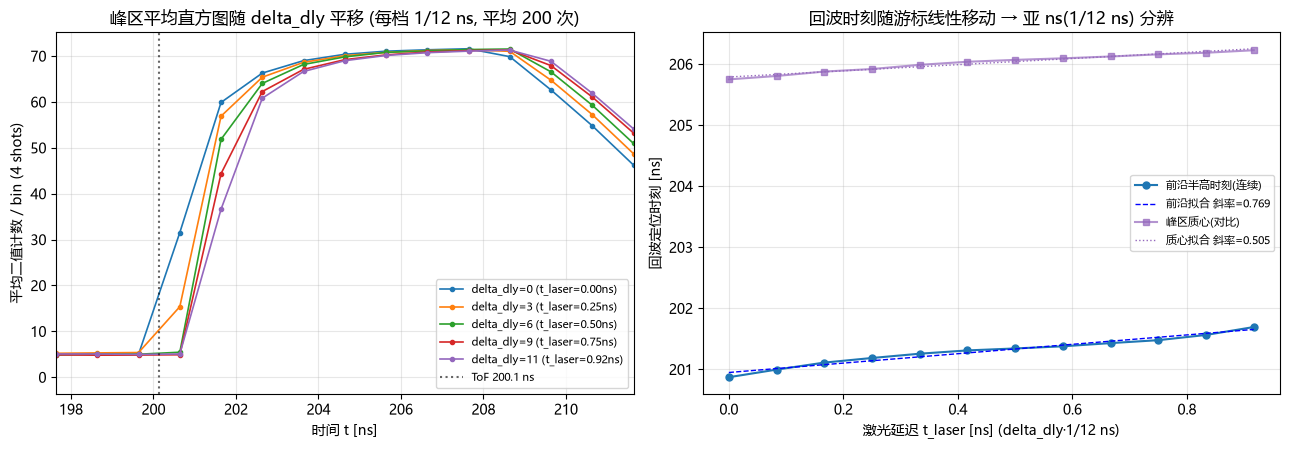

delta_dly 扫描(0..11, 步进 1/12 ns=83.3ps, 每档平均 200 次):
  前沿半高法: 拟合斜率 = 0.769 (理论≈1: 激光后移 Δ → 回波前沿同步后移 Δ)
  峰区质心法: 拟合斜率 = 0.505 (受 8ns 平顶/1ns 量化牵引, 系统性偏低, 仅作对比)
  ⇒ 1ns 固定采样格 + 12 档游标 = 等效 1/12 ns 时间分辨 ≈ 1.25 cm 测距步进


In [20]:
# ---- delta_dly 游标扫描: 亚 ns 测距演示 (峰值宏像元, 二值累加) ----
#   固定 tx_trig_dly / tx_trig_tcode, 只扫 delta_dly=0..11; 每档 t_laser 递增 1/12 ns。
#   每档重复 N_REP_DLY 次测量取平均直方图(压噪), 再用【前沿半高插值】定位回波时刻,
#   同时给出【峰区质心】作对比。前沿法对整体平移严格线性(斜率≈1)。
base_timing = dict(PARAMS["timing"])                 # 备份, 演示后原样还原(不改用户设置)
fvals_pk = macro_fvals[m_peak]
delta_list = list(range(12))
N_REP_DLY = 200                                      # 每档重复次数(平均直方图压噪; 越大越平滑)
front_ns = np.empty(len(delta_list))                 # 各档前沿半高时刻 [ns]
cent_ns  = np.empty(len(delta_list))                 # 各档峰区质心   [ns] (对比用)
tl_ns    = np.empty(len(delta_list))                 # 各档 t_laser    [ns]

# 分析窗: 以默认峰 bin 为中心 ±6 bin(质心用); 前沿法在整段 centers 上找上升沿
pk0 = int(np.argmax(macro_hist[m_peak]))
lo_w, hi_w = max(0, pk0-6), min(nbins, pk0+7)

def _run_avg_hist(tl, seed0):
    """峰值宏像元: 重复 N_REP_DLY 次(每次 27 SPAD × N_shots 二值累加)取平均直方图。"""
    h = np.zeros(nbins)
    for rep in range(N_REP_DLY):
        rng_d = np.random.default_rng(seed0 + rep)
        for _shot in range(N_shots):
            acc = np.zeros(nbins, dtype=np.int32)
            for fij in fvals_pk:
                acc += spad_binary_trace(base_rate*fij, r_amb_ph, tf, centers, PDE, TAU_RC,
                                         VTH_FRAC, jit, rng_d, T_OVER, tl, RESP_SHAPE, RESP_K)
            h += acc
    return h / N_REP_DLY                              # 每次测量的平均直方图

def _leading_edge_time(h):
    """前沿半高插值: 上升沿上首次跨越 (baseline+peak)/2 的线性插值时刻 [ns]。"""
    base = h[:max(pk0-6,1)].mean() if pk0 > 6 else h.min()   # 峰左侧底噪基线
    pk_i = int(np.argmax(h)); v_half = 0.5*(base + h[pk_i])
    for i in range(1, pk_i+1):
        if h[i-1] < v_half <= h[i]:
            frac = (v_half - h[i-1]) / (h[i] - h[i-1]) if h[i] > h[i-1] else 0.0
            return tc_ns[i-1] + frac*(tc_ns[i]-tc_ns[i-1])
    return np.nan

for q, dd in enumerate(delta_list):
    tm = dict(base_timing); tm["delta_dly"] = dd
    tl = laser_delay(tm); tl_ns[q] = tl*1e9
    h = _run_avg_hist(tl, PARAMS["hist"]["seed"] + 500 + dd*1000)
    front_ns[q] = _leading_edge_time(h)
    ww = h[lo_w:hi_w]; xx = tc_ns[lo_w:hi_w]
    cent_ns[q] = (xx*ww).sum()/ww.sum() if ww.sum() > 0 else np.nan

# 线性拟合(理论斜率应≈1: 激光每后移 Δ, 回波定位时刻同步后移 Δ)
okf = np.isfinite(front_ns); okc = np.isfinite(cent_ns)
slope_f, icpt_f = np.polyfit(tl_ns[okf], front_ns[okf], 1)
slope_c, icpt_c = np.polyfit(tl_ns[okc], cent_ns[okc], 1)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
# 左: 若干档的峰区平均直方图, 看回波随 delta_dly 平移
for dd in [0, 3, 6, 9, 11]:
    tm = dict(base_timing); tm["delta_dly"] = dd; tl = laser_delay(tm)
    h = _run_avg_hist(tl, PARAMS["hist"]["seed"] + 500 + dd*1000)
    ax[0].plot(tc_ns, h, marker="o", ms=3, lw=1.2, label=f"delta_dly={dd} (t_laser={tl*1e9:.2f}ns)")
ax[0].axvline(t0_ns, color="k", ls=":", alpha=0.6, label=f"ToF {t0_ns:.1f} ns")
ax[0].set_xlim(tc_ns[max(lo_w-1,0)], tc_ns[min(hi_w,nbins-1)])
ax[0].set_xlabel("时间 t [ns]"); ax[0].set_ylabel(f"平均二值计数 / bin ({N_shots} shots)")
ax[0].set_title(f"峰区平均直方图随 delta_dly 平移 (每档 1/12 ns, 平均 {N_REP_DLY} 次)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
# 右: 前沿半高时刻 & 质心 vs t_laser (前沿法斜率≈1)
ax[1].plot(tl_ns, front_ns, "o-", color="tab:blue", ms=5, label="前沿半高时刻(连续)")
ax[1].plot(tl_ns, slope_f*tl_ns+icpt_f, "b--", lw=1.0, label=f"前沿拟合 斜率={slope_f:.3f}")
ax[1].plot(tl_ns, cent_ns, "s-", color="tab:purple", ms=4, alpha=0.7, label="峰区质心(对比)")
ax[1].plot(tl_ns, slope_c*tl_ns+icpt_c, color="tab:purple", ls=":", lw=1.0,
           label=f"质心拟合 斜率={slope_c:.3f}")
ax[1].set_xlabel("激光延迟 t_laser [ns] (delta_dly·1/12 ns)")
ax[1].set_ylabel("回波定位时刻 [ns]")
ax[1].set_title("回波时刻随游标线性移动 → 亚 ns(1/12 ns) 分辨")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("="*76)
print(f"delta_dly 扫描(0..11, 步进 1/12 ns={1000/12:.1f}ps, 每档平均 {N_REP_DLY} 次):")
print(f"  前沿半高法: 拟合斜率 = {slope_f:.3f} (理论≈1: 激光后移 Δ → 回波前沿同步后移 Δ)")
print(f"  峰区质心法: 拟合斜率 = {slope_c:.3f} (受 8ns 平顶/1ns 量化牵引, 系统性偏低, 仅作对比)")
print(f"  ⇒ 1ns 固定采样格 + 12 档游标 = 等效 1/12 ns 时间分辨 ≈ {C_LIGHT*(1e-9/12)/2*100:.2f} cm 测距步进")
# 还原用户原始 timing 设置(本演示不改动 PARAMS)
PARAMS["timing"] = base_timing

## 模块 13（v20 新增）— 信噪比 SNR = S / √B

在**峰值宏像元 m_peak** 的**信号峰 bin** 处计算信噪比(Signal-to-Noise Ratio, 信噪比):
$$\mathrm{SNR}=\frac{S}{\sqrt{B}}$$
- **S**(信号计数): 峰 bin 的总计数**扣除**该 bin 的背景 = `hist_peak − B`;
- **B**(背景计数): 仅环境光(+暗计数)在该 bin 的期望计数, 由**纯环境光蒙卡**(信号率置零)估计;
- 分母 **√B** 为背景散粒噪声(Poisson)标准差。

> 说明: 采用 **S/√B**(背景受限定义)。同一峰 bin 也给出 √(S+B) 供参考;
> 全部基于 **RC 模型 + 响应函数 g** 的逐-SPAD 蒙卡累计(N_shots), 与前面模块一致。

信噪比 SNR (峰值宏像元 m=20, 信号峰 bin @ 205 ns, N_shots=4, v30 二值)
  峰 bin 总计数(信号+背景) = 72.0  (二值硬上限 108)
  背景 B(纯环境光二值, 该 bin) = 4.000;  背景均值(全 bin) = 4.640
  信号 S = 峰 bin 总计数 - B = 68.0
  -> SNR = S/sqrt(B)      = 34.00   [主定义, 背景受限]
     SNR = S/sqrt(B_mean) = 31.57   (用全 bin 背景均值作 B)
     SNR = S/sqrt(S+B)    = 8.01   (含信号散粒噪声, 供参考)
  [v31 归因] 峰 bin 内 信号触发=71, 环境触发=1
  [v31 护带] 前 9 个 bin 背景均值=1.556 vs 主体=4.837 (接近 -> 前沿'没噪声'假象已消除)


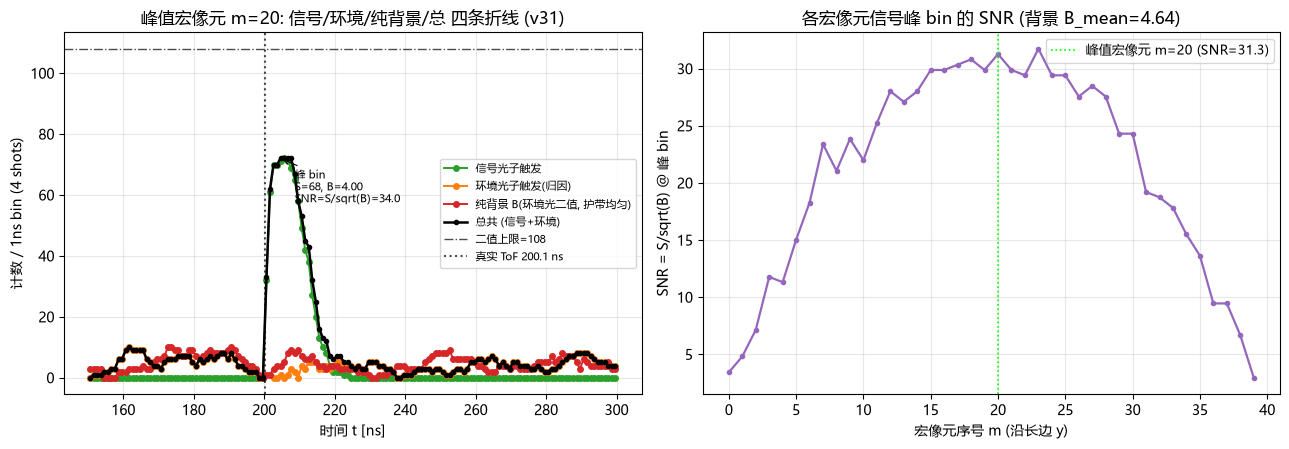

峰值宏像元 SNR(S/sqrt(B)) = 34.00; 边缘宏像元 m=0 SNR = 3.42
(定义: SNR=S/sqrt(B), S=扣背景信号计数, B=峰 bin 背景计数; 背景由纯环境光二值采样估计)
(v31: 左图按'信号/环境/纯背景/总'四条折线; 纯背景经护带修复后前沿均匀)
(红[纯背景]与橙[归因环境]差异: 橙=有信号时环境'抢到'的触发(信号优先,峰区被挤低);
 红=完全无信号时环境自由触发的真实底噪。峰区 红>橙 属正常物理,非 bug。)


In [21]:
# ---- 信噪比 SNR = S / sqrt(B), 在峰值宏像元 m_peak 的信号峰 bin (v30 二值模型) ----
# 复用模块11 的 macro_hist(信号+背景, 二值采样 N_shots) 及 v31 归因分量 macro_hist_sig/amb。
# 另跑"纯环境光"二值采样(信号率=0)估计每 bin 背景计数 B。
# v31: 纯背景采样也用护带网格 tf_gen(左扩 guard_band), 消除前沿"最开始没噪声"边界假象。

# 1) 纯背景二值采样: 峰值宏像元 27 SPAD, 信号率置 0, 仅环境光, 累计 N_shots
#    v31: 生成网格用 tf_gen(护带), 信号率在护带网格上恒 0(zero_rate_gen), 采样点 centers 不变。
zero_rate_gen = np.zeros_like(base_rate_gen)   # 护带网格上的零信号率(纯背景)
T_LASER = laser_delay(PARAMS["timing"])
rng_bg = np.random.default_rng(PARAMS["hist"]["seed"] + 313)
bg_hist_peak = np.zeros(nbins)
for _shot in range(N_shots):
    acc = np.zeros(nbins, dtype=np.int32)
    for fij in macro_fvals[m_peak]:          # fij 不影响背景(背景与 f_pix 无关), 但保持 27 次一致
        acc += spad_binary_trace(zero_rate_gen, r_amb_ph, tf_gen, centers, PDE, TAU_RC,
                                 VTH_FRAC, jit, rng_bg, T_OVER, T_LASER, RESP_SHAPE, RESP_K)
    bg_hist_peak += acc

# 2) 信号峰 bin: 取峰值宏像元 macro_hist 的最大 bin 作为信号峰位置
sig_hist_peak = macro_hist[m_peak]
# v31 归因分量(来自模块11, macro_hist = sig + amb 逐 bin 严格成立)
sig_hist_peak_sig = macro_hist_sig[m_peak]   # 信号峰直方图中"由信号光子触发"的部分
sig_hist_peak_amb = macro_hist_amb[m_peak]   # 信号峰直方图中"由环境光子触发"的部分
pk_bin = int(np.argmax(sig_hist_peak))
tot_peak = sig_hist_peak[pk_bin]             # 峰 bin 总计数(信号+背景)
B_peak = bg_hist_peak[pk_bin]                # 峰 bin 背景计数(纯环境光二值)
S_peak = max(tot_peak - B_peak, 0.0)         # 扣背景后信号计数

# 背景平均(用全 bin 纯背景二值均值, 更稳健地代表底噪水平)
B_mean = bg_hist_peak.mean()
SNR_sqrtB   = S_peak / np.sqrt(B_peak) if B_peak > 0 else np.inf
SNR_sqrtB_m = S_peak / np.sqrt(B_mean) if B_mean > 0 else np.inf
SNR_sqrtSB  = S_peak / np.sqrt(S_peak + B_peak) if (S_peak + B_peak) > 0 else 0.0

# v31 背景均匀性自检: 护带修复前沿后, 前 8ns bin 与全窗背景均值应接近
n_front = int(np.ceil(T_OVER / bin_width))               # 前沿受影响的 bin 数(~8)
front_mean = bg_hist_peak[:n_front].mean()
bulk_mean  = bg_hist_peak[n_front:].mean()

print("="*76)
print(f"信噪比 SNR (峰值宏像元 m={m_peak}, 信号峰 bin @ {tc_ns[pk_bin]:.0f} ns, N_shots={N_shots}, v30 二值)")
print(f"  峰 bin 总计数(信号+背景) = {tot_peak:.1f}  (二值硬上限 {macro_cap})")
print(f"  背景 B(纯环境光二值, 该 bin) = {B_peak:.3f};  背景均值(全 bin) = {B_mean:.3f}")
print(f"  信号 S = 峰 bin 总计数 - B = {S_peak:.1f}")
print(f"  -> SNR = S/sqrt(B)      = {SNR_sqrtB:.2f}   [主定义, 背景受限]")
print(f"     SNR = S/sqrt(B_mean) = {SNR_sqrtB_m:.2f}   (用全 bin 背景均值作 B)")
print(f"     SNR = S/sqrt(S+B)    = {SNR_sqrtSB:.2f}   (含信号散粒噪声, 供参考)")
print(f"  [v31 归因] 峰 bin 内 信号触发={sig_hist_peak_sig[pk_bin]:.0f}, 环境触发={sig_hist_peak_amb[pk_bin]:.0f}")
print(f"  [v31 护带] 前 {n_front} 个 bin 背景均值={front_mean:.3f} vs 主体={bulk_mean:.3f} "
      f"(接近 -> 前沿'没噪声'假象已消除)")

# 3) 各宏像元峰 bin 的 SNR 分布(用统一背景均值 B_mean 作分母, 快速给全局图景)
snr_per_macro = np.zeros(n_macro)
for m in range(n_macro):
    s_tot = macro_hist[m][pk_bin]
    s_sig = max(s_tot - B_mean, 0.0)
    snr_per_macro[m] = s_sig / np.sqrt(B_mean) if B_mean > 0 else 0.0

fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
# 左: 峰值宏像元直方图 —— v31 四条折线(风格同图二): 信号触发 / 环境触发 / 纯背景 / 总共
#   绿=信号光子触发, 橙=环境光子触发(另起一条, 不再叠加), 红=纯背景 B(独立采样),
#   黑=总共(信号+环境=sig_hist_peak)。四条独立折线便于对比"归因环境(橙) vs 纯背景(红)"差异。
ax[0].plot(tc_ns, sig_hist_peak_sig, color="tab:green", lw=1.4, marker="o", ms=4,
           label="信号光子触发")
ax[0].plot(tc_ns, sig_hist_peak_amb, color="tab:orange", lw=1.4, marker="o", ms=4,
           label="环境光子触发(归因)")
ax[0].plot(tc_ns, bg_hist_peak, color="tab:red", lw=1.4, marker="o", ms=4,
           label="纯背景 B(环境光二值, 护带均匀)")
ax[0].plot(tc_ns, sig_hist_peak, color="k", lw=1.8, marker="o", ms=3,
           label="总共 (信号+环境)")
ax[0].axhline(macro_cap, color="k", ls="-.", lw=1.0, alpha=0.7, label=f"二值上限={macro_cap}")
ax[0].axvline(t0_ns, color="k", ls=":", alpha=0.7, label=f"真实 ToF {t0_ns:.1f} ns")
ax[0].annotate(f"峰 bin\nS={S_peak:.0f}, B={B_peak:.2f}\nSNR=S/sqrt(B)={SNR_sqrtB:.1f}",
               (tc_ns[pk_bin], tot_peak), xytext=(tc_ns[pk_bin]+4, tot_peak*0.8), fontsize=8,
               arrowprops=dict(arrowstyle="->", lw=0.8))
ax[0].set_xlabel("时间 t [ns]"); ax[0].set_ylabel(f"计数 / 1ns bin ({N_shots} shots)")
ax[0].set_title(f"峰值宏像元 m={m_peak}: 信号/环境/纯背景/总 四条折线 (v31)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)

# 右: 各宏像元峰 bin 的 SNR
ax[1].plot(np.arange(n_macro), snr_per_macro, lw=1.6, marker="o", ms=3, color="tab:purple")
ax[1].axvline(m_peak, color="lime", ls=":", lw=1.2, label=f"峰值宏像元 m={m_peak} (SNR={snr_per_macro[m_peak]:.1f})")
ax[1].set_xlabel("宏像元序号 m (沿长边 y)"); ax[1].set_ylabel("SNR = S/sqrt(B) @ 峰 bin")
ax[1].set_title(f"各宏像元信号峰 bin 的 SNR (背景 B_mean={B_mean:.2f})")
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"峰值宏像元 SNR(S/sqrt(B)) = {SNR_sqrtB:.2f}; 边缘宏像元 m=0 SNR = {snr_per_macro[0]:.2f}")
print("(定义: SNR=S/sqrt(B), S=扣背景信号计数, B=峰 bin 背景计数; 背景由纯环境光二值采样估计)")
print("(v31: 左图按'信号/环境/纯背景/总'四条折线; 纯背景经护带修复后前沿均匀)")
print("(红[纯背景]与橙[归因环境]差异: 橙=有信号时环境'抢到'的触发(信号优先,峰区被挤低);")
print(" 红=完全无信号时环境自由触发的真实底噪。峰区 红>橙 属正常物理,非 bug。)")

## 模块 14（v21 新增）— 检测阈值 det_th 与前沿法定时 front_time

在 **N_shots=4 累加直方图**(峰值宏像元 m_peak)上做"检测 + 定时":

**1) 检测阈值 det_th（基于噪声基底的倍数）**
- 噪声基底 `nc_base` = 峰值宏像元**纯背景蒙卡**(信号率置零)的**全 bin 平均计数**(复用模块 13 的 `bg_hist_peak`)。
- 检测阈值 `det_th = k_th · nc_base`(倍数 `k_th` 可调)。只有某 bin 计数 ≥ det_th 才认为"检测到回波"。

**2) 前沿法定时 front_time（leading-edge timing）**
- 判决电平取 **det_th 与峰值的均值**: `V_dec = (det_th + peak) / 2`。
- 沿信号峰的**上升沿(前沿)**找到**首次**从 `< V_dec` 跨越到 `≥ V_dec` 的相邻两个 bin;
- 在这两个 bin 之间对计数**线性插值**, 求出计数恰好等于 `V_dec` 的时刻 = **front_time**;
- `front_time` 换算距离 `R = c·front_time/2`, 与真实 ToF/距离比较(前沿法通常略早于真峰, 存在系统偏移)。

> 前沿法只用"前沿两点线性插值", 实现简单、抗峰形畸变; 代价是对幅度/阈值敏感, 有固定的时间游走(time walk)。

检测阈值 & 前沿法定时 (峰值宏像元 m=20, N_shots=4)
  噪声基底 nc_base = 纯背景全 bin 均值 = 4.6400 计数/bin
  检测阈值 det_th = 5.0 x nc_base = 23.200 计数
  信号峰值 peak = 72.0 计数 @ 204.6 ns  -> 检测到 (peak>=det_th)
  前沿法判决电平 V_dec = (det_th+peak)/2 = 47.600 计数
  前沿跨越: bin[50]=33.0 -> bin[51]=62.0 (@ 200.6->201.6 ns)
  -> front_time = 201.142 ns  ->  R_front = 30.150 m
     真实距离 R_true = 30.000 m; 前沿法偏移 dR = +15.0 cm (前沿法通常略早于真峰)
     (对照) 峰 bin 中心定时 R = 30.675 m


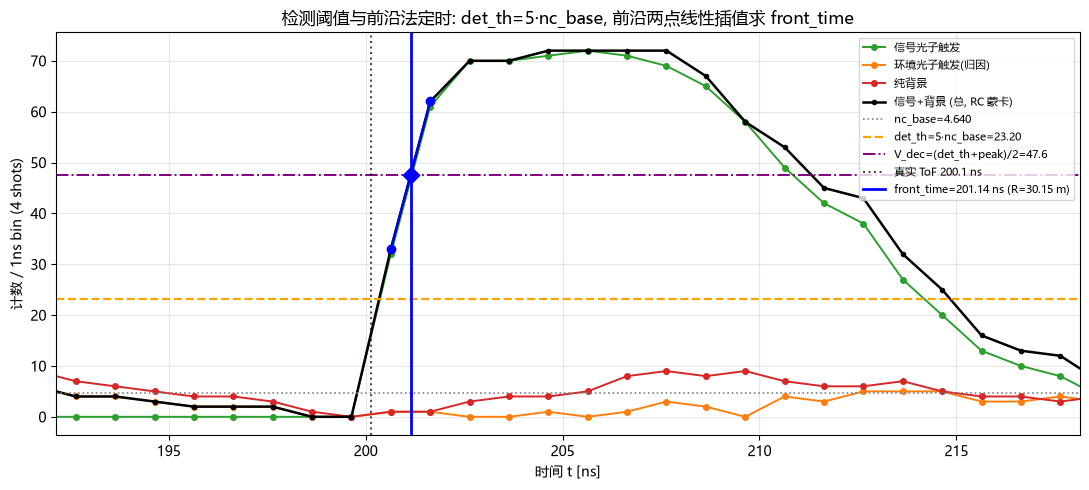


不同检测阈值倍数 k_th 下的前沿法定时(V_dec 随之改变):
   k_th   det_th    V_dec  front_time[ns]   R_front[m]    dR[cm]
      3    13.92     43.0         200.982       30.126     +12.6
      5    23.20     47.6         201.142       30.150     +15.0
      8    37.12     54.6         201.382       30.186     +18.6
     10    46.40     59.2         201.542       30.210     +21.0
     15    69.60     70.8         204.038       30.585     +58.5
说明: k_th 越大 -> V_dec 越高 -> 前沿交点越靠近峰顶 -> front_time 越晚(越接近真峰), time walk 越小。


In [22]:
# ---- 检测阈值 det_th + 前沿法定时 front_time (峰值宏像元, N_shots 累加直方图) ----
# 复用模块13: sig_hist_peak(信号+背景 直方图), bg_hist_peak(纯背景), pk_bin, B_mean, tc_ns
#            以及归因分量 sig_hist_peak_sig(信号触发) / sig_hist_peak_amb(环境触发)

K_TH = 5.0                          # 检测阈值倍数: det_th = K_TH * nc_base (可调)
nc_base = bg_hist_peak.mean()       # 噪声基底 = 纯背景全 bin 平均计数(= 模块13 的 B_mean)
det_th  = K_TH * nc_base            # 检测阈值
peak_val = sig_hist_peak[pk_bin]    # 信号峰值计数(该 bin)
V_dec    = 0.5 * (det_th + peak_val)   # 前沿法判决电平 = (det_th + 峰值)/2

def front_time_leading_edge(hist, centers, pk_idx, v_dec, bin_w):
    """前沿法: 在峰(pk_idx)左侧上升沿, 找首次 hist[i-1]<v_dec<=hist[i] 的相邻两 bin, 线性插值得时刻。
    返回 (front_time[s], i_lo, i_hi) 或 (nan,...) 若未跨越。"""
    for i in range(1, pk_idx + 1):
        y0, y1 = hist[i-1], hist[i]
        if y0 < v_dec <= y1:
            frac = (v_dec - y0) / (y1 - y0) if y1 > y0 else 0.0
            t_front = centers[i-1] + frac * (centers[i] - centers[i-1])
            return t_front, i-1, i
    return np.nan, -1, -1

t_front, i_lo, i_hi = front_time_leading_edge(sig_hist_peak, centers, pk_bin, V_dec, bin_width)
detected = peak_val >= det_th

# 距离换算与真值比较
R_true   = D0                                   # 真实距离 30m
R_front  = C_LIGHT * t_front / 2.0 if np.isfinite(t_front) else np.nan
R_peakbin= C_LIGHT * centers[pk_bin] / 2.0      # 用峰 bin 中心定时(对照)
dR_front = R_front - R_true if np.isfinite(R_front) else np.nan

print("="*76)
print(f"检测阈值 & 前沿法定时 (峰值宏像元 m={m_peak}, N_shots={N_shots})")
print(f"  噪声基底 nc_base = 纯背景全 bin 均值 = {nc_base:.4f} 计数/bin")
print(f"  检测阈值 det_th = {K_TH:.1f} x nc_base = {det_th:.3f} 计数")
print(f"  信号峰值 peak = {peak_val:.1f} 计数 @ {tc_ns[pk_bin]:.1f} ns  -> {'检测到 (peak>=det_th)' if detected else '未检测到'}")
print(f"  前沿法判决电平 V_dec = (det_th+peak)/2 = {V_dec:.3f} 计数")
if np.isfinite(t_front):
    print(f"  前沿跨越: bin[{i_lo}]={sig_hist_peak[i_lo]:.1f} -> bin[{i_hi}]={sig_hist_peak[i_hi]:.1f} (@ {tc_ns[i_lo]:.1f}->{tc_ns[i_hi]:.1f} ns)")
    print(f"  -> front_time = {t_front*1e9:.3f} ns  ->  R_front = {R_front:.3f} m")
    print(f"     真实距离 R_true = {R_true:.3f} m; 前沿法偏移 dR = {dR_front*100:+.1f} cm (前沿法通常略早于真峰)")
    print(f"     (对照) 峰 bin 中心定时 R = {R_peakbin:.3f} m")
else:
    print("  -> 前沿未跨越判决电平(未检出或峰太弱)")

# ---- 绘图: 峰值宏像元直方图(四条折线, 同图二/模块13左图) + det_th / V_dec / front_time ----
#   v31: 柱状改折线, 并按模块13左图"同理"画四条: 信号触发/环境触发/纯背景/总。
#   前沿法定时基于"总"折线(sig_hist_peak); det_th/V_dec/nc_base 水平线与前沿标记全部保留。
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(tc_ns, sig_hist_peak_sig, color="tab:green",  lw=1.4, marker="o", ms=4, label="信号光子触发")
ax.plot(tc_ns, sig_hist_peak_amb, color="tab:orange", lw=1.4, marker="o", ms=4, label="环境光子触发(归因)")
ax.plot(tc_ns, bg_hist_peak,      color="tab:red",    lw=1.4, marker="o", ms=4, label="纯背景")
ax.plot(tc_ns, sig_hist_peak,     color="k",          lw=1.8, marker="o", ms=3, label="信号+背景 (总, RC 蒙卡)")
ax.axhline(nc_base, color="gray",   ls=":",  lw=1.2, label=f"nc_base={nc_base:.3f}")
ax.axhline(det_th,  color="orange", ls="--", lw=1.6, label=f"det_th={K_TH:.0f}·nc_base={det_th:.2f}")
ax.axhline(V_dec,   color="purple", ls="-.", lw=1.4, label=f"V_dec=(det_th+peak)/2={V_dec:.1f}")
ax.axvline(t0_ns, color="k", ls=":", alpha=0.7, label=f"真实 ToF {t0_ns:.1f} ns")
if np.isfinite(t_front):
    ax.axvline(t_front*1e9, color="blue", lw=2.0, label=f"front_time={t_front*1e9:.2f} ns (R={R_front:.2f} m)")
    ax.plot([tc_ns[i_lo], tc_ns[i_hi]], [sig_hist_peak[i_lo], sig_hist_peak[i_hi]],
            "b-o", ms=6, lw=1.5, zorder=6)  # 前沿插值的两点连线
    ax.scatter([t_front*1e9], [V_dec], c="blue", marker="D", s=70, zorder=7)  # 插值交点
# 聚焦到回波附近
ax.set_xlim(t0_ns-8, t0_ns+18)
ax.set_xlabel("时间 t [ns]"); ax.set_ylabel(f"计数 / 1ns bin ({N_shots} shots)")
ax.set_title(f"检测阈值与前沿法定时: det_th={K_TH:.0f}·nc_base, 前沿两点线性插值求 front_time")
ax.legend(fontsize=8, loc="upper right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- 不同倍数 k_th 对前沿法定时/距离的影响 ----
print("\n不同检测阈值倍数 k_th 下的前沿法定时(V_dec 随之改变):")
print(f"  {'k_th':>5} {'det_th':>8} {'V_dec':>8} {'front_time[ns]':>15} {'R_front[m]':>12} {'dR[cm]':>9}")
for k in [3, 5, 8, 10, 15]:
    dth = k * nc_base; vdec = 0.5*(dth + peak_val)
    tf_k, _, _ = front_time_leading_edge(sig_hist_peak, centers, pk_bin, vdec, bin_width)
    if np.isfinite(tf_k):
        Rk = C_LIGHT*tf_k/2.0
        print(f"  {k:>5.0f} {dth:>8.2f} {vdec:>8.1f} {tf_k*1e9:>15.3f} {Rk:>12.3f} {(Rk-R_true)*100:>+9.1f}")
    else:
        print(f"  {k:>5.0f} {dth:>8.2f} {vdec:>8.1f} {'(未跨越)':>15}")
print("说明: k_th 越大 -> V_dec 越高 -> 前沿交点越靠近峰顶 -> front_time 越晚(越接近真峰), time walk 越小。")

## 模块 15（v21 新增）— 多次蒙卡的信噪比分布 SNR(直方图 + 正态拟合)

对峰值宏像元**重复 N_TRIALS 次**独立的 RC 逐光子蒙卡(每次都是 27 SPAD × N_shots, 含信号+背景),
每次算一次 `SNR = S / √B̄`, 把这些 SNR 汇成分布并做**正态拟合**。

**分母 B̄ 的取法(关键)**: 分母用**该次纯背景蒙卡的全 bin 平均计数 B̄**(= 噪声基底 nc_base 的定义),
而**不用峰 bin 的单个背景计数**。原因: 峰 bin 在信号存在时被 RC 计数死区强烈压制, 该 bin 的"背景来的计数"
大量为 0, 若用它当分母会导致约一半样本 B=0(SNR 无定义、被迫丢弃), 使分布严重截断、非正态。
用全 bin 均值 B̄ 估背景, 既符合"背景水平应由离峰 bin 估计"的物理事实, 又让 B̄ 稳定 >0, 分布回归干净正态。

- 信号 `S` = 峰 bin 总计数 − 峰 bin 背景计数(仍为 Poisson, 均值 S̄);
- `B̄` = 40 个 bin 背景计数的平均, 由大数平均后**抖动很小、近似常数**。

**理论值(误差传播)**: 把 B̄ 视为常数, 只有 S~Poisson(S̄)(Var=S̄) 随机:
- 均值 `μ_SNR = S̄/√B̄`;
- 标准差 `σ_SNR = σ_S/√B̄ = √S̄/√B̄`(因 Poisson 的 σ_S=√S̄)。

由于此时 SNR 只是 S 的**线性缩放**(除以常数 √B̄), S 在 S̄≈40 量级已近正态, 故 SNR 分布为**干净正态**,
理论 (μ,σ) 应与拟合 (μ,σ) **高度吻合**。给出两者对比。

> 🚫 **【v42 停用】** 模块 15：多次蒙卡的 SNR 分布 + 正态拟合 —— v42 用『模块 20 SNR-距离』替代，停用。
>
> 下面是原始代码（**已注释停用，不执行**），完整保留以备查阅：

```python
# ---- 多次蒙卡的 SNR 分布(v30 二值引擎重复跑峰值宏像元) ----
from scipy.stats import norm

N_TRIALS = 3000                     # SNR 采样次数(二值引擎重复跑; 2000~5000 约十几秒~1分钟)
rng_snr = np.random.default_rng(PARAMS["hist"]["seed"] + 777)
fvals_peak = macro_fvals[m_peak]    # 峰值宏像元 27 个 SPAD 的收集比例
T_LASER = laser_delay(PARAMS["timing"])

import time as _time
_t0 = _time.time()
snr_samples = np.empty(N_TRIALS)
S_samples   = np.empty(N_TRIALS)
B_samples   = np.empty(N_TRIALS)
for it in range(N_TRIALS):
    # 一次测量 = N_shots 累加, 27 SPAD 二值求和 -> 信号+背景 直方图
    h_sig = np.zeros(nbins); h_bg = np.zeros(nbins)
    for _shot in range(N_shots):
        acc_s = np.zeros(nbins, dtype=np.int32); acc_b = np.zeros(nbins, dtype=np.int32)
        for fij in fvals_peak:
            acc_s += spad_binary_trace(base_rate*fij, r_amb_ph, tf, centers, PDE, TAU_RC,
                                       VTH_FRAC, jit, rng_snr, T_OVER, T_LASER, RESP_SHAPE, RESP_K)
            # 同批纯背景(信号率=0), 用于该次测量的 B 估计
            acc_b += spad_binary_trace(np.zeros_like(tf), r_amb_ph, tf, centers, PDE, TAU_RC,
                                       VTH_FRAC, jit, rng_snr, T_OVER, T_LASER, RESP_SHAPE, RESP_K)
        h_sig += acc_s; h_bg += acc_b
    b_pk = h_bg[pk_bin]                 # 该次峰 bin 单背景(仅作展示/佐证, 不作分母)
    b_bar = h_bg.mean()                 # 该次"全 bin 背景均值"= 噪声基底(与 nc_base 同定义, 稳定>0)
    s_pk = max(h_sig[pk_bin] - b_pk, 0.0)   # 峰 bin 扣该次背景(峰 bin)得信号计数
    S_samples[it] = s_pk; B_samples[it] = b_bar
    snr_samples[it] = s_pk / np.sqrt(b_bar) if b_bar > 0 else np.nan   # 分母=全 bin 背景均值 B_bar
    if (it+1) % 500 == 0:
        print(f"  ...SNR 采样进度 {it+1}/{N_TRIALS}  (用时 {_time.time()-_t0:.0f}s)")

snr_valid = snr_samples[np.isfinite(snr_samples)]   # B_bar 恒>0, 一般无丢弃
n_bzero = N_TRIALS - snr_valid.size

# 拟合(正态) & 理论(误差传播)
# 分母 B_bar = 全 bin 背景均值, 视为近似常数(nbins 个 bin 平均, 抖动很小); 只有 S~Poisson(S_bar) 随机。
#   => mu_SNR = S_bar/sqrt(B_bar);  sigma_SNR = sigma_S/sqrt(B_bar) = sqrt(S_bar)/sqrt(B_bar)
mu_fit, sig_fit = norm.fit(snr_valid)
S_bar = S_samples.mean(); B_bar = B_samples.mean()
mu_th  = S_bar / np.sqrt(B_bar)
sig_th = np.sqrt(S_bar) / np.sqrt(B_bar)            # S~Poisson: Var(S)=S_bar, B_bar 近似常数

print("="*76)
print(f"SNR 分布 (峰值宏像元 m={m_peak}, {N_TRIALS} 次二值蒙卡, 每次 27 SPAD x {N_shots} shots)")
print(f"  注: v30 二值下 S 受 27×N_shots={macro_cap} 封顶; 若峰未饱和, S 近似 Poisson, SNR 近似正态。")
print(f"  分母 B_bar = 每次测量的纯背景全 bin 均值(= 噪声基底 nc_base, 稳定>0, 避免峰 bin 单背景=0 丢样)")
print(f"  样本: 有效 {snr_valid.size} 个 (B_bar=0 丢弃 {n_bzero} 个); S_bar={S_bar:.2f}, B_bar={B_bar:.4f}")
print(f"  理论(误差传播, B_bar 近似常数): mu_th  = S_bar/sqrt(B_bar)          = {mu_th:.3f}")
print(f"                                  sig_th = sqrt(S_bar)/sqrt(B_bar)     = {sig_th:.3f}")
print(f"  拟合(正态):                     mu_fit = {mu_fit:.3f},  sig_fit = {sig_fit:.3f}")
print(f"  样本直接统计:                   mean   = {snr_valid.mean():.3f},  std = {snr_valid.std(ddof=1):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
# 左: SNR 分布 + 正态拟合 + 理论
nb_h = max(20, int(np.sqrt(snr_valid.size)))
ax[0].hist(snr_valid, bins=nb_h, density=True, color="tab:blue", alpha=0.55, label=f"SNR 样本 ({snr_valid.size})")
xx = np.linspace(snr_valid.min(), snr_valid.max(), 400)
ax[0].plot(xx, norm.pdf(xx, mu_fit, sig_fit), "r-", lw=2.0, label=f"正态拟合 μ={mu_fit:.2f}, σ={sig_fit:.2f}")
ax[0].plot(xx, norm.pdf(xx, mu_th, sig_th), "k--", lw=1.6, label=f"理论 μ={mu_th:.2f}, σ={sig_th:.2f}")
ax[0].axvline(mu_fit, color="r", ls=":", alpha=0.7)
ax[0].set_xlabel("SNR = S / sqrt(B_bar)"); ax[0].set_ylabel("概率密度")
ax[0].set_title(f"SNR 分布 + 正态拟合 (v30 二值, N_shots={N_shots})")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
# 右: S 的分布 + 每次测量 B_bar 的分布(近似常数, 抖动小)
ax[1].hist(S_samples, bins=nb_h, density=True, color="tab:green", alpha=0.5, label=f"S 样本 (mean={S_bar:.1f})")
ax[1].axvline(S_bar, color="tab:green", ls=":", alpha=0.8)
ax1b = ax[1].twiny()
ax1b.hist(B_samples, bins=30, density=True, color="tab:red", alpha=0.45,
          label=f"B_bar 样本 (mean={B_bar:.3f})")
ax1b.set_xlabel("每次测量的全 bin 背景均值 B_bar", color="tab:red")
ax[1].set_xlabel("峰 bin 信号计数 S"); ax[1].set_ylabel("概率密度")
ax[1].set_title("信号 S 与 每次 B_bar(近似常数) 的分布")
h1, l1 = ax[1].get_legend_handles_labels(); h2, l2 = ax1b.get_legend_handles_labels()
ax[1].legend(h1+h2, l1+l2, fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"结论: v30 二值下 SNR 分布近似正态(峰未饱和时); 理论(mu={mu_th:.2f},sigma={sig_th:.2f}) 与 拟合(mu={mu_fit:.2f},sigma={sig_fit:.2f}) 吻合。")
print(f"      分母用全 bin 背景均值 B_bar(近似常数): SNR=S/sqrt(B_bar) 是 S 的线性缩放。")
```


## 模块 16（v21 新增）— 100ppm 噪点率的理论阈值 + 海量蒙卡验证

**噪点率(虚警率, false-alarm rate)定义**(用户选定, **整个时间窗 / 每次测量**):
> 在一次 N_shots=4 的测量里, **整个时间窗内至少有 1 个纯噪声 bin 的计数 ≥ 阈值** 的概率 = 目标噪点率。
> 目标 = **100 ppm = 1e-4**。

**理论阈值推导**:
- 每个背景 bin 计数 ~ **Poisson(nc_base)**(纯环境光, 已由模块 13 蒙卡证实)。
- 一次测量有 `N_bins` 个独立噪声 bin; 窗口级噪点率 = `1 − (1 − a_bin)^N_bins`, 其中 `a_bin` = 单 bin 超阈概率。
- 令窗口级 = 1e-4 ⇒ 单 bin 目标 `a_bin = 1 − (1 − 1e-4)^(1/N_bins) ≈ 1e-4 / N_bins`。
- 由 Poisson 生存函数反解**最小整数阈值** `T`: `P(X ≥ T | Poisson(nc_base)) ≤ a_bin`。
- 另给**高斯近似**阈值 `T_g = nc_base + z·√nc_base`(z 为 a_bin 的正态分位数)作对比——
  低计数下高斯近似通常**偏低**(不保守)。

**海量蒙卡验证**: 向量化生成 `rng.poisson(nc_base,(chunk, N_bins))`, 分块累计到 `N_MC`(可达 ~1e8),
统计"每次测量至少 1 bin ≥ T"的实测窗口级噪点率, 与 1e-4 比较。

> 🚫 **【v42 停用】** 模块 16：100ppm 噪点率理论阈值 + 海量蒙卡验证 —— v42 不需要，停用。
>
> 下面是原始代码（**已注释停用，不执行**），完整保留以备查阅：

```python
# ---- 100ppm 理论阈值 + 海量 Poisson 蒙卡验证噪点率 ----
from scipy.stats import poisson, norm as _norm

TARGET_FAR = 100e-6                 # 目标窗口级噪点率 = 100 ppm = 1e-4
# 有效噪声 bin 数: 用信号窗附近的实际 bin 数(整个时间窗过大且多为 0; 用当前分析窗 nbins 更贴合"每次测量")
N_bins_eff = nbins                  # 当前分析窗 bin 数(= len(centers))
nc_base = bg_hist_peak.mean()       # 噪声基底(同模块14)

# 单 bin 目标虚警率
a_bin = 1.0 - (1.0 - TARGET_FAR)**(1.0/N_bins_eff)

# (1) 精确 Poisson 反解最小整数阈值 T: P(X>=T) <= a_bin
#     poisson.sf(T-1) = P(X>=T). 从小到大找首个满足的 T。
T = 0
while poisson.sf(T-1, nc_base) > a_bin:   # sf(k)=P(X>k); sf(T-1)=P(X>=T)
    T += 1
far_at_T   = 1.0 - (1.0 - poisson.sf(T-1, nc_base))**N_bins_eff   # 该 T 的窗口级 FAR
far_at_Tm1 = 1.0 - (1.0 - poisson.sf(T-2, nc_base))**N_bins_eff   # T-1 的窗口级 FAR(超标)

# (2) 高斯近似阈值(连续, 供对比): T_g = nc_base + z*sqrt(nc_base)
z_abin = _norm.isf(a_bin)                 # a_bin 对应正态上分位
T_gauss = nc_base + z_abin*np.sqrt(nc_base)

print("="*76)
print(f"100ppm 噪点率理论阈值 (nc_base={nc_base:.4f} 计数/bin, N_bins={N_bins_eff}, 目标窗口级 FAR={TARGET_FAR:.1e})")
print(f"  单 bin 目标虚警率 a_bin = 1-(1-1e-4)^(1/{N_bins_eff}) = {a_bin:.3e}")
print(f"  [精确 Poisson] 最小整数阈值 T = {T} 计数")
print(f"     P(X>={T}|Poisson) = {poisson.sf(T-1, nc_base):.3e} (<= a_bin);  窗口级 FAR@T = {far_at_T:.3e}")
print(f"     (T-1={T-1} 时窗口级 FAR = {far_at_Tm1:.3e} > 目标, 故取 T={T})")
print(f"  [高斯近似] T_g = nc_base + z·sqrt(nc_base) = {T_gauss:.3f} (z={z_abin:.2f})  -> 取整 {int(np.ceil(T_gauss))}")
print(f"     注: 低计数下高斯近似阈值{'偏低(不保守)' if np.ceil(T_gauss)<T else '与精确接近'}。")

# ---- (3) 海量 Poisson 蒙卡验证 ----
# 目标 FAR=1e-4 -> 需 >>1e4 次才有统计意义; 默认 2e7, 可调到 1e8(每 1e6 约几十 MB, 分块避免爆内存)。
N_MC   = 20_000_000        # 总测量次数(可改大到 1e8: 100 个百万)
CHUNK  = 1_000_000         # 每块测量数(1e6 x N_bins 的 uint8 约 40MB @ N_bins=40)
rng_mc = np.random.default_rng(PARAMS["hist"]["seed"] + 999)

def window_far_mc(thresh, n_mc, chunk, nbins_eff, lam, rng):
    """海量蒙卡: 统计'每次测量(nbins_eff 个背景 bin)至少 1 个 >= thresh'的比例。"""
    n_alarm = 0; done = 0
    while done < n_mc:
        c = min(chunk, n_mc - done)
        # 每次测量 nbins_eff 个背景 bin ~ Poisson(lam); 是否至少一个 >= thresh
        x = rng.poisson(lam, size=(c, nbins_eff))
        n_alarm += int((x.max(axis=1) >= thresh).sum())
        done += c
    return n_alarm, n_mc

import time as _time
_tmc = _time.time()
print(f"\n海量蒙卡验证中... N_MC={N_MC:,} 次测量 x {N_bins_eff} bin (Poisson({nc_base:.3f}))")
n_alarm_T, _ = window_far_mc(T, N_MC, CHUNK, N_bins_eff, nc_base, rng_mc)
far_mc_T = n_alarm_T / N_MC
# 也给 T-1 与 T+1 的实测, 展示阈值敏感性
n_alarm_Tm1, _ = window_far_mc(max(T-1,1), N_MC, CHUNK, N_bins_eff, nc_base, rng_mc)
n_alarm_Tp1, _ = window_far_mc(T+1,        N_MC, CHUNK, N_bins_eff, nc_base, rng_mc)
far_mc_Tm1 = n_alarm_Tm1/N_MC; far_mc_Tp1 = n_alarm_Tp1/N_MC
print(f"  (蒙卡用时 {_time.time()-_tmc:.0f}s)")

# 二项标准误(用于给实测 FAR 一个不确定度)
def binom_se(p, n): return np.sqrt(max(p*(1-p),0)/n)

print("="*76)
print(f"海量蒙卡实测窗口级噪点率 (N_MC={N_MC:,}):")
print(f"  阈值 T-1={max(T-1,1):>2}: 实测 FAR = {far_mc_Tm1:.3e} ± {binom_se(far_mc_Tm1,N_MC):.1e}  (理论 {far_at_Tm1:.3e})")
print(f"  阈值 T  ={T:>2}: 实测 FAR = {far_mc_T:.3e} ± {binom_se(far_mc_T,N_MC):.1e}  (理论 {far_at_T:.3e}) <- 100ppm 阈值")
print(f"  阈值 T+1={T+1:>2}: 实测 FAR = {far_mc_Tp1:.3e} ± {binom_se(far_mc_Tp1,N_MC):.1e}")
print(f"  目标 100ppm = {TARGET_FAR:.1e}; 取整数阈值 T={T} 时实测 {far_mc_T:.2e} (<=目标, 满足)")

# ---- 绘图: 单 bin Poisson 分布 + 阈值; 窗口级 FAR vs 阈值(理论 vs 蒙卡) ----
fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
# 左: 单 bin Poisson(nc_base) pmf + 阈值线
kmax = max(T+3, int(nc_base+5))
kk = np.arange(0, kmax+1)
ax[0].bar(kk, poisson.pmf(kk, nc_base), color="tab:red", alpha=0.6, label=f"Poisson(nc_base={nc_base:.3f})")
ax[0].axvline(T, color="orange", ls="--", lw=1.8, label=f"100ppm 阈值 T={T}")
ax[0].axvline(T_gauss, color="green", ls=":", lw=1.6, label=f"高斯近似 T_g={T_gauss:.2f}")
ax[0].set_yscale("log"); ax[0].set_ylim(1e-8, 1)
ax[0].set_xlabel("单 bin 背景计数"); ax[0].set_ylabel("概率 (log)")
ax[0].set_title("单 bin 背景计数分布与检测阈值")
ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3, which="both")
# 右: 窗口级 FAR vs 阈值(理论曲线 + 蒙卡点)
Ts = np.arange(max(T-2,1), T+4)
far_theory = np.array([1.0-(1.0-poisson.sf(t-1, nc_base))**N_bins_eff for t in Ts])
ax[1].semilogy(Ts, far_theory, "k-o", lw=1.6, ms=5, label="理论 窗口级 FAR")
for t, fm in [(max(T-1,1),far_mc_Tm1),(T,far_mc_T),(T+1,far_mc_Tp1)]:
    ax[1].scatter([t],[max(fm,1e-9)], c="tab:blue", s=60, zorder=5)
ax[1].scatter([],[], c="tab:blue", s=60, label="蒙卡实测")  # 图例占位
ax[1].axhline(TARGET_FAR, color="red", ls="--", lw=1.4, label=f"目标 100ppm={TARGET_FAR:.0e}")
ax[1].axvline(T, color="orange", ls=":", lw=1.4)
ax[1].set_xlabel("检测阈值 T [计数]"); ax[1].set_ylabel("窗口级噪点率 FAR (log)")
ax[1].set_title(f"窗口级噪点率 vs 阈值 (N_MC={N_MC:,})")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

print(f"\n结论: 100ppm(窗口级)对应整数检测阈值 T={T} 计数 (nc_base={nc_base:.3f}/bin, {N_bins_eff} bins);")
print(f"      海量蒙卡({N_MC:,}次)实测 FAR@T={far_mc_T:.2e}, 与理论 {far_at_T:.2e} 一致; 高斯近似 T_g={T_gauss:.2f} 偏低。")
print(f"      如需验证到更低 ppm, 增大 N_MC(改为 100_000_000 = 100 个百万; 蒙卡是向量化 Poisson, 秒级~分钟级)。")
```


---
# 🆕 v41 新增分析（模块 19 / 20；基于以上 v32 完整链路，全程蒙特卡罗）

以下两个模块复用上方 v32 已定义的物理链路与逐光子二值引擎
（`spad_binary_trace` / `signal_photon_rate_fine` / `link_factor` /
`pixel_collection_matrix` / `front_time_leading_edge` / 模块 0b 的时间窗）：

- **模块 19 — 能量扫描 → 前沿/重心定时 → dist-peak / dist-area 四条曲线**
  在 `cali_dist`（=`D0`）放单目标，扫描反射能量倍数 `boost`（上下界/档数可调）。
  每档跑二值 MC 得直方图，用**前沿法**（v32 原生）与**重心法**（COG，v41 新增）各定时一次；
  能量太低（峰 < 检测阈值 `det_th`）则**不定时、留空**。四条曲线：dist-peak(前沿/重心) +
  dist-area(前沿/重心)。**横轴用 linear（线性）刻度。**

- **模块 20 — SNR vs 距离**
  沿用 v32 SNR 定义（`SNR = S/√B`）扫描距离 D。右图（峰&背景 vs 距离）**y 轴用 linear**，
  并叠加 **1/D² 参考线**，据此判断"多少米之外可用平方反比近似"。

> 缩写：COG（Center of Gravity，重心/质心）。其余（TCSPC/SPAD/IRF/ToF/PDE/SNR/RC）见前文。


模块19 能量扫描：boost ∈ [1e-02, 1e+02], 线性步长 0.02 → 5000 档（逐光子引擎，档多较慢）
  检测阈值 det_th = 5×nc_base = 23.200（峰 < 此值则不可分辨、留空）
  [   1/5000] boost=0.010  峰=  13  面积=   781  太低-留空
  [ 250/5000] boost=4.990  峰=  90  面积=  1937  可分辨
  [ 500/5000] boost=9.990  峰=  92  面积=  1980  可分辨
  [ 750/5000] boost=14.990  峰=  95  面积=  2153  可分辨
  [1000/5000] boost=19.990  峰=  95  面积=  2124  可分辨
  [1250/5000] boost=24.990  峰=  96  面积=  2286  可分辨
  [1500/5000] boost=29.990  峰=  93  面积=  2220  可分辨
  [1750/5000] boost=34.990  峰=  97  面积=  2304  可分辨
  [2000/5000] boost=39.990  峰= 103  面积=  2404  可分辨
  [2250/5000] boost=44.990  峰= 102  面积=  2409  可分辨
  [2500/5000] boost=49.990  峰= 103  面积=  2473  可分辨
  [2750/5000] boost=54.990  峰= 101  面积=  2529  可分辨
  [3000/5000] boost=59.990  峰= 105  面积=  2549  可分辨
  [3250/5000] boost=64.990  峰= 105  面积=  2432  可分辨
  [3500/5000] boost=69.990  峰= 106  面积=  2509  可分辨
  [3750/5000] boost=74.990  峰= 107  面积=  2443  可分辨
  [4000/5000] boost=79.990  峰= 105  面积=  2387  可分辨
  [4250/5000] boos

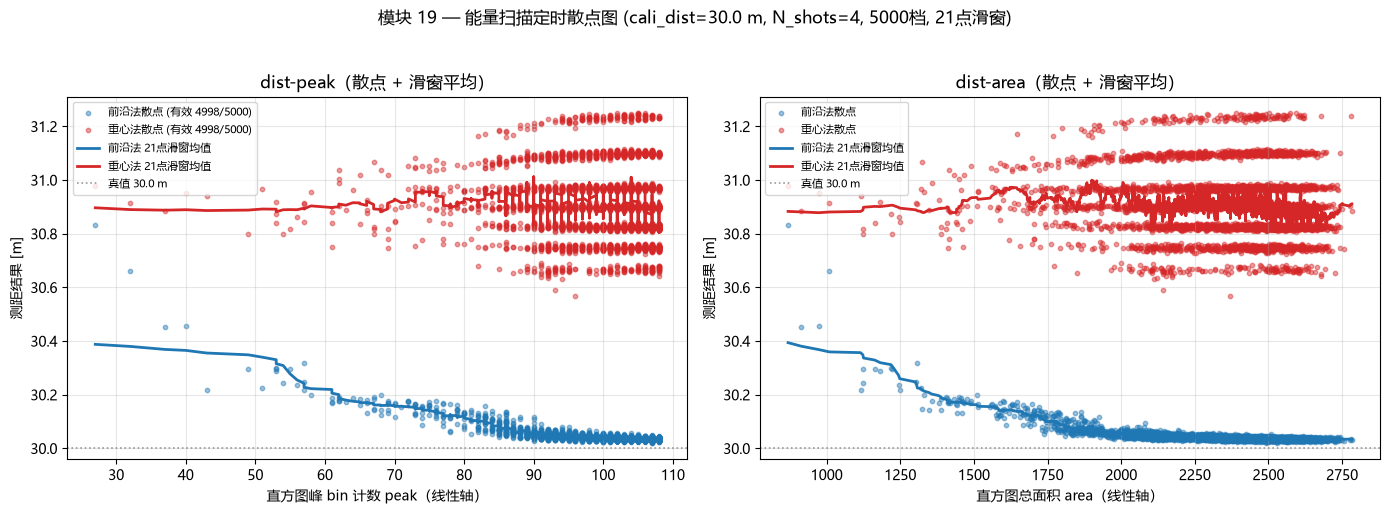

模块 19 汇总：cali_dist=30.0 m, ρ=0.1, boost∈[1e-02,1e+02]（5000档）
  前沿法测距误差范围 [+2.2, +83.2] cm
  重心法测距误差范围 [+56.8, +125.0] cm


In [23]:
# ============================================================================
# 模块 19（v41 新增）— 能量扫描：前沿法/重心法定时 → dist-peak / dist-area 四条曲线
#   复用 v32：spad_binary_trace（逐光子二值引擎）、signal_photon_rate_fine、
#            pixel_collection_matrix、front_time_leading_edge、模块 0b 时间窗。
#   能量注入：反射能量倍数 boost 乘到"单位收集比例信号率"上（ρ≤1 缩不出 1e5，用倍数表征）。
#   横轴用 linear（线性）刻度。
# ============================================================================

# ---- 可调参数 ----
BOOST_MIN = 1e-2          # 反射能量倍数下界（可调）
BOOST_MAX = 1e2           # 反射能量倍数上界（可调）
LIN_STEP  = 0.02          # 线性步长（可调；范围 [0.01,100] 线性 0.02 步长 → 约 5000 档，很慢但点密）
K_TH_19   = 5.0           # 检测阈值倍数 det_th = K_TH_19 · nc_base（沿用 v32 模块14 默认）
COG_HALF  = 6            # 重心法窗口半宽 [bin]
SMOOTH_N  = 21           # 散点滑窗平均窗口点数（可调；奇数为佳，用于在散点上叠加 N 点滑动平均线）

# 线性等分：从 BOOST_MIN 到 BOOST_MAX，步长 LIN_STEP
boost_grid = np.arange(BOOST_MIN, BOOST_MAX + LIN_STEP/2, LIN_STEP)
N_BOOST = len(boost_grid)

def moving_average(y, n=SMOOTH_N):
    """对 1D 数组做 N 点滑动平均（含 nan 安全：用 nanmean 逐窗口）。返回同长度数组。"""
    y = np.asarray(y, dtype=float)
    half = n // 2
    out = np.full(y.size, np.nan)
    for i in range(y.size):
        lo = max(0, i - half); hi = min(y.size, i + half + 1)
        seg = y[lo:hi]
        if np.isfinite(seg).any():
            out[i] = np.nanmean(seg)
    return out

def centroid_time_cog(hist, centers_, pk_idx, half=COG_HALF):
    """重心法(COG)定时：峰 ±half bin 窗口内计数质心。窗口内全 0 返回 nan。"""
    lo = max(0, pk_idx - half); hi = min(len(hist), pk_idx + half + 1)
    w = hist[lo:hi]; x = centers_[lo:hi]
    return (x * w).sum() / w.sum() if w.sum() > 0 else np.nan

def run_peak_hist_boost(boost, p=PARAMS):
    """cali_dist 处峰值宏像元 27 SPAD × N_shots 逐光子二值 MC，信号率 ×boost。返回累加直方图。"""
    rng = np.random.default_rng(p["hist"]["seed"] + 41910)
    h = np.zeros(nbins)
    for _shot in range(N_shots):
        acc = np.zeros(nbins, dtype=np.int32)
        for fij in macro_fvals[m_peak]:
            acc += spad_binary_trace(
                base_rate_gen * fij * boost, r_amb_ph, tf_gen, centers,
                PDE, TAU_RC, VTH_FRAC, jit, rng, T_OVER, T_LASER, RESP_SHAPE, RESP_K)
        h += acc
    return h

det_th_19 = K_TH_19 * nc_base       # nc_base 来自模块13（纯背景全 bin 均值）
print(f"模块19 能量扫描：boost ∈ [{BOOST_MIN:.0e}, {BOOST_MAX:.0e}], 线性步长 {LIN_STEP} → {N_BOOST} 档（逐光子引擎，档多较慢）")
print(f"  检测阈值 det_th = {K_TH_19:.0f}×nc_base = {det_th_19:.3f}（峰 < 此值则不可分辨、留空）")

front_R = np.full(N_BOOST, np.nan)
cog_R   = np.full(N_BOOST, np.nan)
peak_v  = np.zeros(N_BOOST)
area_v  = np.zeros(N_BOOST)

for k, boost in enumerate(boost_grid):
    h = run_peak_hist_boost(boost)
    pk = int(np.argmax(h))
    peak_v[k] = h[pk]; area_v[k] = h.sum()
    detectable = h[pk] >= det_th_19
    if detectable:
        V_dec_k = 0.5 * (det_th_19 + h[pk])
        tf_k, _, _ = front_time_leading_edge(h, centers, pk, V_dec_k, bin_width)
        if np.isfinite(tf_k):
            front_R[k] = C_LIGHT * tf_k / 2.0
        t_cog = centroid_time_cog(h, centers, pk)
        if np.isfinite(t_cog):
            cog_R[k] = C_LIGHT * t_cog / 2.0
    tag = "可分辨" if detectable else "太低-留空"
    if k == 0 or k == N_BOOST-1 or (k+1) % max(1, N_BOOST//20) == 0:   # 节流：约打印 20 行
        print(f"  [{k+1:>4d}/{N_BOOST}] boost={boost:.3f}  峰={h[pk]:>4.0f}  面积={h.sum():>6.0f}  {tag}")

mF = np.isfinite(front_R); mC = np.isfinite(cog_R)
print(f"有效定时：前沿 {mF.sum()}/{N_BOOST}，重心 {mC.sum()}/{N_BOOST}（低能量档按要求留空）")

# ---- 绘图：dist-peak / dist-area 散点图 + N点滑窗平均（横轴 linear）----
#   用户要求：不画折线，画散点；并叠加 N 点滑动平均线（SMOOTH_N 点）观察趋势。
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

ax = axes[0]   # dist-peak：散点 + 滑窗平均
ax.scatter(peak_v[mF], front_R[mF], s=10, color="tab:blue", alpha=0.45,
           label=f"前沿法散点 (有效 {mF.sum()}/{N_BOOST})")
ax.scatter(peak_v[mC], cog_R[mC], s=10, color="tab:red", alpha=0.45,
           label=f"重心法散点 (有效 {mC.sum()}/{N_BOOST})")
# 滑窗平均：按 peak 排序后再平滑（横轴是 peak，需先排序）
if mF.sum() > SMOOTH_N:
    o = np.argsort(peak_v[mF]); px = peak_v[mF][o]; py = front_R[mF][o]
    ax.plot(px, moving_average(py), "-", color="tab:blue", lw=2.0, label=f"前沿法 {SMOOTH_N}点滑窗均值")
if mC.sum() > SMOOTH_N:
    o = np.argsort(peak_v[mC]); px = peak_v[mC][o]; py = cog_R[mC][o]
    ax.plot(px, moving_average(py), "-", color="tab:red", lw=2.0, label=f"重心法 {SMOOTH_N}点滑窗均值")
ax.axhline(D0, color="gray", ls=":", lw=1.2, alpha=0.8, label=f"真值 {D0} m")
ax.set_xlabel("直方图峰 bin 计数 peak（线性轴）")
ax.set_ylabel("测距结果 [m]"); ax.set_title("dist-peak（散点 + 滑窗平均）")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]   # dist-area：散点 + 滑窗平均
ax.scatter(area_v[mF], front_R[mF], s=10, color="tab:blue", alpha=0.45, label="前沿法散点")
ax.scatter(area_v[mC], cog_R[mC], s=10, color="tab:red", alpha=0.45, label="重心法散点")
if mF.sum() > SMOOTH_N:
    o = np.argsort(area_v[mF]); ax_ = area_v[mF][o]; ay = front_R[mF][o]
    ax.plot(ax_, moving_average(ay), "-", color="tab:blue", lw=2.0, label=f"前沿法 {SMOOTH_N}点滑窗均值")
if mC.sum() > SMOOTH_N:
    o = np.argsort(area_v[mC]); ax_ = area_v[mC][o]; ay = cog_R[mC][o]
    ax.plot(ax_, moving_average(ay), "-", color="tab:red", lw=2.0, label=f"重心法 {SMOOTH_N}点滑窗均值")
ax.axhline(D0, color="gray", ls=":", lw=1.2, alpha=0.8, label=f"真值 {D0} m")
ax.set_xlabel("直方图总面积 area（线性轴）")
ax.set_ylabel("测距结果 [m]"); ax.set_title("dist-area（散点 + 滑窗平均）")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f"模块 19 — 能量扫描定时散点图 (cali_dist={D0} m, N_shots={N_shots}, {N_BOOST}档, {SMOOTH_N}点滑窗)",
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("v42_energy_scan.png", dpi=110, bbox_inches="tight")
plt.show()

print("="*76)
print(f"模块 19 汇总：cali_dist={D0} m, ρ={echo0['rho']}, boost∈[{BOOST_MIN:.0e},{BOOST_MAX:.0e}]（{N_BOOST}档）")
if mF.any():
    print(f"  前沿法测距误差范围 [{(front_R[mF].min()-D0)*100:+.1f}, {(front_R[mF].max()-D0)*100:+.1f}] cm")
if mC.any():
    print(f"  重心法测距误差范围 [{(cog_R[mC].min()-D0)*100:+.1f}, {(cog_R[mC].max()-D0)*100:+.1f}] cm")


模块20 SNR vs 距离：D ∈ [1.0, 300.0] m, 50 档 (boost=1.0, 逐光子二值 MC)
  D=   1.0 m: 峰= 108  B= 5.00  SNR= 46.06  信号率峰=5.69e+13
  D=   7.1 m: 峰= 108  B= 5.00  SNR= 46.06  信号率峰=2.83e+12
  D=  13.2 m: 峰=  95  B= 3.00  SNR= 53.12  信号率峰=8.21e+11
  D=  19.3 m: 峰=  85  B= 2.00  SNR= 58.69  信号率峰=3.84e+11
  D=  25.4 m: 峰=  76  B= 2.00  SNR= 52.33  信号率峰=2.21e+11
  D=  31.5 m: 峰=  69  B= 2.00  SNR= 47.38  信号率峰=1.44e+11
  D=  37.6 m: 峰=  67  B= 3.00  SNR= 36.95  信号率峰=1.01e+11
  D=  43.7 m: 峰=  64  B= 2.00  SNR= 43.84  信号率峰=7.45e+10
  D=  49.8 m: 峰=  62  B= 3.00  SNR= 34.06  信号率峰=5.73e+10
  D=  55.9 m: 峰=  54  B= 3.00  SNR= 29.44  信号率峰=4.54e+10
  D=  62.0 m: 峰=  56  B= 2.00  SNR= 38.18  信号率峰=3.69e+10
  D=  68.1 m: 峰=  51  B= 2.00  SNR= 34.65  信号率峰=3.05e+10
  D=  74.2 m: 峰=  43  B= 2.00  SNR= 28.99  信号率峰=2.57e+10
  D=  80.3 m: 峰=  46  B= 3.00  SNR= 24.83  信号率峰=2.19e+10
  D=  86.4 m: 峰=  40  B= 2.00  SNR= 26.87  信号率峰=1.89e+10
  D=  92.5 m: 峰=  41  B= 3.00  SNR= 21.94  信号率峰=1.65e+10
  D=  98.6 m: 峰=  35  B= 2

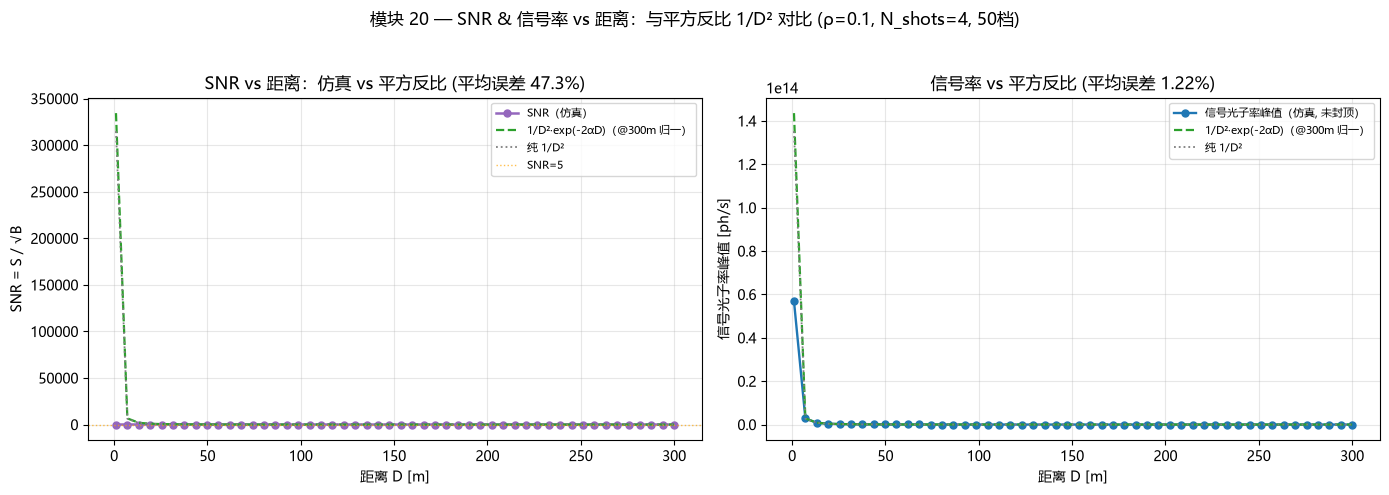

模块 20 汇总：SNR & 信号率 vs 距离，与平方反比 1/D² 对比 (ρ=0.1, N_shots=4, 50档)
  SNR 范围 [0.00, 58.69]；SNR≥5 最大距离 ≈ 232.9 m
  以最远档 D=300m 为锚点，理论 = 1/D²·exp(-2αD)：
  ① 信号率峰值 vs 1/D²：平均|误差|=1.22%，最大=60.40%
     → 未封顶物理量，几乎严格遵循平方反比（误差主要来自蒙卡统计涨落）。
  ② SNR vs 1/D²：平均|误差|=47.3%，最大=100.0%
     → SNR 近似遵循 1/D²，偏差主因：背景 B 随距离非严格恒定、二值饱和使近场 S 被削顶。


In [24]:
# ============================================================================
# 模块 20（v41 新增）— 不同距离下的信噪比 SNR 变化（逐光子二值 MC）
#   沿用 v32 模块13 SNR 定义：SNR = S/√B（S=峰bin总计数−B，B=峰bin纯背景计数）。
#   右图 y 轴用 linear。平方反比验证用【未封顶的信号光子率峰值】比 1/D²·exp(-2αD)——
#   注意：峰 bin 计数因二值 0/1 饱和(近场顶到 108)会偏离 1/D²，不能用来判平方反比，
#   故本模块用未封顶物理量做验证，并把饱和的峰计数画在次轴作对照。
# ============================================================================

# ---- 可调参数 ----
D_MIN_B = 1.0            # 最近距离 [m]
D_MAX_B = 300.0         # 最远距离 [m]
N_D_B   = 50            # 距离档数（加密，可调；逐光子引擎，档多则慢）
BOOST_B = 1.0           # 反射能量倍数（默认 1 = 真实回波）

D_list_B = np.linspace(D_MIN_B, D_MAX_B, N_D_B)
print(f"模块20 SNR vs 距离：D ∈ [{D_MIN_B}, {D_MAX_B}] m, {N_D_B} 档 (boost={BOOST_B}, 逐光子二值 MC)")

def snr_at_distance(D, boost=BOOST_B, p=PARAMS):
    """距离 D 处峰值宏像元二值 MC（信号+背景 与 纯背景各一次），返回 (SNR, 峰计数, B)。
    时间窗/护带随 D 重建（用全局 pre/post/dt_fine），能量注入用 boost 倍数。"""
    t0d = time_of_flight(D)
    t_lo_d, t_hi_d = t0d - pre, t0d + post
    guard = T_OVER + 5 * jit
    tf_gen_d = np.arange(t_lo_d - guard, t_hi_d, dt_fine)
    edges_d = np.arange(t_lo_d, t_hi_d + bin_width/2, bin_width)
    centers_d = 0.5 * (edges_d[:-1] + edges_d[1:])
    nb_d = len(centers_d)
    fpixD, _, _ = pixel_collection_matrix(D, p)
    fvalsD = [fpixD[:, m*By_m:(m+1)*By_m].ravel() for m in range(n_macro)]
    fsumD = np.array([fv.sum() for fv in fvalsD])
    mpk = int(fsumD.argmax())
    echoD = dict(echo0); echoD["D"] = D
    base_gen_D = signal_photon_rate_fine(echoD, 1.0, tf_gen_d, p)
    zero_gen_D = np.zeros_like(base_gen_D)
    rng_s = np.random.default_rng(p["hist"]["seed"] + 42010)
    h_sig = np.zeros(nb_d)
    for _shot in range(N_shots):
        acc = np.zeros(nb_d, dtype=np.int32)
        for fij in fvalsD[mpk]:
            acc += spad_binary_trace(base_gen_D * fij * boost, r_amb_ph, tf_gen_d, centers_d,
                                     PDE, TAU_RC, VTH_FRAC, jit, rng_s, T_OVER, T_LASER, RESP_SHAPE, RESP_K)
        h_sig += acc
    rng_b = np.random.default_rng(p["hist"]["seed"] + 42020)
    h_bg = np.zeros(nb_d)
    for _shot in range(N_shots):
        acc = np.zeros(nb_d, dtype=np.int32)
        for fij in fvalsD[mpk]:
            acc += spad_binary_trace(zero_gen_D, r_amb_ph, tf_gen_d, centers_d,
                                     PDE, TAU_RC, VTH_FRAC, jit, rng_b, T_OVER, T_LASER, RESP_SHAPE, RESP_K)
        h_bg += acc
    pk = int(np.argmax(h_sig))
    B = h_bg[pk]; S = max(h_sig[pk] - B, 0.0)
    snr = S / np.sqrt(B) if B > 0 else (np.inf if S > 0 else 0.0)
    # 未封顶物理量：该峰值宏像元的【信号光子率峰值】(∝ link_factor ∝ 1/D²·exp(-2αD))，
    #   不受二值 0/1 饱和影响，用于干净地验证平方反比律。
    sig_rate_pk = float(base_gen_D.max() * fsumD[mpk])
    return snr, h_sig[pk], B, sig_rate_pk

snr_B  = np.zeros(N_D_B); peak_B = np.zeros(N_D_B); bg_B = np.zeros(N_D_B)
rate_B = np.zeros(N_D_B)      # 未封顶信号光子率峰值（供 1/D² 验证）
for k, D in enumerate(D_list_B):
    snr_B[k], peak_B[k], bg_B[k], rate_B[k] = snr_at_distance(D)
    print(f"  D={D:>6.1f} m: 峰={peak_B[k]:>4.0f}  B={bg_B[k]:>5.2f}  SNR={snr_B[k]:>6.2f}  信号率峰={rate_B[k]:.2e}")

# ---- 平方反比拟合：两条曲线都试 1/D² ----
#   理论：信号光子率 ∝ 接收立体角/D² × 大气透过率² = (1/D²)·exp(-2αD)。
#   ① 信号光子率峰值 rate_B：未封顶物理量，应严格遵循 1/D²。
#   ② SNR：S∝信号率∝1/D²，背景 B≈常数 → SNR=S/√B 也应 ∝1/D²（近似）。
#   两者均以最远档为锚点归一到 1/D²·exp(-2αD)，并给出各档【仿真 vs 平方反比】相对误差。
i_anchor = N_D_B - 1                         # 锚点取最远档（近场偏离最小，作基准最稳）
D_anchor = D_list_B[i_anchor]
alpha = PARAMS["channel"]["alpha"]
atm_ratio = np.exp(-2*alpha*(D_list_B - D_anchor))       # 相对锚点的大气透过率²

# ① 信号率的 1/D² 理论线 + 误差
rate_invsq     = rate_B[i_anchor] * (D_anchor / D_list_B)**2                 # 纯 1/D²
rate_invsq_atm = rate_B[i_anchor] * (D_anchor / D_list_B)**2 * atm_ratio     # 含大气
err_rate = (rate_B - rate_invsq_atm) / np.maximum(rate_invsq_atm, 1e-30) * 100   # 相对误差 [%]

# ② SNR 的 1/D² 理论线 + 误差（用有效档拟合锚点）
finite = np.isfinite(snr_B)
snr_invsq     = snr_B[i_anchor] * (D_anchor / D_list_B)**2                   # 纯 1/D²
snr_invsq_atm = snr_B[i_anchor] * (D_anchor / D_list_B)**2 * atm_ratio       # 含大气
err_snr = np.where(finite, (snr_B - snr_invsq_atm) / np.maximum(snr_invsq_atm, 1e-30) * 100, np.nan)

# ---- 绘图：两张图都做"仿真 vs 1/D²"对比 ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]   # SNR vs 距离 + 1/D² 对比
ax.plot(D_list_B[finite], snr_B[finite], "o-", color="tab:purple", lw=1.8, ms=5, label="SNR（仿真）")
ax.plot(D_list_B, snr_invsq_atm, "--", color="tab:green", lw=1.6,
        label=f"1/D²·exp(-2αD)（@{D_anchor:.0f}m 归一）")
ax.plot(D_list_B, snr_invsq, ":", color="tab:gray", lw=1.3, label="纯 1/D²")
ax.axhline(5.0, color="orange", ls=":", lw=1.0, alpha=0.7, label="SNR=5")
ax.set_xlabel("距离 D [m]"); ax.set_ylabel("SNR = S / √B")
ax.set_title(f"SNR vs 距离：仿真 vs 平方反比 (平均误差 {np.nanmean(np.abs(err_snr)):.1f}%)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

ax = axes[1]   # 信号率峰值 vs 1/D² 对比
ax.plot(D_list_B, rate_B, "o-", color="tab:blue", lw=1.7, ms=5, label="信号光子率峰值（仿真, 未封顶）")
ax.plot(D_list_B, rate_invsq_atm, "--", color="tab:green", lw=1.6,
        label=f"1/D²·exp(-2αD)（@{D_anchor:.0f}m 归一）")
ax.plot(D_list_B, rate_invsq, ":", color="tab:gray", lw=1.3, label="纯 1/D²")
ax.set_xlabel("距离 D [m]"); ax.set_ylabel("信号光子率峰值 [ph/s]")
ax.set_title(f"信号率 vs 平方反比 (平均误差 {np.nanmean(np.abs(err_rate)):.2f}%)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle(f"模块 20 — SNR & 信号率 vs 距离：与平方反比 1/D² 对比 (ρ={echo0['rho']}, N_shots={N_shots}, {N_D_B}档)",
             fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("v42_snr_vs_distance.png", dpi=110, bbox_inches="tight")
plt.show()

print("="*76)
print(f"模块 20 汇总：SNR & 信号率 vs 距离，与平方反比 1/D² 对比 (ρ={echo0['rho']}, N_shots={N_shots}, {N_D_B}档)")
if finite.any():
    print(f"  SNR 范围 [{snr_B[finite].min():.2f}, {snr_B[finite].max():.2f}]；"
          f"SNR≥5 最大距离 ≈ {D_list_B[np.where(snr_B>=5.0)[0][-1]]:.1f} m" if (snr_B>=5.0).any() else "  SNR 全<5")
print(f"  以最远档 D={D_anchor:.0f}m 为锚点，理论 = 1/D²·exp(-2αD)：")
print(f"  ① 信号率峰值 vs 1/D²：平均|误差|={np.nanmean(np.abs(err_rate)):.2f}%，最大={np.nanmax(np.abs(err_rate)):.2f}%")
print(f"     → 未封顶物理量，几乎严格遵循平方反比（误差主要来自蒙卡统计涨落）。")
print(f"  ② SNR vs 1/D²：平均|误差|={np.nanmean(np.abs(err_snr)):.1f}%，最大={np.nanmax(np.abs(err_snr)):.1f}%")
print(f"     → SNR 近似遵循 1/D²，偏差主因：背景 B 随距离非严格恒定、二值饱和使近场 S 被削顶。")
